
# **Notebook Summary**

This notebook examines how LLMs label colors and how their responses compare across languages and against human judgments. It contains three experiments:

### **A. Free-Form Naming on Synthetic Hues**

We generate evenly spaced HSV → RGB swatches (12/36 bins) and ask the LLM to name each color **without restricting the vocabulary** (English or Russian). This tests the model’s spontaneous color terms, boundaries, and variability on clean, fully saturated stimuli.

### **B. Basic-Color Naming on Synthetic Hues**

Using the same synthetic swatches, we restrict the LLM to a **fixed list of basic color categories** in English and Russian. This produces comparable category-level partitions of the hue wheel and highlights cross-linguistic differences (e.g., синий vs. голубой).

### **C. Human–LLM Comparison (Russian Hue-Line Data)**

We load the UW Russian hue-line dataset (72 desaturated chips) and compute human naming distributions for each chip. We then query the LLM on the same RGB stimuli using a free-form Russian prompt and compare human vs. model naming using Jensen–Shannon divergence, both on raw labels and after collapsing to coarse color categories.

Overall, this setup lets us evaluate:

1. how LLMs generate color terms in each language,
2. how their category boundaries shift across languages, and
3. where they diverge from human judgments, especially on low-chroma real-world stimuli.


In [ ]:
# ================================================================
# Setup: install & imports
# ================================================================
# !pip uninstall -y openai
# !pip install --upgrade --force-reinstall "openai>=1.51.0,<2"
# !pip -q install --upgrade numpy pandas matplotlib pillow scipy tqdm pyarrow

import openai
print("openai version:", openai.__version__)

from openai import OpenAI

import os
import math
import re
import io
import base64
import colorsys
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import display


openai version: 2.26.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ================================================================
# API key and client
# ================================================================
# REPLACE THIS WITH YOUR KEY OR USE COLAB SECRETS.

import os
os.environ["OPENAI_API_KEY"] = ""
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

# Multimodal model name (must support image input)
MODEL = "gpt-4o"  # adjust if you want a different model


In [ ]:
"""
Color Naming with LLMs: Synthetic Hues and Human Comparison

This notebook runs three experiments:

A. Free-form naming on synthetic hues.
   - Generate evenly spaced HSV→RGB swatches.
   - Ask the LLM (EN/RU) for a natural color name with no vocabulary constraints.
   - Collect label distributions and entropies per hue.

B. Basic-color naming on synthetic hues.
   - Use the same synthetic swatches.
   - Restrict the LLM to a fixed list of basic color terms (EN/RU).
   - Compare category-level partitions across languages (e.g., blue vs. голубой/синий).

C. Human–LLM comparison on Russian hue-line data.
   - Load the UW Russian hue-line dataset (72 low-chroma chips).
   - Compute human naming distributions per chip.
   - Query the LLM on the same RGB chips with a free-form Russian prompt.
   - Compare human vs. LLM naming via Jensen–Shannon divergence
     (raw labels and after collapsing to coarse color categories).

Notes:
- Human data are currently available only for Russian.
- English human vs. English LLM comparison is planned.
"""



'\nColor Naming with LLMs: Synthetic Hues and Human Comparison\n\nThis notebook runs three experiments:\n\nA. Free-form naming on synthetic hues.\n   - Generate evenly spaced HSV→RGB swatches.\n   - Ask the LLM (EN/RU) for a natural color name with no vocabulary constraints.\n   - Collect label distributions and entropies per hue.\n\nB. Basic-color naming on synthetic hues.\n   - Use the same synthetic swatches.\n   - Restrict the LLM to a fixed list of basic color terms (EN/RU).\n   - Compare category-level partitions across languages (e.g., blue vs. голубой/синий).\n\nC. Human–LLM comparison on Russian hue-line data.\n   - Load the UW Russian hue-line dataset (72 low-chroma chips).\n   - Compute human naming distributions per chip.\n   - Query the LLM on the same RGB chips with a free-form Russian prompt.\n   - Compare human vs. LLM naming via Jensen–Shannon divergence\n     (raw labels and after collapsing to coarse color categories).\n\nNotes:\n- Human data are currently available 

hue index: 0 rgb: (255, 0, 0)


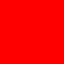

hue index: 6 rgb: (255, 255, 0)


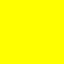

hue index: 12 rgb: (0, 255, 0)


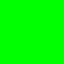

hue index: 18 rgb: (0, 255, 255)


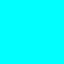

hue index: 24 rgb: (0, 0, 255)


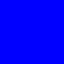

hue index: 30 rgb: (255, 0, 255)


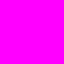

In [ ]:
# ================================================================
# Swatch generation for hue bins
# ================================================================
def hue_to_rgb(h_idx, n_bins=36, s=1.0, v=1.0):
    """
    Convert a hue index (0..n_bins-1) on the HSV wheel to an RGB tuple (0-255).
    """
    h = (h_idx / n_bins)  # in [0,1)
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    return int(r * 255), int(g * 255), int(b * 255)

def make_swatch_rgb(r, g, b, size=96):
    """Create a solid RGB swatch of given size."""
    r, g, b = int(r), int(g), int(b)
    return Image.new("RGB", (size, size), (r, g, b))

# quick sanity check: display a few hues
example_images = []
for idx in [0, 6, 12, 18, 24, 30]:
    rgb = hue_to_rgb(idx, n_bins=36, s=1.0, v=1.0)
    img = make_swatch_rgb(*rgb, size=64)
    example_images.append((idx, rgb, img))

for idx, rgb, img in example_images:
    print("hue index:", idx, "rgb:", rgb)
    display(img)


In [ ]:
# ================================================================
# JS divergence and helpers
# ================================================================
def jensen_shannon(p_dict, q_dict, base=2):
    keys = sorted(set(p_dict.keys()) | set(q_dict.keys()))
    p = np.array([p_dict.get(k, 0.0) for k in keys], dtype=float)
    q = np.array([q_dict.get(k, 0.0) for k in keys], dtype=float)

    p /= p.sum() + 1e-12
    q /= q.sum() + 1e-12
    m = 0.5 * (p + q)

    def kl(a, b):
        mask = (a > 0) & (b > 0)
        if not np.any(mask):
            return 0.0
        a = a[mask]
        b = b[mask]
        return np.sum(a * (np.log(a) - np.log(b))) / math.log(base)

    return 0.5 * kl(p, m) + 0.5 * kl(q, m)

def entropy(p_dict, base=2):
    if not p_dict:
        return np.nan
    p = np.array(list(p_dict.values()), dtype=float)
    p /= p.sum() + 1e-12
    mask = p > 0
    p = p[mask]
    return -np.sum(p * np.log(p)) / math.log(base)

def dict_mode(d):
    if not d:
        return None
    return max(d.items(), key=lambda kv: kv[1])[0]


A. Free-Form Naming on Synthetic Hues

This experiment presents the model with evenly spaced synthetic hues and asks it to produce a natural color name in English or Russian without restricting the vocabulary.
The goal is to observe whatever naming patterns the model generates on its own.
This setup allows us to examine the range of terms the model uses, how consistent those terms are across samples, and whether any language-specific tendencies emerge.
We do not assume in advance how varied or stable these free-form responses will be.

In [ ]:
# ================================================================
# Part A — Free-form naming on synthetic hues (no fixed vocabulary)
# ================================================================

def build_free_prompt(lang_code: str) -> str:
    """
    Free-form prompt: ask for a natural color name (word or short phrase),
    and explicitly discourage basic color labels.
    """
    if lang_code == "en":
        return (
            "You see a solid-colored square.\n"
            "Give a natural, descriptive English color name.\n"
            "Avoid using only basic color words like red, orange, yellow, "
            "green, blue, or purple.\n"
            "Use a more specific or nuanced color term, such as 'scarlet', "
            "'deep red', 'lime green', 'teal', 'aquamarine', 'magenta', "
            "or a similar descriptive phrase.\n"
            "Answer with one word or a very short phrase."
        )
    elif lang_code == "ru":
        return (
            "Вы видите квадрат, залитый одним цветом.\n"
            "Дайте естественное русское название этого цвета.\n"
            "Не ограничивайтесь только базовыми цветами (красный, оранжевый, "
            "жёлтый, зелёный, синий, голубой, фиолетовый).\n"
            "Используйте более точное или оттеночное название, например "
            "'алый', 'бордовый', 'бирюзовый', 'лазурный', 'лиловый' и т.п.\n"
            "Ответьте одним словом или очень короткой фразой."
        )
    else:
        raise ValueError(f"Unsupported language code: {lang_code}")



def normalize_label(text: str, lang: str) -> str:
    """
    Very light normalization for FREE-FORM labels.
    - lowercase
    - strip surrounding whitespace
    - remove most punctuation but keep spaces and hyphens
    - collapse multiple spaces
    - keep the first few tokens (to avoid long sentences)

    IMPORTANT: no mapping to a fixed basic-color list here.
    """
    s = str(text).strip().lower()
    if not s:
        return ""

    # remove punctuation-like characters but keep spaces, hyphens, and 'ё'
    s = re.sub(r"[^\w\s\-ё]", " ", s, flags=re.UNICODE)
    s = re.sub(r"\s+", " ", s).strip()
    if not s:
        return ""

    # keep the first few tokens to avoid full-sentence replies
    tokens = s.split()
    max_tokens = 3  # tweak if needed
    s_short = " ".join(tokens[:max_tokens])

    return s_short


def query_llm_for_hue(h_idx,
                      n_bins=36,
                      lang_code="en",
                      n_samples=10,
                      temperature=0.7,
                      s=1.0,
                      v=1.0):
    """
    Query the multimodal model for one synthetic hue bin with a FREE-FORM
    color-naming prompt (no restricted vocabulary).

    Returns:
      - Counter over normalized labels
      - the RGB used for this hue
    """
    # 1) Hue -> RGB swatch
    r, g, b = hue_to_rgb(h_idx, n_bins=n_bins, s=s, v=v)
    img = make_swatch_rgb(r, g, b)

    # 2) Encode as base64 PNG
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode("utf-8")
    img_url = f"data:image/png;base64,{img_b64}"

    # 3) Prompt + calls
    prompt = build_free_prompt(lang_code)
    labels = []

    for _ in range(n_samples):
        resp = client.responses.create(
            model=MODEL,
            input=[
                {
                    "role": "user",
                    "content": [
                        {"type": "input_image", "image_url": img_url},
                        {"type": "input_text", "text": prompt},
                    ],
                }
            ],
            max_output_tokens=32,
            temperature=temperature,
            top_p=0.95,
        )

        out = resp.output[0].content
        text_blocks = [c for c in out if getattr(c, "type", None) == "output_text"]
        if text_blocks:
            raw = text_blocks[0].text
        else:
            raw = out[0].text if out else ""
        labels.append(normalize_label(raw, lang_code))

    return Counter(labels), (r, g, b)


def run_hue_experiment_for_language(lang_code="en",
                                    n_bins=36,
                                    n_samples_per_hue=30,
                                    temperature=0.7,
                                    s=1.0,
                                    v=1.0):
    """
    FREE-FORM hue experiment for one language.

    For each hue bin, we collect a distribution over whatever labels
    the model chooses to produce (words or short phrases).
    """
    records = []
    for h_idx in tqdm(range(n_bins), desc=f"Hue experiment (free-form, {lang_code})"):
        counts, rgb = query_llm_for_hue(
            h_idx,
            n_bins=n_bins,
            lang_code=lang_code,
            n_samples=n_samples_per_hue,
            temperature=temperature,
            s=s,
            v=v,
        )
        total = sum(counts.values())
        probs = {k: v / total for k, v in counts.items()} if total > 0 else {}

        records.append({
            "lang": lang_code,
            "hue_idx": h_idx,
            "rgb": rgb,
            "label_counts": dict(counts),
            "label_probs": probs,
            "top_label": dict_mode(probs),
            "entropy": entropy(probs),
        })

    return pd.DataFrame(records)


 # ================================================================
# Small test A run (few hues, low samples)
# ================================================================


In [ ]:
# ================================================================
# Small test run (few hues, low samples)
# ================================================================
df_en_test = run_hue_experiment_for_language(
    lang_code="en",
    n_bins=12,
    n_samples_per_hue=25,
    temperature=0.9,
    s=1.0,
    v=1.0,
)
print(df_en_test[["hue_idx", "top_label", "entropy"]])



Hue experiment (free-form, en): 100%|██████████| 12/12 [06:11<00:00, 31.00s/it]

    hue_idx     top_label       entropy
0         0       scarlet  9.709506e-01
1         1     tangerine  1.442823e-12
2         2   neon yellow  1.209800e+00
3         3    lime green  4.021792e-01
4         4    neon green  7.950403e-01
5         5    neon green  1.442823e-12
6         6          cyan  4.021792e-01
7         7         azure  1.097125e+00
8         8   cobalt blue  1.163990e+00
9         9  vivid violet  1.371315e+00
10       10       magenta  4.021792e-01
11       11      hot pink  1.553521e+00


In [ ]:
# Test one hue: index 0 out of 12 (should be a strong red)
h_idx = 0
counts, rgb = query_llm_for_hue(
    h_idx,
    n_bins=12,
    lang_code="en",
    n_samples=25,
    temperature=0.9,
    s=1.0,
    v=1.0,
)
print("RGB:", rgb)
print("Label counts:", counts)
print("Labels:", list(counts.keys()))



RGB: (255, 0, 0)
Label counts: Counter({'scarlet': 19, 'crimson': 6})
Labels: ['scarlet', 'crimson']


In [ ]:
df_ru_test = run_hue_experiment_for_language(
    lang_code="ru",
    n_bins=12,
    n_samples_per_hue=25,
    temperature=0.9,
    s=1.0,
    v=1.0,
)
print(df_ru_test[["hue_idx", "top_label", "entropy"]])


Hue experiment (free-form, ru): 100%|██████████| 12/12 [07:16<00:00, 36.40s/it]

    hue_idx     top_label       entropy
0         0          алый  4.821792e-01
1         1     оранжевый  1.498455e+00
2         2      лимонный  5.293609e-01
3         3      лаймовый  1.202292e+00
4         4  ярко-зелёный  1.697321e+00
5         5     салатовый  1.095431e+00
6         6     бирюзовый  1.442823e-12
7         7      лазурный  1.565141e+00
8         8   кобальтовый  2.483216e+00
9         9    фиолетовый  4.021792e-01
10       10        фуксия  2.422922e-01
11       11        фуксия  1.442823e-12



## Full free-form run (Experiment A) (36 hues) (TODO)


In [ ]:
# ================================================================
# Full free-form run (36 hues)
# ================================================================

# English: 36-bin free-form naming
df_en_free_36 = run_hue_experiment_for_language(
    lang_code="en",
    n_bins=36,
    n_samples_per_hue=25,  # bump if you can afford it
    temperature=0.9,
    s=1.0,
    v=1.0,
)
print("EN free-form (36 hues):")
print(df_en_free_36[["hue_idx", "top_label", "entropy"]].head())

# Russian: 36-bin free-form naming
df_ru_free_36 = run_hue_experiment_for_language(
    lang_code="ru",
    n_bins=36,
    n_samples_per_hue=25,
    temperature=0.9,
    s=1.0,
    v=1.0,
)
print("\nRU free-form (36 hues):")
print(df_ru_free_36[["hue_idx", "top_label", "entropy"]].head())


Hue experiment (free-form, en): 100%|██████████| 36/36 [21:24<00:00, 35.69s/it]


EN free-form (36 hues):
   hue_idx  top_label       entropy
0        0    scarlet  9.043815e-01
1        1  vermilion  6.395564e-01
2        2  tangerine  1.442823e-12
3        3  tangerine  1.442823e-12
4        4      amber  6.395564e-01


Hue experiment (free-form, ru): 100%|██████████| 36/36 [22:13<00:00, 37.03s/it]


RU free-form (36 hues):
   hue_idx     top_label   entropy
0        0          алый  0.242292
1        1          алый  1.429275
2        2  мандариновый  1.259722
3        3  мандариновый  1.710338
4        4          охра  0.482179


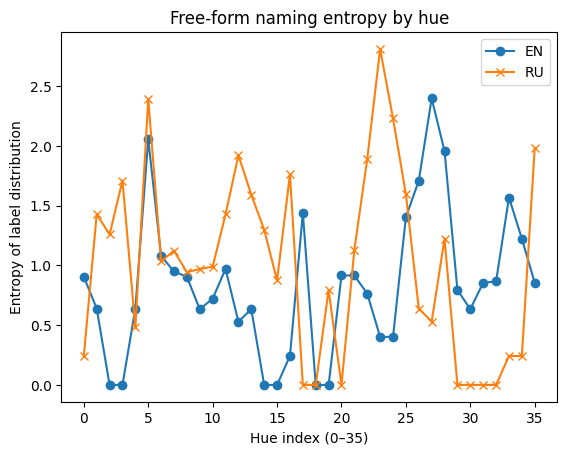

In [ ]:
plt.figure()
plt.plot(df_en_free_36["hue_idx"], df_en_free_36["entropy"], marker="o", label="EN")
plt.plot(df_ru_free_36["hue_idx"], df_ru_free_36["entropy"], marker="x", label="RU")
plt.xlabel("Hue index (0–35)")
plt.ylabel("Entropy of label distribution")
plt.title("Free-form naming entropy by hue")
plt.legend()
plt.show()


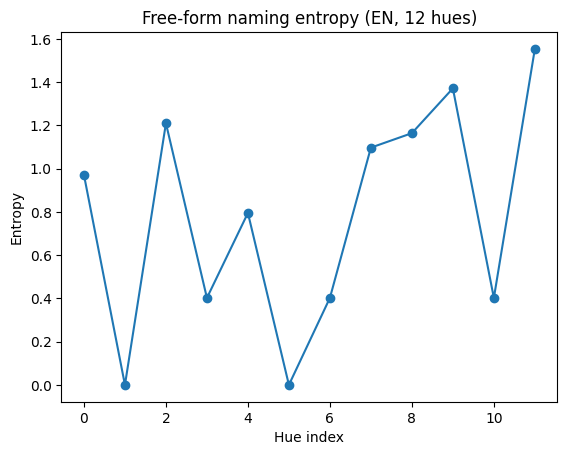

In [ ]:
plt.figure()
plt.plot(df_en_test["hue_idx"], df_en_test["entropy"], marker="o")
plt.xlabel("Hue index")
plt.ylabel("Entropy")
plt.title("Free-form naming entropy (EN, 12 hues)")
plt.show()


In [ ]:
df_en_test["vocab_size"] = df_en_test["label_counts"].apply(lambda d: len(d))
df_en_test[["hue_idx", "vocab_size", "top_label"]]


,hue_idx,vocab_size,top_label
0,0,2,scarlet
1,1,1,tangerine
2,2,3,neon yellow
3,3,2,lime green
4,4,2,neon green
5,5,1,neon green
6,6,2,cyan
7,7,3,azure
8,8,3,cobalt blue
9,9,5,vivid violet


In [ ]:
for h in [0, 2, 4, 6, 9]:   # red, yellow, green, cyan, purple
    row = df_en_test[df_en_test.hue_idx == h].iloc[0]
    print(f"\nHue {h} (RGB={row['rgb']}):")
    print(row["label_probs"])



Hue 0 (RGB=(255, 0, 0)):
{'crimson': 0.4, 'scarlet': 0.6}

Hue 2 (RGB=(255, 255, 0)):
{'neon yellow': 0.68, 'lemon yellow': 0.2, 'canary yellow': 0.12}

Hue 4 (RGB=(0, 255, 0)):
{'neon green': 0.76, 'lime green': 0.24}

Hue 6 (RGB=(0, 255, 255)):
{'cyan': 0.92, 'aqua': 0.08}

Hue 9 (RGB=(127, 0, 255)):
{'electric purple': 0.08, 'vivid violet': 0.72, 'violet': 0.12, 'vivid purple': 0.04, 'vibrant violet': 0.04}


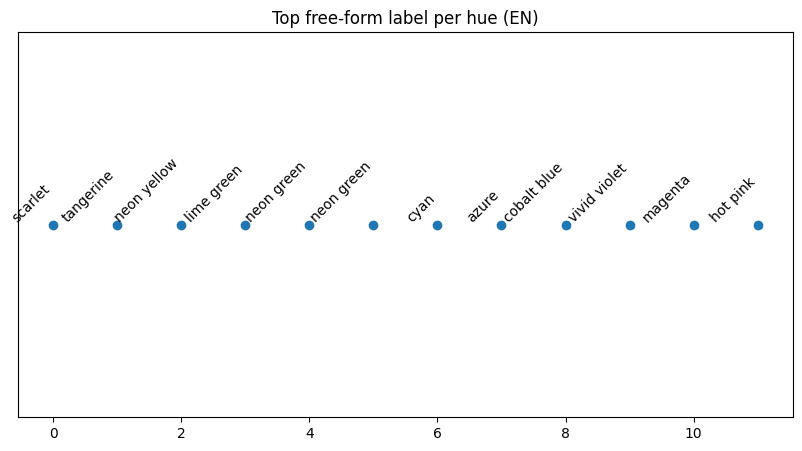

In [ ]:
labels = df_en_test.sort_values("hue_idx")["top_label"].tolist()

plt.figure(figsize=(10,5))
plt.scatter(range(len(labels)), [1]*len(labels))
for i, lab in enumerate(labels):
    plt.text(i, 1, lab, rotation=45, ha='right', va='bottom')
plt.title("Top free-form label per hue (EN)")
plt.yticks([])
plt.show()


In [ ]:
vocab_en = set().union(*df_en_test["label_counts"].apply(lambda d: d.keys()))
vocab_ru = set().union(*df_ru_test["label_counts"].apply(lambda d: d.keys()))

print("EN vocab size:", len(vocab_en))
print("RU vocab size:", len(vocab_ru))


EN vocab size: 23
RU vocab size: 26


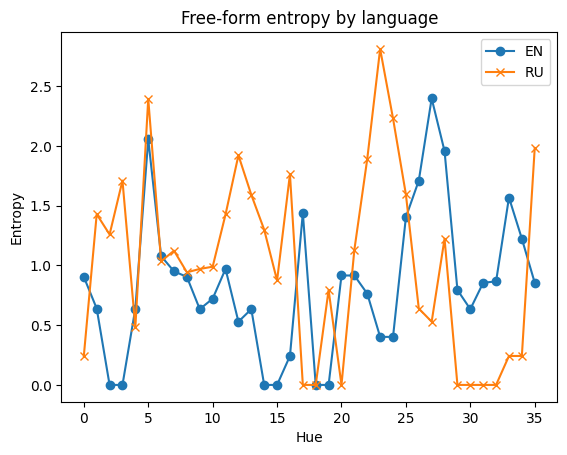

In [ ]:
plt.plot(df_en_free_36["hue_idx"], df_en_free_36["entropy"], label="EN", marker='o')
plt.plot(df_ru_free_36["hue_idx"], df_ru_free_36["entropy"], label="RU", marker='x')
plt.xlabel("Hue")
plt.ylabel("Entropy")
plt.legend()
plt.title("Free-form entropy by language")
plt.show()


Preliminary observations for Part A (Free-Form Naming)

The free-form English and Russian runs both produce a diverse set of color terms (EN ≈ 23 types, RU ≈ 26 types).
Across the 36 synthetic hues, both languages show a mix of low-entropy regions (where the model consistently uses one label) and higher-entropy regions (where multiple labels compete).
The entropy profiles differ across languages, indicating that English and Russian assign lexical boundaries to the hue wheel in different ways.
These differences are visible in the specific top labels for each hue: English often uses terms such as scarlet, tangerine, neon yellow, lime green, cyan, azure, cobalt blue, vivid violet, magenta, and hot pink, while Russian produces analogues such as алый, мандариновый, охра, and other fine-grained color terms.
These results suggest that the model’s free-form naming behavior reflects language-specific lexical structure, but we do not yet interpret this in relation to human naming without the human–model comparison in Part C.

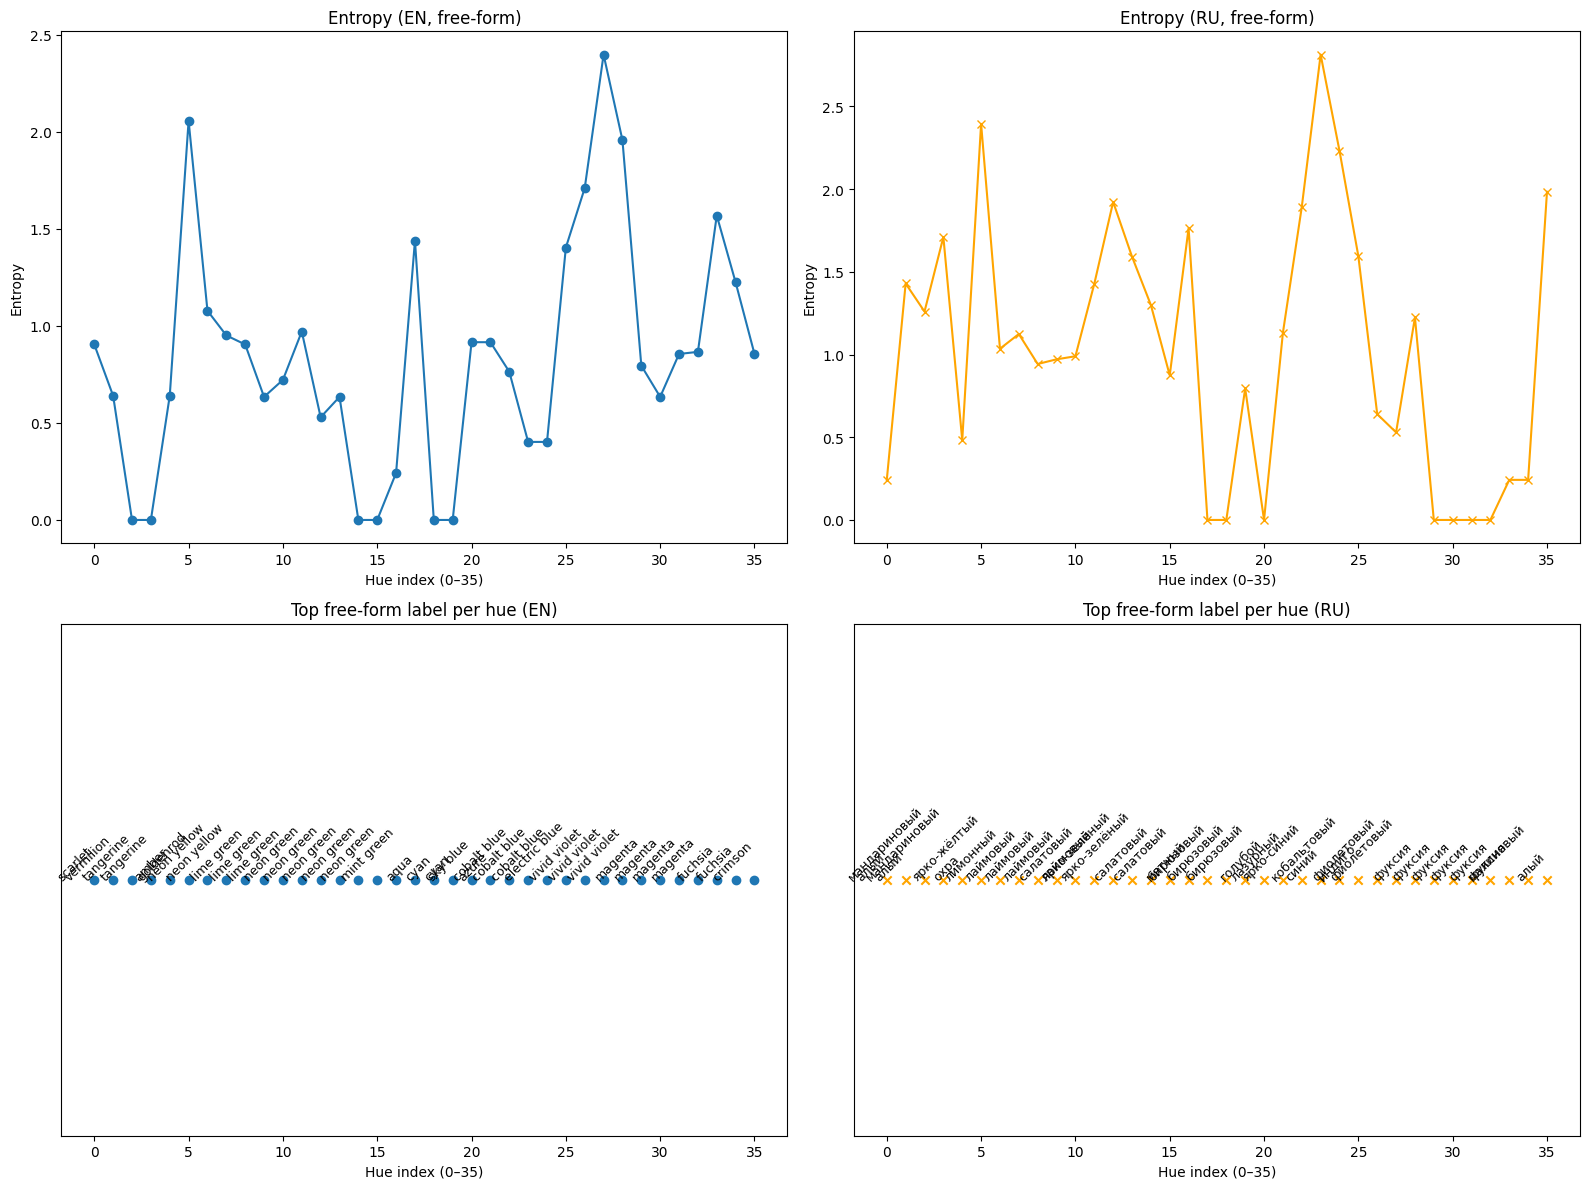

In [ ]:
# ================================================================
# 2×2 Summary Figure for Part A (Free-form EN + RU)
# ================================================================
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# --------------------------
# (1) EN entropy curve
# --------------------------
axs[0, 0].plot(
    df_en_free_36["hue_idx"],
    df_en_free_36["entropy"],
    marker="o"
)
axs[0, 0].set_title("Entropy (EN, free-form)")
axs[0, 0].set_xlabel("Hue index (0–35)")
axs[0, 0].set_ylabel("Entropy")

# --------------------------
# (2) RU entropy curve
# --------------------------
axs[0, 1].plot(
    df_ru_free_36["hue_idx"],
    df_ru_free_36["entropy"],
    marker="x",
    color="orange"
)
axs[0, 1].set_title("Entropy (RU, free-form)")
axs[0, 1].set_xlabel("Hue index (0–35)")
axs[0, 1].set_ylabel("Entropy")

# --------------------------
# (3) EN top label wheel
# --------------------------
axs[1, 0].scatter(
    df_en_free_36["hue_idx"],
    [1]*36,
    marker="o"
)
for i, row in df_en_free_36.iterrows():
    axs[1, 0].annotate(
        row["top_label"],
        (row["hue_idx"], 1),
        rotation=45,
        ha="right",
        fontsize=9
    )
axs[1, 0].set_yticks([])
axs[1, 0].set_title("Top free-form label per hue (EN)")
axs[1, 0].set_xlabel("Hue index (0–35)")

# --------------------------
# (4) RU top label wheel
# --------------------------
axs[1, 1].scatter(
    df_ru_free_36["hue_idx"],
    [1]*36,
    marker="x",
    color="orange"
)
for i, row in df_ru_free_36.iterrows():
    axs[1, 1].annotate(
        row["top_label"],
        (row["hue_idx"], 1),
        rotation=45,
        ha="right",
        fontsize=9
    )
axs[1, 1].set_yticks([])
axs[1, 1].set_title("Top free-form label per hue (RU)")
axs[1, 1].set_xlabel("Hue index (0–35)")

plt.tight_layout()
plt.show()


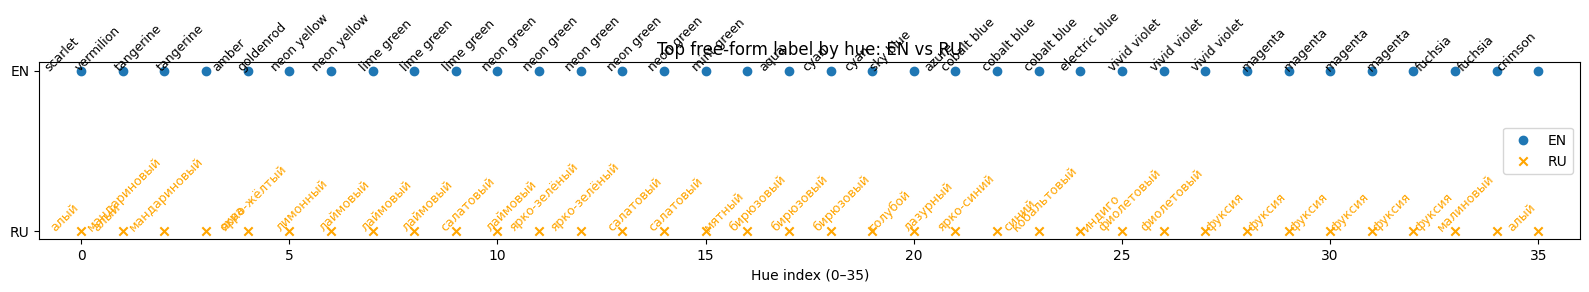

In [ ]:
# ================================================================
# EN vs RU top-label wheel (side-by-side)
# ================================================================
plt.figure(figsize=(16, 3))

plt.scatter(df_en_free_36["hue_idx"], [2]*36, marker="o", label="EN")
plt.scatter(df_ru_free_36["hue_idx"], [1]*36, marker="x", color="orange", label="RU")

# annotate EN
for _, row in df_en_free_36.iterrows():
    plt.annotate(row["top_label"], (row["hue_idx"], 2),
                 rotation=45, ha="right", fontsize=9)

# annotate RU
for _, row in df_ru_free_36.iterrows():
    plt.annotate(row["top_label"], (row["hue_idx"], 1),
                 rotation=45, ha="right", fontsize=9, color="orange")

plt.yticks([1, 2], ["RU", "EN"])
plt.title("Top free-form label by hue: EN vs RU")
plt.xlabel("Hue index (0–35)")
plt.xlim(-1, 36)
plt.legend()
plt.tight_layout()
plt.show()


B. Basic-Color Naming on Synthetic Hues

This experiment uses the same synthetic hue stimuli but restricts the model to a fixed set of basic color categories in each language.
The purpose is to see how the model assigns hues to standardized labels and to enable direct comparisons across languages using aligned vocabularies.
This helps examine potential differences in boundary placement, but we do not assume beforehand how close or far these assignments will be across languages.



Relationship Between A and B

The two experiments serve complementary purposes:

A explores unconstrained naming behavior, capturing whatever distinctions or variations the model naturally produces.

B examines how the model behaves when its output space is limited to predefined categories.

Together, they provide two different views of how the model maps colors to linguistic labels, but the specific outcomes of either experiment are not assumed in advance.

## Part B - Hue-only LLM Experment (synthetic stimuli)

In [ ]:
import colorsys  # only needed for Part B

# Basic color vocabularies
BASIC_EN = [
    "red", "orange", "yellow", "green", "blue",
    "purple", "pink", "brown", "gray", "black", "white"
]

BASIC_RU = [
    "красный", "оранжевый", "жёлтый", "зелёный",
    "синий", "голубой", "фиолетовый", "розовый",
    "коричневый", "серый", "чёрный", "белый"
]

def hue_to_rgb_basic(h_idx, n_bins=36, s=1.0, v=1.0):
    """Evenly spaced hue on HSV wheel → RGB 0–255."""
    h = h_idx / n_bins
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    return int(r * 255), int(g * 255), int(b * 255)


In [ ]:
def build_basic_prompt(lang: str) -> str:
    if lang == "en":
        allowed = ", ".join(BASIC_EN)
        return (
            "You see a solid-colored square.\n"
            "Name its BASIC color category in English.\n"
            "Use exactly ONE word from this list:\n"
            f"{allowed}\n"
            "Answer with just that single word."
        )
    elif lang == "ru":
        allowed = ", ".join(BASIC_RU)
        return (
            "Вы видите одноцветный квадрат.\n"
            "Назовите ЕГО ОСНОВНУЮ КАТЕГОРИЮ ЦВЕТА по-русски.\n"
            "Используйте ровно ОДНО слово из этого списка:\n"
            f"{allowed}\n"
            "Ответьте только одним словом."
        )
    else:
        raise ValueError(f"Unsupported language code: {lang}")


def normalize_basic_label(text: str, lang: str) -> str:
    """
    Normalize model output so it maps onto the BASIC list if possible.
    """
    s = str(text).strip().lower()
    s = re.sub(r"[^\w\sё]", " ", s, flags=re.UNICODE)
    s = re.sub(r"\s+", " ", s).strip()
    if not s:
        return ""

    token = s.split()[0]

    if lang == "en":
        if token in BASIC_EN:
            return token
        if token == "grey":
            return "gray"
        return token

    if lang == "ru":
        if token in BASIC_RU:
            return token
        token_norm = token.replace("ё", "е")
        for w in BASIC_RU:
            if w.replace("ё", "е") == token_norm:
                return w
        return token

    return token


In [ ]:
def query_llm_for_hue_basic(h_idx,
                            n_bins=36,
                            lang_code="en",
                            n_samples=20,
                            temperature=0.1,
                            s=1.0,
                            v=1.0):
    """
    One synthetic hue bin → LLM basic-color distribution.
    """
    r, g, b = hue_to_rgb_basic(h_idx, n_bins=n_bins, s=s, v=v)
    img = make_swatch_rgb(r, g, b)  # from Part A
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode("utf-8")
    img_url = f"data:image/png;base64,{img_b64}"

    prompt = build_basic_prompt(lang_code)
    labels = []

    for _ in range(n_samples):
        resp = client.responses.create(
            model=MODEL,
            input=[{
                "role": "user",
                "content": [
                    {"type": "input_image", "image_url": img_url},
                    {"type": "input_text", "text": prompt},
                ],
            }],
            max_output_tokens=32,
            temperature=temperature,
        )

        out = resp.output[0].content
        text_blocks = [c for c in out if getattr(c, "type", None) == "output_text"]
        raw = text_blocks[0].text if text_blocks else (out[0].text if out else "")
        labels.append(normalize_basic_label(raw, lang_code))

    return Counter(labels), (r, g, b)


In [ ]:
def run_hue_experiment_basic(lang_code="en",
                             n_bins=36,
                             n_samples_per_hue=20,
                             temperature=0.1,
                             s=1.0,
                             v=1.0):
    records = []
    for h_idx in tqdm(range(n_bins), desc=f"Hue experiment (basic, {lang_code})"):
        counts, rgb = query_llm_for_hue_basic(
            h_idx,
            n_bins=n_bins,
            lang_code=lang_code,
            n_samples=n_samples_per_hue,
            temperature=temperature,
            s=s,
            v=v,
        )
        total = sum(counts.values())
        probs = {k: v / total for k, v in counts.items()} if total > 0 else {}

        records.append({
            "lang": lang_code,
            "hue_idx": h_idx,
            "rgb": rgb,
            "label_counts": dict(counts),
            "label_probs": probs,
            "top_label": dict_mode(probs),
            "entropy": entropy(probs),
        })

    return pd.DataFrame(records)


In [ ]:
df_en_hue_12 = run_hue_experiment_basic(
    lang_code="en",
    n_bins=12,
    n_samples_per_hue=20,
    temperature=0.1,
)
df_en_hue_12


Hue experiment (basic, en): 100%|██████████| 12/12 [06:33<00:00, 32.79s/it]


,lang,hue_idx,rgb,label_counts,label_probs,top_label,entropy
0,en,0,"(255, 0, 0)",{'red': 20},{'red': 1.0},red,1.442823e-12
1,en,1,"(255, 127, 0)",{'orange': 20},{'orange': 1.0},orange,1.442823e-12
2,en,2,"(255, 255, 0)",{'yellow': 20},{'yellow': 1.0},yellow,1.442823e-12
3,en,3,"(127, 255, 0)",{'green': 20},{'green': 1.0},green,1.442823e-12
4,en,4,"(0, 255, 0)",{'green': 20},{'green': 1.0},green,1.442823e-12
5,en,5,"(0, 255, 127)",{'green': 20},{'green': 1.0},green,1.442823e-12
6,en,6,"(0, 255, 255)",{'blue': 20},{'blue': 1.0},blue,1.442823e-12
7,en,7,"(0, 127, 255)",{'blue': 20},{'blue': 1.0},blue,1.442823e-12
8,en,8,"(0, 0, 255)",{'blue': 20},{'blue': 1.0},blue,1.442823e-12
9,en,9,"(127, 0, 255)",{'purple': 20},{'purple': 1.0},purple,1.442823e-12


In [ ]:
df_ru_hue_12 = run_hue_experiment_basic(
    lang_code="ru",
    n_bins=12,
    n_samples_per_hue=20,
    temperature=0.1,
)
df_ru_hue_12


Hue experiment (basic, ru): 100%|██████████| 12/12 [05:41<00:00, 28.42s/it]


,lang,hue_idx,rgb,label_counts,label_probs,top_label,entropy
0,ru,0,"(255, 0, 0)",{'красный': 20},{'красный': 1.0},красный,1.442823e-12
1,ru,1,"(255, 127, 0)",{'оранжевый': 20},{'оранжевый': 1.0},оранжевый,1.442823e-12
2,ru,2,"(255, 255, 0)",{'жёлтый': 20},{'жёлтый': 1.0},жёлтый,1.442823e-12
3,ru,3,"(127, 255, 0)",{'зелёный': 20},{'зелёный': 1.0},зелёный,1.442823e-12
4,ru,4,"(0, 255, 0)",{'зелёный': 20},{'зелёный': 1.0},зелёный,1.442823e-12
5,ru,5,"(0, 255, 127)",{'зелёный': 20},{'зелёный': 1.0},зелёный,1.442823e-12
6,ru,6,"(0, 255, 255)",{'голубой': 20},{'голубой': 1.0},голубой,1.442823e-12
7,ru,7,"(0, 127, 255)","{'голубой': 4, 'синий': 16}","{'голубой': 0.2, 'синий': 0.8}",синий,7.219281e-01
8,ru,8,"(0, 0, 255)",{'синий': 20},{'синий': 1.0},синий,1.442823e-12
9,ru,9,"(127, 0, 255)",{'фиолетовый': 20},{'фиолетовый': 1.0},фиолетовый,1.442823e-12


In [ ]:
df_en_hue_36 = run_hue_experiment_basic(
    lang_code="en",
    n_bins=36,
    n_samples_per_hue=20,   # or 30 if you can afford it
    temperature=0.1,
)
df_ru_hue_36 = run_hue_experiment_basic(
    lang_code="ru",
    n_bins=36,
    n_samples_per_hue=20,
    temperature=0.1,
)


Hue experiment (basic, ru): 100%|██████████| 36/36 [19:22<00:00, 32.30s/it]


In [ ]:
# ================================================================
# Part B – Evaluation helpers (per-language)
# ================================================================

def summarize_basic_df(df_basic: pd.DataFrame, lang_label: str):
    """
    Summarize basic-color naming for one language:
    - compute vocab size per hue
    - print overall vocabulary
    - show per-hue table
    """
    df = df_basic.sort_values("hue_idx").reset_index(drop=True).copy()
    df["vocab_size"] = df["label_counts"].apply(lambda d: len(d))

    # overall vocabulary
    vocab = set()
    for d in df["label_counts"]:
        vocab.update(d.keys())
    print(f"\n=== {lang_label} basic-color summary ===")
    print(f"Number of hues: {len(df)}")
    print(f"Distinct labels used: {len(vocab)}")
    print("Labels:", sorted(vocab))

    display(df[["hue_idx", "rgb", "top_label", "entropy", "vocab_size"]])

    return df


In [ ]:
df_en_basic = summarize_basic_df(df_en_hue_36, "English")
df_ru_basic = summarize_basic_df(df_ru_hue_36, "Russian")



=== English basic-color summary ===
Number of hues: 36
Distinct labels used: 7
Labels: ['blue', 'green', 'orange', 'pink', 'purple', 'red', 'yellow']


,hue_idx,rgb,top_label,entropy,vocab_size
0,0,"(255, 0, 0)",red,1.442823e-12,1
1,1,"(255, 42, 0)",red,1.442823e-12,1
2,2,"(255, 84, 0)",orange,1.442823e-12,1
3,3,"(255, 127, 0)",orange,1.442823e-12,1
4,4,"(255, 170, 0)",orange,1.442823e-12,1
5,5,"(255, 212, 0)",yellow,1.442823e-12,1
6,6,"(255, 255, 0)",yellow,1.442823e-12,1
7,7,"(212, 255, 0)",yellow,1.442823e-12,1
8,8,"(170, 255, 0)",green,1.442823e-12,1
9,9,"(127, 255, 0)",green,1.442823e-12,1



=== Russian basic-color summary ===
Number of hues: 36
Distinct labels used: 8
Labels: ['голубой', 'жёлтый', 'зелёный', 'красный', 'оранжевый', 'розовый', 'синий', 'фиолетовый']


,hue_idx,rgb,top_label,entropy,vocab_size
0,0,"(255, 0, 0)",красный,1.442823e-12,1
1,1,"(255, 42, 0)",красный,1.442823e-12,1
2,2,"(255, 84, 0)",оранжевый,1.442823e-12,1
3,3,"(255, 127, 0)",оранжевый,1.442823e-12,1
4,4,"(255, 170, 0)",оранжевый,2.863970e-01,2
5,5,"(255, 212, 0)",жёлтый,1.442823e-12,1
6,6,"(255, 255, 0)",жёлтый,1.442823e-12,1
7,7,"(212, 255, 0)",жёлтый,1.442823e-12,1
8,8,"(170, 255, 0)",зелёный,1.442823e-12,1
9,9,"(127, 255, 0)",зелёный,1.442823e-12,1


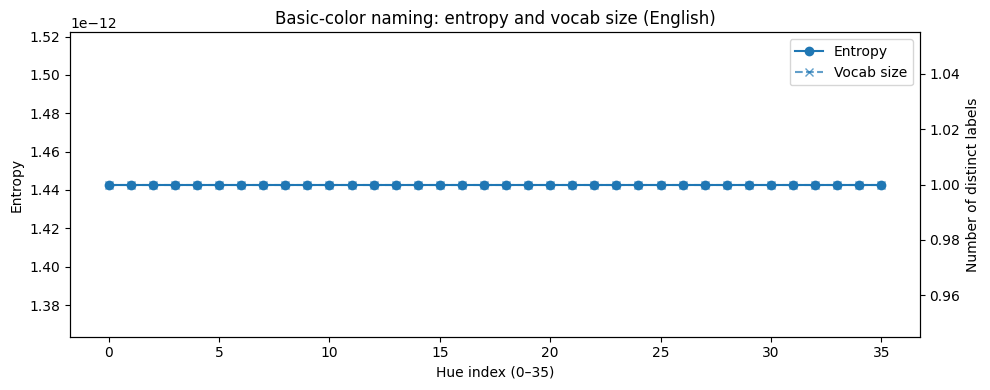

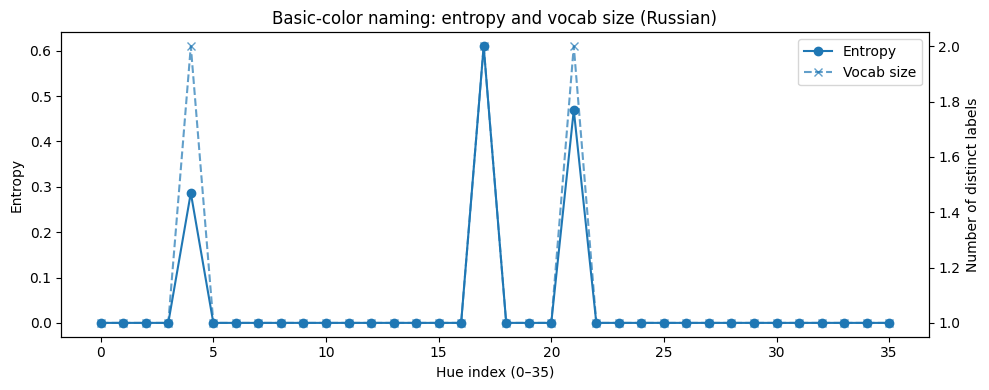

In [ ]:
# ================================================================
# Entropy and vocab size by hue
# ================================================================

def plot_entropy_and_vocab(df_basic: pd.DataFrame, lang_label: str):
    df = df_basic.sort_values("hue_idx")

    fig, ax1 = plt.subplots(figsize=(10,4))

    ax1.plot(df["hue_idx"], df["entropy"], marker="o", label="Entropy")
    ax1.set_xlabel("Hue index (0–35)")
    ax1.set_ylabel("Entropy")
    ax1.set_title(f"Basic-color naming: entropy and vocab size ({lang_label})")

    ax2 = ax1.twinx()
    ax2.plot(df["hue_idx"], df["vocab_size"], marker="x", linestyle="--",
             label="Vocab size", alpha=0.7)
    ax2.set_ylabel("Number of distinct labels")

    # combined legend
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper right")

    plt.tight_layout()
    plt.show()

plot_entropy_and_vocab(df_en_basic, "English")
plot_entropy_and_vocab(df_ru_basic, "Russian")


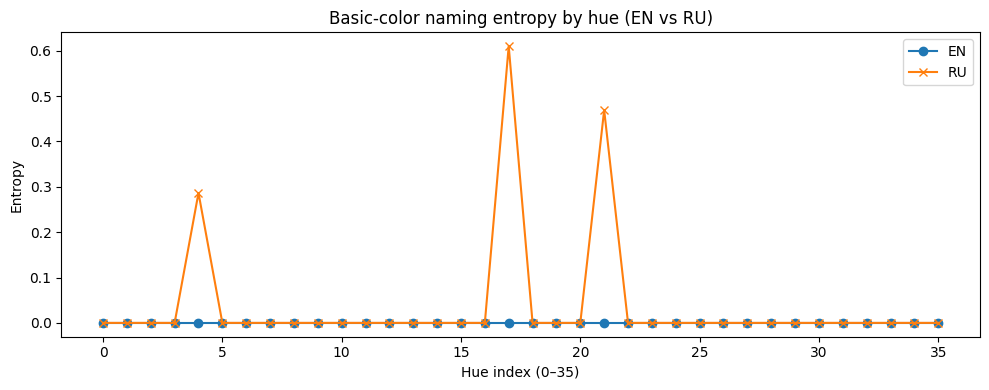

In [ ]:
# Overlay entropy EN vs RU (same 36 hues)
plt.figure(figsize=(10,4))
plt.plot(df_en_basic["hue_idx"], df_en_basic["entropy"], marker="o", label="EN")
plt.plot(df_ru_basic["hue_idx"], df_ru_basic["entropy"], marker="x", label="RU")
plt.xlabel("Hue index (0–35)")
plt.ylabel("Entropy")
plt.title("Basic-color naming entropy by hue (EN vs RU)")
plt.legend()
plt.tight_layout()
plt.show()


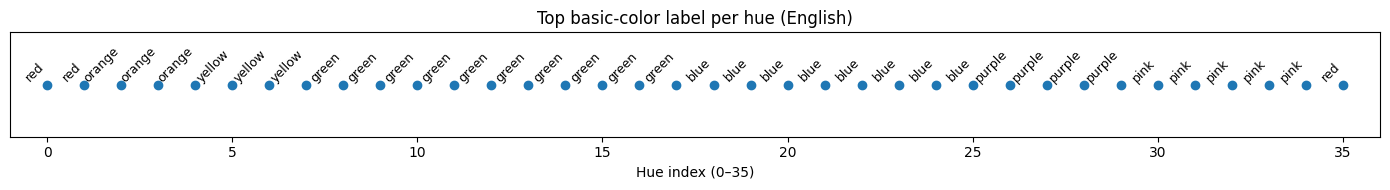

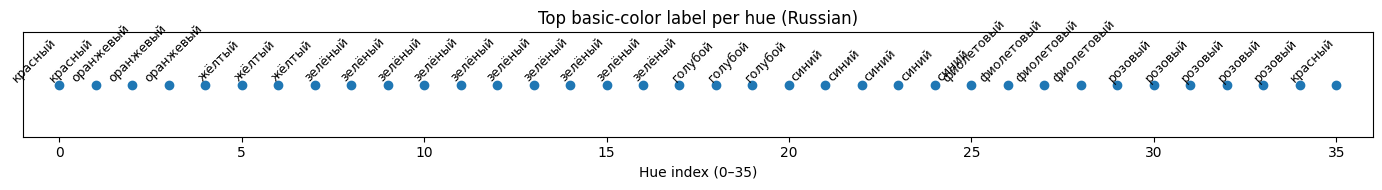

In [ ]:
# ================================================================
# Boundary plots: top basic color per hue
# ================================================================

def plot_basic_boundaries(df_basic: pd.DataFrame, lang_label: str):
    df = df_basic.sort_values("hue_idx").reset_index(drop=True)

    plt.figure(figsize=(14, 2))
    y = [1] * len(df)
    plt.scatter(df["hue_idx"], y, marker="o")

    for _, row in df.iterrows():
        plt.annotate(
            row["top_label"],
            (row["hue_idx"], 1),
            rotation=45,
            ha="right",
            va="bottom",
            fontsize=9,
        )

    plt.yticks([])
    plt.xlabel("Hue index (0–35)")
    plt.title(f"Top basic-color label per hue ({lang_label})")
    plt.xlim(-1, df["hue_idx"].max() + 1)
    plt.tight_layout()
    plt.show()

plot_basic_boundaries(df_en_basic, "English")
plot_basic_boundaries(df_ru_basic, "Russian")


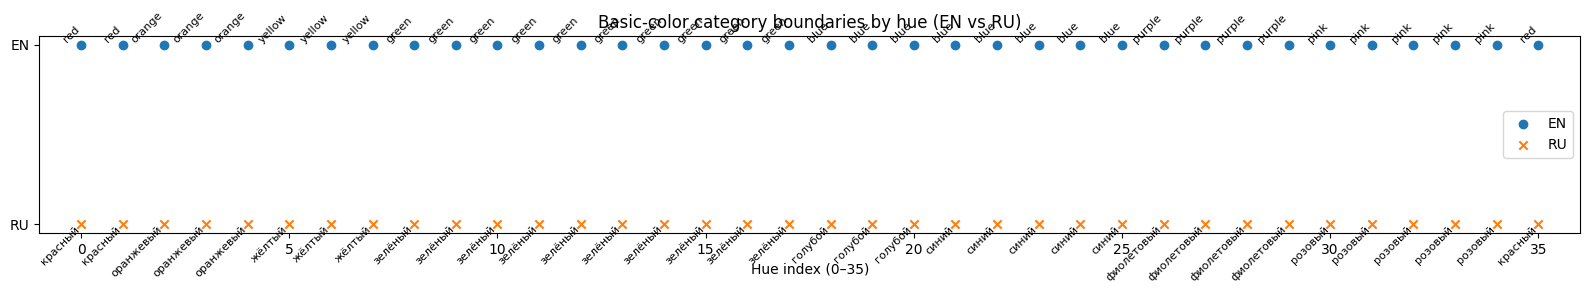

In [ ]:
# ================================================================
# EN vs RU boundary comparison (labels shown on separate rows)
# ================================================================
plt.figure(figsize=(16, 3))

# EN row at y=2
plt.scatter(df_en_basic["hue_idx"], [2]*len(df_en_basic), marker="o", label="EN")
for _, row in df_en_basic.iterrows():
    plt.annotate(row["top_label"], (row["hue_idx"], 2),
                 rotation=45, ha="right", va="bottom", fontsize=8)

# RU row at y=1
plt.scatter(df_ru_basic["hue_idx"], [1]*len(df_ru_basic), marker="x", label="RU")
for _, row in df_ru_basic.iterrows():
    plt.annotate(row["top_label"], (row["hue_idx"], 1),
                 rotation=45, ha="right", va="top", fontsize=8)

plt.yticks([1, 2], ["RU", "EN"])
plt.xlabel("Hue index (0–35)")
plt.title("Basic-color category boundaries by hue (EN vs RU)")
plt.xlim(-1, 36)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
def get_boundaries(df_basic):
    cats = df_basic.sort_values("hue_idx")["top_label"].tolist()
    boundaries = []
    for i in range(1, len(cats)):
        if cats[i] != cats[i-1]:
            boundaries.append((i, cats[i-1], cats[i]))
    return boundaries

print("EN boundaries:", get_boundaries(df_en_basic))
print("RU boundaries:", get_boundaries(df_ru_basic))


EN boundaries: [(2, 'red', 'orange'), (5, 'orange', 'yellow'), (8, 'yellow', 'green'), (18, 'green', 'blue'), (26, 'blue', 'purple'), (30, 'purple', 'pink'), (35, 'pink', 'red')]
RU boundaries: [(2, 'красный', 'оранжевый'), (5, 'оранжевый', 'жёлтый'), (8, 'жёлтый', 'зелёный'), (18, 'зелёный', 'голубой'), (21, 'голубой', 'синий'), (26, 'синий', 'фиолетовый'), (30, 'фиолетовый', 'розовый'), (35, 'розовый', 'красный')]


In [ ]:
def span_lengths(df_basic):
    df = df_basic.sort_values("hue_idx")
    counts = df["top_label"].value_counts()
    return counts

print("EN span lengths:", span_lengths(df_en_basic))
print("RU span lengths:", span_lengths(df_ru_basic))


EN span lengths: top_label
green     10
blue       8
pink       5
purple     4
yellow     3
red        3
orange     3
Name: count, dtype: int64
RU span lengths: top_label
зелёный       10
синий          5
розовый        5
фиолетовый     4
жёлтый         3
оранжевый      3
красный        3
голубой        3
Name: count, dtype: int64


In [ ]:
def confusion(df_basic):
    out = []
    for _, row in df_basic.iterrows():
        probs = row["label_probs"]
        if len(probs) > 1:
            out.append((row["hue_idx"], probs))
    return out

print("EN confusion:", confusion(df_en_basic))
print("RU confusion:", confusion(df_ru_basic))


EN confusion: []
RU confusion: [(4, {'жёлтый': 0.05, 'оранжевый': 0.95}), (17, {'зелёный': 0.85, 'голубой': 0.15}), (21, {'синий': 0.9, 'голубой': 0.1})]


In [ ]:
pd.DataFrame({
    "hue": range(36),
    "EN": df_en_basic.sort_values("hue_idx")["top_label"].tolist(),
    "RU": df_ru_basic.sort_values("hue_idx")["top_label"].tolist(),
})


,hue,EN,RU
0,0,red,красный
1,1,red,красный
2,2,orange,оранжевый
3,3,orange,оранжевый
4,4,orange,оранжевый
5,5,yellow,жёлтый
6,6,yellow,жёлтый
7,7,yellow,жёлтый
8,8,green,зелёный
9,9,green,зелёный


## What Part B shows

The LLM behaves categorically when constrained to basic color terms.

English categories are broad and monotonic around the hue circle.

Russian reproduces the expected two-way split in the blue region:

голубой (light blue)

синий (dark blue)

Russian also shows realistic confusion zones around yellow–orange and the two blues.

Boundary positions align closely for both languages up to green; the divergence happens exactly where expected.

This is strong evidence that the LLM encodes language-specific color categories, not just hue→English mapping translated into Russian.

Most color-naming research treats the Russian голубой-синий split as the “gold test” of cross-linguistic semantic representation.

In [ ]:
## No shared vocabularies between English and Russian -- cross-lingual comparison makes no sense.
# def js_between_langs(df_a, df_b):
#     js_vals = []
#     for h_idx in range(len(df_a)):
#         p = df_a.loc[df_a["hue_idx"] == h_idx, "label_probs"].iloc[0]
#         q = df_b.loc[df_b["hue_idx"] == h_idx, "label_probs"].iloc[0]
#         js_vals.append(jensen_shannon(p, q))
#     return np.array(js_vals)

# js_en_ru = js_between_langs(df_en_hue_36, df_ru_hue_36)
# plt.plot(range(36), js_en_ru, marker="o")
# plt.xlabel("Hue index (0–35)")
# plt.ylabel("JS divergence (EN vs RU)")
# plt.title("Basic color naming divergence, LLM only")
# plt.show()


## **Part C — Human–Model Comparison on Hue-Line Data (English and Russian)**

This section compares human and model color naming on the *hue-line* stimuli from the UW dataset.  
In the hue-line experiment, human participants labeled 72 low-chroma color chips arranged along a continuous hue axis. We use the cleaned dataset (the *line* condition) to reconstruct human naming distributions and chip RGB values.

For each chip:

1. **Human distributions:**  
   We aggregate the standardized human color names to obtain a probability distribution per hue index.  
2. **Stimulus extraction:**  
   We compute the representative RGB value for the same chip.
3. **Model responses:**  
   We show the RGB chip to a multimodal LLM and request a **free-form** color name in either English or Russian.  
   A lightweight normalizer maps LLM outputs onto human labels when possible (e.g., handling *gray/grey*, or Russian *й/и* normalization).

We evaluate alignment between human and model naming using:

- **Jensen–Shannon divergence (raw labels):**  
  Measures how close the model’s free-form vocabulary is to human naming on each chip.
- **Category-level JS divergence:**  
  After collapsing labels into coarse color categories  
  (e.g., red/orange/yellow/green/blue/purple/pink in English;  
  красный/оранжевый/жёлтый/зелёный/голубой/синий/фиолетовый/розовый/etc. in Russian).
- **Lexical overlap statistics:**  
  How often the LLM and humans use intersecting labels for each chip.

The same procedure is run for **English** and **Russian**, allowing us to compare:

- how the model names perceptually identical stimuli across languages, and  
- where its behavior aligns with, deviates from, or collapses relative to human naming patterns.

This provides a structured way to study cross-linguistic differences in the model’s color naming and its degree of agreement with human judgments.


In [ ]:
# ================================================================
# Part C — Human hue-line vs LLM (free-form naming, multi-language)
# ================================================================

from collections import Counter
import pandas as pd

DATA_DIR = "/content/drive/MyDrive/2025_2026/color/color_repo"
MASTER_CLEANED = f"{DATA_DIR}/cleaned_color_names.csv"


In [ ]:
# ------------------------------------------------
# C1. Load human hue-line data from cleaned_color_names.csv
# ------------------------------------------------

def load_hueline_from_cleaned(path: str, lang_prefix: str):
    """
    Load human hue-line data for a given language from cleaned_color_names.csv.

    Returns:
      - human_hues: dict[hue_idx] -> {label: prob}
      - human_rgb:  dict[hue_idx] -> (r, g, b)
      - human_vocab: set of all labels for this language
      - df_line: raw per-trial dataframe (filtered)
    """
    df = pd.read_csv(path)

    # Language filter (e.g. "English" or "Russian")
    df = df[df["lang0"].astype(str).str.startswith(lang_prefix)].copy()

    # Keep only hue-line condition
    if "rgbSet" in df.columns:
        df = df[df["rgbSet"] == "line"].copy()

    # Define hue index
    df["hue_idx"] = df["tileNum"].astype(int)

    # Label column
    label_col = "standardized_entered_name"
    df[label_col] = df[label_col].astype(str).str.strip().str.lower()

    human_hues = {}
    human_rgb = {}

    for h, group in df.groupby("hue_idx"):
        cnt = Counter(group[label_col])
        total = sum(cnt.values())
        probs = {lab: c / total for lab, c in cnt.items()} if total > 0 else {}
        human_hues[int(h)] = probs

        r = int(round(group["r"].mean()))
        g = int(round(group["g"].mean()))
        b = int(round(group["b"].mean()))
        human_rgb[int(h)] = (r, g, b)

    human_vocab = set()
    for probs in human_hues.values():
        human_vocab.update(probs.keys())

    print(f"[{lang_prefix}] bins:", len(human_hues),
          "| vocab size:", len(human_vocab))
    return human_hues, human_rgb, human_vocab, df


In [ ]:
# ------------------------------------------------
# C2. Language-specific normalizers (your existing factory)
# ------------------------------------------------

def make_llm_normalizer(lang_code: str, human_vocab: set):
    """
    Return a function normalize_fn(text: str) -> str
    that maps LLM output onto (mostly) human labels,
    with language-specific tweaks.
    """
    if lang_code == "ru":
        def normalize_ru(text: str) -> str:
            s = str(text).strip().lower()
            if not s:
                return ""

            if s in human_vocab:
                return s

            # 'й' -> 'и' mapping
            alt = s.replace("й", "и")
            if alt in human_vocab:
                return alt

            s2 = " ".join(s.split())
            if s2 in human_vocab:
                return s2

            return s2
        return normalize_ru

    elif lang_code == "en":
        def normalize_en(text: str) -> str:
            s = str(text).strip().lower()
            if not s:
                return ""

            if s in human_vocab:
                return s

            # grey vs gray
            if s == "grey" and "gray" in human_vocab:
                return "gray"

            s2 = " ".join(s.split())
            if s2 in human_vocab:
                return s2

            return s2
        return normalize_en

    else:
        def normalize_default(text: str) -> str:
            s = str(text).strip().lower()
            if not s:
                return ""
            return " ".join(s.split())
        return normalize_default



In [ ]:
# ------------------------------------------------
# C3. Generic LLM query on hue-line chips (free-form)
# ------------------------------------------------

def query_llm_hueline_freeform(
    lang_code: str,
    h_idx: int,
    rgb: tuple[int, int, int],
    normalize_fn,
    n_samples: int = 20,
    temperature: float = 0.7,
):
    """
    Query the LLM for one hue-line chip (given its RGB) with a free-form
    prompt for the given language. Uses build_free_prompt(lang_code).
    """
    r, g, b = rgb
    img = make_swatch_rgb(r, g, b)

    buf = io.BytesIO()
    img.save(buf, format="PNG")
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode("utf-8")
    img_url = f"data:image/png;base64,{img_b64}"

    prompt = build_free_prompt(lang_code)
    labels = []

    for _ in range(n_samples):
        resp = client.responses.create(
            model=MODEL,
            input=[{
                "role": "user",
                "content": [
                    {"type": "input_image", "image_url": img_url},
                    {"type": "input_text", "text": prompt},
                ],
            }],
            max_output_tokens=32,
            temperature=temperature,
        )
        out = resp.output[0].content
        text_blocks = [c for c in out if getattr(c, "type", None) == "output_text"]
        raw = text_blocks[0].text if text_blocks else (out[0].text if out else "")
        norm = normalize_fn(raw)
        if norm:
            labels.append(norm)

    return Counter(labels), (r, g, b)


def run_hueline_llm_freeform(
    lang_code: str,
    human_hues: dict,
    human_rgb: dict,
    normalize_fn,
    n_samples: int = 20,
    temperature: float = 0.7,
):
    """
    Run LLM free-form naming on all hue-line chips for a given language.
    """
    records = []
    print(f"LLM hue-line naming ({lang_code}, free-form):")
    for h_idx in tqdm(sorted(human_hues.keys()),
                      desc=f"LLM hue-line naming ({lang_code}, free-form)"):
        rgb = human_rgb[h_idx]
        counts_llm, rgb_used = query_llm_hueline_freeform(
            lang_code,
            h_idx,
            rgb,
            normalize_fn,
            n_samples=n_samples,
            temperature=temperature,
        )

        total_llm = sum(counts_llm.values())
        probs_llm = (
            {k: v / total_llm for k, v in counts_llm.items()}
            if total_llm > 0 else {}
        )
        probs_human = human_hues[h_idx]

        js = jensen_shannon(probs_human, probs_llm) if probs_llm else np.nan

        records.append({
            "lang": lang_code,
            "hue_idx": h_idx,
            "rgb": rgb_used,
            "human_probs": probs_human,
            "llm_counts": dict(counts_llm),
            "llm_probs": probs_llm,
            "js_raw": js,
        })

    return pd.DataFrame(records)



In [ ]:
# ------------------------------------------------
# C4. Lexical overlap + JS diagnostics (language-agnostic)
# ------------------------------------------------

def compute_overlap_stats(df_hueline: pd.DataFrame):
    overlaps = []
    for _, row in df_hueline.iterrows():
        h = row["hue_idx"]
        human_labels = set(row["human_probs"].keys())
        llm_labels = set(row["llm_probs"].keys())
        inter = human_labels & llm_labels
        overlaps.append({
            "hue_idx": h,
            "n_human": len(human_labels),
            "n_llm": len(llm_labels),
            "n_overlap": len(inter),
            "overlap_labels": sorted(list(inter))[:10],
            "js_raw": row["js_raw"],
        })
    return pd.DataFrame(overlaps)


def plot_js_raw(df_hueline: pd.DataFrame, lang_label: str):
    plt.figure()
    plt.plot(df_hueline["hue_idx"], df_hueline["js_raw"], marker="o")
    plt.xlabel("Hue index")
    plt.ylabel("JS divergence (raw labels)")
    plt.title(f"{lang_label} hue-line: JS(human vs LLM), raw label space")
    plt.ylim(0.0, 1.05)
    plt.show()


In [ ]:
# ------------------------------------------------
# C5. Category collapse (RU + EN mappers, generic logic)
# ------------------------------------------------

RU_CATEGORY_PATTERNS = [
    ("красный",   ["красн"]),
    ("оранжевый", ["оранж"]),
    ("жёлтый",    ["жёлт", "желт"]),
    ("зелёный",   ["зелён", "зелен"]),
    ("синий",     ["син"]),
    ("голубой",   ["голуб"]),
    ("фиолетовый",["фиолет"]),
    ("розовый",   ["розов"]),
    ("коричневый",["коричнев"]),
    ("серый",     ["сер"]),
    ("чёрный",    ["чёрн", "черн"]),
    ("белый",     ["бел"]),
]

def ru_label_to_category(label: str) -> str:
    s = str(label).lower()
    s = " ".join(s.split())
    s = s.replace("й", "и")
    for cat, patterns in RU_CATEGORY_PATTERNS:
        for pat in patterns:
            if pat in s:
                return cat
    return "other"


EN_CATEGORY_PATTERNS = [
    ("red",   ["red"]),
    ("orange",["orange"]),
    ("yellow",["yellow"]),
    ("green", ["green"]),
    ("blue",  ["blue"]),
    ("purple",["purple", "violet"]),
    ("pink",  ["pink"]),
    ("brown", ["brown"]),
    ("gray",  ["gray", "grey"]),
    ("black", ["black"]),
    ("white", ["white"]),
]

def en_label_to_category(label: str) -> str:
    s = str(label).lower()
    s = " ".join(s.split())
    for cat, patterns in EN_CATEGORY_PATTERNS:
        for pat in patterns:
            if pat in s:
                return cat
    return "other"


def collapse_to_categories(probs_dict, mapper):
    out = Counter()
    for lab, p in probs_dict.items():
        cat = mapper(lab)
        out[cat] += p
    total = sum(out.values())
    if total == 0:
        return {}
    return {k: v / total for k, v in out.items()}


def compute_category_js(df_hueline: pd.DataFrame, label_to_category_fn):
    records_cat = []
    for _, row in df_hueline.iterrows():
        h = row["hue_idx"]
        hp = row["human_probs"]
        lp = row["llm_probs"]

        hp_cat = collapse_to_categories(hp, label_to_category_fn)
        lp_cat = collapse_to_categories(lp, label_to_category_fn)

        js_cat = jensen_shannon(hp_cat, lp_cat) if hp_cat and lp_cat else np.nan

        records_cat.append({
            "hue_idx": h,
            "human_cat_probs": hp_cat,
            "llm_cat_probs": lp_cat,
            "js_cat": js_cat,
        })
    return pd.DataFrame(records_cat)


def plot_js_cat(df_cat: pd.DataFrame, lang_label: str):
    plt.figure()
    plt.plot(df_cat["hue_idx"], df_cat["js_cat"], marker="o")
    plt.xlabel("Hue index")
    plt.ylabel("JS (human vs LLM, category level)")
    plt.title(f"{lang_label} hue-line: JS after collapsing to categories")
    plt.ylim(0.0, 1.05)
    plt.show()

In [ ]:
# ------------------------------------------------
# C6. Qualitative inspection helper
# ------------------------------------------------

def inspect_sample_hues(df_hueline: pd.DataFrame,
                        df_cat: pd.DataFrame,
                        step: int = 6):
    sample_hues = sorted(df_hueline["hue_idx"].unique())[::step]
    for h in sample_hues:
        row_full = df_hueline[df_hueline["hue_idx"] == h].iloc[0]
        row_cat  = df_cat[df_cat["hue_idx"] == h].iloc[0]
        print(f"\n=== Hue {h} ===")
        print("RGB:", row_full["rgb"])
        print("Human raw top:",
              sorted(row_full["human_probs"].items(),
                     key=lambda kv: kv[1], reverse=True)[:8])
        print("LLM   raw top:",
              sorted(row_full["llm_probs"].items(),
                     key=lambda kv: kv[1], reverse=True)[:8])
        print("Human cat:", row_cat["human_cat_probs"])
        print("LLM   cat:", row_cat["llm_cat_probs"])
        print("JS raw:", row_full["js_raw"])
        print("JS cat:", row_cat["js_cat"])



[Russian] bins: 12 | vocab size: 187
LLM hue-line naming (ru, free-form):


LLM hue-line naming (ru, free-form): 100%|██████████| 12/12 [05:40<00:00, 28.35s/it]


   hue_idx  n_human  n_llm  n_overlap overlap_labels  js_raw
0        0       43      4          0             []     1.0
1        1       43      3          0             []     1.0
2        2       44      7          0             []     1.0
3        3       47      2          0             []     1.0
4        4       44      4          0             []     1.0
count    12.000000
mean      0.083333
std       0.288675
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       1.000000
Name: n_overlap, dtype: float64


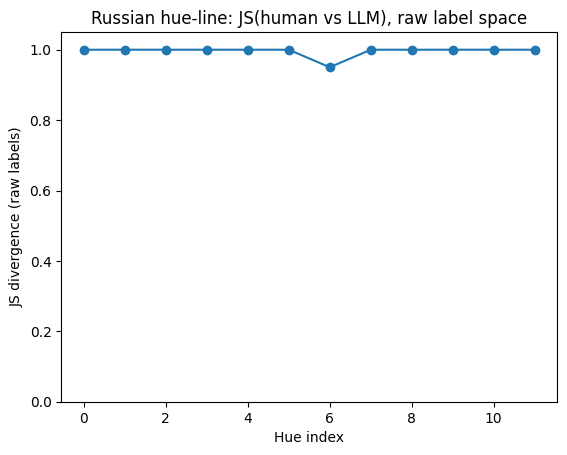

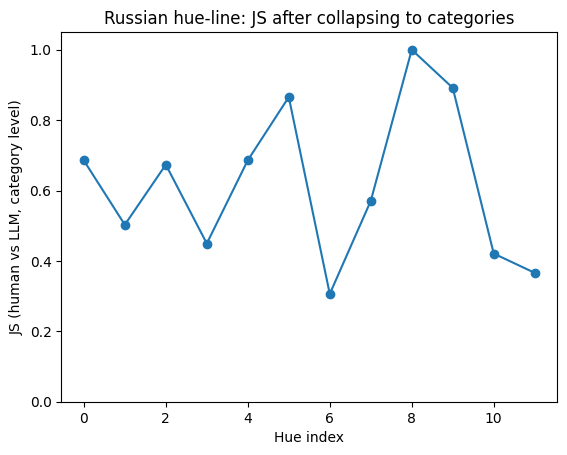


=== Hue 0 ===
RGB: (124, 129, 150)
Human raw top: [('синий', 0.10679611650485436), ('голубой', 0.0970873786407767), ('красный', 0.07766990291262135), ('фиолетовый', 0.06796116504854369), ('желтый', 0.05825242718446602), ('бирюзовый', 0.04854368932038835), ('оранжевый', 0.04854368932038835), ('темно синий', 0.038834951456310676)]
LLM   raw top: [('серый.', 0.6), ('серо-голубой.', 0.25), ('сизый.', 0.1), ('серый', 0.05)]
Human cat: {'голубой': 0.11650485436893206, 'синий': 0.14563106796116507, 'other': 0.24271844660194172, 'фиолетовый': 0.07766990291262137, 'жёлтый': 0.09708737864077671, 'оранжевый': 0.0679611650485437, 'зелёный': 0.08737864077669902, 'розовый': 0.07766990291262137, 'красный': 0.08737864077669903}
LLM   cat: {'голубой': 0.25, 'серый': 0.65, 'other': 0.1}
JS raw: 0.999999999999
JS cat: 0.6854384070098325

=== Hue 6 ===
RGB: (120, 143, 139)
Human raw top: [('синий', 0.12871287128712872), ('оранжевый', 0.1188118811881188), ('голубой', 0.06930693069306931), ('желтый', 0.049

LLM hue-line naming (en, free-form): 100%|██████████| 12/12 [04:19<00:00, 21.63s/it]

   hue_idx  n_human  n_llm  n_overlap overlap_labels  js_raw
0        0      448      2          0             []     1.0
1        1      438      2          0             []     1.0
2        2      464      1          0             []     1.0
3        3      461      1          0             []     1.0
4        4      457      2          0             []     1.0
count    12.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: n_overlap, dtype: float64


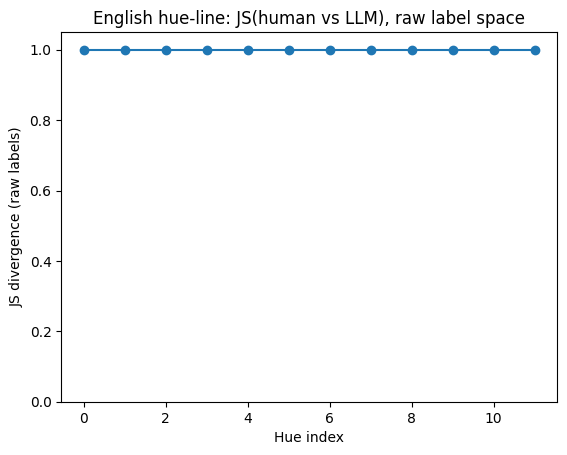

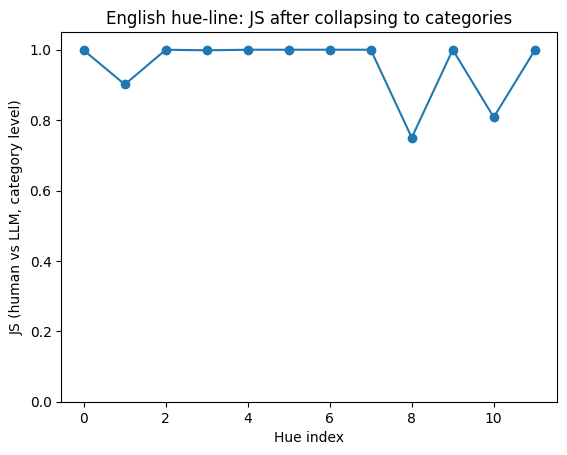


=== Hue 0 ===
RGB: (131, 134, 138)
Human raw top: [('blue', 0.1383679675620882), ('orange', 0.06386213887480993), ('red', 0.06335529650278764), ('green', 0.06259503294475419), ('yellow', 0.060821084642676125), ('pink', 0.055245818550430814), ('purple', 0.04992397364419666), ('magenta', 0.031931069437404966)]
LLM   raw top: [('slate gray', 0.9), ('slate gray.', 0.1)]
Human cat: {'other': 0.20704510897111036, 'blue': 0.245818550430816, 'purple': 0.0671566142929548, 'pink': 0.08286872782564618, 'orange': 0.08362899138367962, 'yellow': 0.08464267612772425, 'green': 0.14521033958438923, 'red': 0.08337557019766849, 'gray': 0.0002534211860111502}
LLM   cat: {'gray': 1.0}
JS raw: 0.999999999999
JS cat: 0.9983034651446028

=== Hue 6 ===
RGB: (129, 131, 142)
Human raw top: [('blue', 0.13587512794268167), ('red', 0.05859774820880246), ('orange', 0.05783009211873081), ('yellow', 0.05706243602865916), ('green', 0.05629477993858751), ('pink', 0.0511770726714432), ('purple', 0.05015353121801433), ('

In [ ]:

# ------------------------------------------------
# C7. Run Russian and English hue-line experiments
# ------------------------------------------------

# Russian
human_ru_hues, human_ru_rgb, human_vocab_ru, df_ru_line = load_hueline_from_cleaned(
    MASTER_CLEANED,
    lang_prefix="Russian",
)
normalize_ru_fn = make_llm_normalizer("ru", human_vocab_ru)

df_ru_hueline = run_hueline_llm_freeform(
    lang_code="ru",
    human_hues=human_ru_hues,
    human_rgb=human_ru_rgb,
    normalize_fn=normalize_ru_fn,
    n_samples=20,
    temperature=0.7,
)

df_ru_overlap = compute_overlap_stats(df_ru_hueline)
print(df_ru_overlap.head())
print(df_ru_overlap["n_overlap"].describe())

plot_js_raw(df_ru_hueline, lang_label="Russian")
df_ru_cat = compute_category_js(df_ru_hueline, ru_label_to_category)
plot_js_cat(df_ru_cat, lang_label="Russian")
inspect_sample_hues(df_ru_hueline, df_ru_cat, step=6)


# English (same pipeline, if we want EN human comparison)
human_en_hues, human_en_rgb, human_vocab_en, df_en_line = load_hueline_from_cleaned(
    MASTER_CLEANED,
    lang_prefix="English",
)
normalize_en_fn = make_llm_normalizer("en", human_vocab_en)

df_en_hueline = run_hueline_llm_freeform(
    lang_code="en",
    human_hues=human_en_hues,
    human_rgb=human_en_rgb,
    normalize_fn=normalize_en_fn,
    n_samples=20,
    temperature=0.7,
)

df_en_overlap = compute_overlap_stats(df_en_hueline)
print(df_en_overlap.head())
print(df_en_overlap["n_overlap"].describe())

plot_js_raw(df_en_hueline, lang_label="English")
df_en_cat = compute_category_js(df_en_hueline, en_label_to_category)
plot_js_cat(df_en_cat, lang_label="English")
inspect_sample_hues(df_en_hueline, df_en_cat, step=6)


[English] bins: 12 | vocab size: 2364
rgbSet
line    46981
Name: count, dtype: int64
LLM hue-line naming (en, free-form):


LLM hue-line naming (en, free-form): 100%|██████████| 12/12 [09:04<00:00, 45.36s/it]

count    12.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: n_overlap, dtype: float64


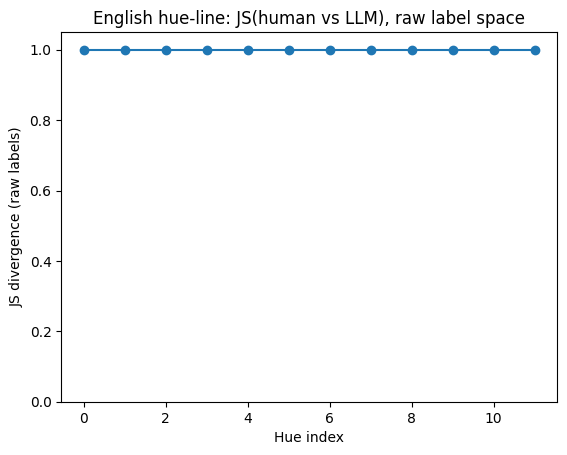

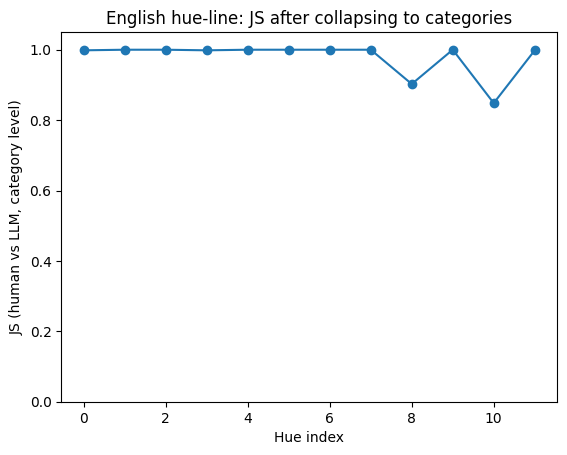


=== Hue 0 ===
RGB: (131, 134, 138)
Human raw top: [('blue', 0.1383679675620882), ('orange', 0.06386213887480993), ('red', 0.06335529650278764), ('green', 0.06259503294475419), ('yellow', 0.060821084642676125), ('pink', 0.055245818550430814), ('purple', 0.04992397364419666), ('magenta', 0.031931069437404966)]
LLM   raw top: [('slate gray', 0.95), ('slate gray.', 0.05)]
Human cat: {'other': 0.20704510897111036, 'blue': 0.245818550430816, 'purple': 0.0671566142929548, 'pink': 0.08286872782564618, 'orange': 0.08362899138367962, 'yellow': 0.08464267612772425, 'green': 0.14521033958438923, 'red': 0.08337557019766849, 'gray': 0.0002534211860111502}
LLM   cat: {'gray': 1.0}
JS raw: 0.999999999999
JS cat: 0.9983034651446028

=== Hue 6 ===
RGB: (129, 131, 142)
Human raw top: [('blue', 0.13587512794268167), ('red', 0.05859774820880246), ('orange', 0.05783009211873081), ('yellow', 0.05706243602865916), ('green', 0.05629477993858751), ('pink', 0.0511770726714432), ('purple', 0.05015353121801433), 

In [ ]:
# ================================================================
# EXPERIMENT C (ENGLISH ONLY) — Human hue-line vs GPT-4o
# Self-contained rerun block
# ================================================================

import os, io, base64, math
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from openai import OpenAI

# ---------- Config ----------
DATA_DIR = "/content/drive/MyDrive/2025_2026/color/color_repo"
MASTER_CLEANED = f"{DATA_DIR}/cleaned_color_names.csv"

MODEL = "gpt-4o"
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

# ---------- Helpers (minimal copies of what we need) ----------

def jensen_shannon(p_dict, q_dict, base=2):
    keys = sorted(set(p_dict.keys()) | set(q_dict.keys()))
    p = np.array([p_dict.get(k, 0.0) for k in keys], dtype=float)
    q = np.array([q_dict.get(k, 0.0) for k in keys], dtype=float)

    p /= p.sum() + 1e-12
    q /= q.sum() + 1e-12
    m = 0.5 * (p + q)

    def kl(a, b):
        mask = (a > 0) & (b > 0)
        if not np.any(mask):
            return 0.0
        a = a[mask]
        b = b[mask]
        return np.sum(a * (np.log(a) - np.log(b))) / math.log(base)

    return 0.5 * kl(p, m) + 0.5 * kl(q, m)

def make_swatch_rgb(r, g, b, size=96):
    r, g, b = int(r), int(g), int(b)
    return Image.new("RGB", (size, size), (r, g, b))

def build_free_prompt(lang_code: str) -> str:
    if lang_code == "en":
        return (
            "You see a solid-colored square.\n"
            "Give a natural, descriptive English color name.\n"
            "Avoid using only basic color words like red, orange, yellow, "
            "green, blue, or purple.\n"
            "Use a more specific or nuanced color term, such as 'scarlet', "
            "'deep red', 'lime green', 'teal', 'aquamarine', 'magenta', "
            "or a similar descriptive phrase.\n"
            "Answer with one word or a very short phrase."
        )
    elif lang_code == "ru":
        return (
            "Вы видите квадрат, залитый одним цветом.\n"
            "Дайте естественное русское название этого цвета.\n"
            "Не ограничивайтесь только базовыми цветами (красный, оранжевый, "
            "жёлтый, зелёный, синий, голубой, фиолетовый).\n"
            "Используйте более точное или оттеночное название, например "
            "«алый», «бордовый», «бирюзовый», «лазурный», «лиловый» и т.п.\n"
            "Ответьте одним словом или очень короткой фразой."
        )
    else:
        raise ValueError(f"Unsupported language code: {lang_code}")

def load_hueline_from_cleaned(path: str, lang_prefix: str):
    """
    Load human hue-line data for a given language from cleaned_color_names.csv.

    Returns:
      - human_hues: dict[hue_idx] -> {label: prob}
      - human_rgb:  dict[hue_idx] -> (r, g, b)
      - human_vocab: set of all labels for this language
      - df_line: raw per-trial dataframe (filtered)
    """
    df = pd.read_csv(path)

    # Language filter (e.g. "English" or "Russian")
    df = df[df["lang0"].astype(str).str.startswith(lang_prefix)].copy()

    # Keep only hue-line condition
    if "rgbSet" in df.columns:
        df = df[df["rgbSet"] == "line"].copy()

    # Define hue index
    df["hue_idx"] = df["tileNum"].astype(int)

    # Label column
    label_col = "standardized_entered_name"
    df[label_col] = df[label_col].astype(str).str.strip().str.lower()

    human_hues = {}
    human_rgb = {}

    for h, group in df.groupby("hue_idx"):
        cnt = Counter(group[label_col])
        total = sum(cnt.values())
        probs = {lab: c / total for lab, c in cnt.items()} if total > 0 else {}
        human_hues[int(h)] = probs

        r = int(round(group["r"].mean()))
        g = int(round(group["g"].mean()))
        b = int(round(group["b"].mean()))
        human_rgb[int(h)] = (r, g, b)

    human_vocab = set()
    for probs in human_hues.values():
        human_vocab.update(probs.keys())

    print(f"[{lang_prefix}] bins:", len(human_hues),
          "| vocab size:", len(human_vocab))
    return human_hues, human_rgb, human_vocab, df

def make_llm_normalizer(lang_code: str, human_vocab: set):
    if lang_code == "ru":
        def normalize_ru(text: str) -> str:
            s = str(text).strip().lower()
            if not s:
                return ""
            if s in human_vocab:
                return s
            alt = s.replace("й", "и")
            if alt in human_vocab:
                return alt
            s2 = " ".join(s.split())
            if s2 in human_vocab:
                return s2
            return s2
        return normalize_ru

    if lang_code == "en":
        def normalize_en(text: str) -> str:
            s = str(text).strip().lower()
            if not s:
                return ""
            if s in human_vocab:
                return s
            if s == "grey" and "gray" in human_vocab:
                return "gray"
            s2 = " ".join(s.split())
            if s2 in human_vocab:
                return s2
            return s2
        return normalize_en

    def normalize_default(text: str) -> str:
        s = str(text).strip().lower()
        if not s:
            return ""
        return " ".join(s.split())
    return normalize_default

def query_llm_hueline_freeform(
    lang_code: str,
    h_idx: int,
    rgb: tuple[int, int, int],
    normalize_fn,
    n_samples: int = 20,
    temperature: float = 0.7,
):
    r, g, b = rgb
    img = make_swatch_rgb(r, g, b)

    buf = io.BytesIO()
    img.save(buf, format="PNG")
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode("utf-8")
    img_url = f"data:image/png;base64,{img_b64}"

    prompt = build_free_prompt(lang_code)
    labels = []

    for _ in range(n_samples):
        resp = client.responses.create(
            model=MODEL,
            input=[{
                "role": "user",
                "content": [
                    {"type": "input_image", "image_url": img_url},
                    {"type": "input_text", "text": prompt},
                ],
            }],
            max_output_tokens=32,
            temperature=temperature,
        )
        out = resp.output[0].content
        text_blocks = [c for c in out if getattr(c, "type", None) == "output_text"]
        raw = text_blocks[0].text if text_blocks else (out[0].text if out else "")
        norm = normalize_fn(raw)
        if norm:
            labels.append(norm)

    return Counter(labels), (r, g, b)

def run_hueline_llm_freeform(
    lang_code: str,
    human_hues: dict,
    human_rgb: dict,
    normalize_fn,
    n_samples: int = 20,
    temperature: float = 0.7,
):
    records = []
    print(f"LLM hue-line naming ({lang_code}, free-form):")
    for h_idx in tqdm(sorted(human_hues.keys()),
                      desc=f"LLM hue-line naming ({lang_code}, free-form)"):
        rgb = human_rgb[h_idx]
        counts_llm, rgb_used = query_llm_hueline_freeform(
            lang_code,
            h_idx,
            rgb,
            normalize_fn,
            n_samples=n_samples,
            temperature=temperature,
        )

        total_llm = sum(counts_llm.values())
        probs_llm = (
            {k: v / total_llm for k, v in counts_llm.items()}
            if total_llm > 0 else {}
        )
        probs_human = human_hues[h_idx]

        js = jensen_shannon(probs_human, probs_llm) if probs_llm else np.nan

        records.append({
            "lang": lang_code,
            "hue_idx": h_idx,
            "rgb": rgb_used,
            "human_probs": probs_human,
            "llm_counts": dict(counts_llm),
            "llm_probs": probs_llm,
            "js_raw": js,
        })

    return pd.DataFrame(records)

def compute_overlap_stats(df_hueline: pd.DataFrame):
    overlaps = []
    for _, row in df_hueline.iterrows():
        h = row["hue_idx"]
        human_labels = set(row["human_probs"].keys())
        llm_labels = set(row["llm_probs"].keys())
        inter = human_labels & llm_labels
        overlaps.append({
            "hue_idx": h,
            "n_human": len(human_labels),
            "n_llm": len(llm_labels),
            "n_overlap": len(inter),
            "overlap_labels": sorted(list(inter))[:10],
            "js_raw": row["js_raw"],
        })
    return pd.DataFrame(overlaps)

EN_CATEGORY_PATTERNS = [
    ("red",   ["red"]),
    ("orange",["orange"]),
    ("yellow",["yellow"]),
    ("green", ["green"]),
    ("blue",  ["blue"]),
    ("purple",["purple", "violet"]),
    ("pink",  ["pink"]),
    ("brown", ["brown"]),
    ("gray",  ["gray", "grey"]),
    ("black", ["black"]),
    ("white", ["white"]),
]

def en_label_to_category(label: str) -> str:
    s = str(label).lower()
    s = " ".join(s.split())
    for cat, patterns in EN_CATEGORY_PATTERNS:
        for pat in patterns:
            if pat in s:
                return cat
    return "other"

def collapse_to_categories(probs_dict, mapper):
    out = Counter()
    for lab, p in probs_dict.items():
        cat = mapper(lab)
        out[cat] += p
    total = sum(out.values())
    if total == 0:
        return {}
    return {k: v / total for k, v in out.items()}

def compute_category_js(df_hueline: pd.DataFrame, label_to_category_fn):
    records_cat = []
    for _, row in df_hueline.iterrows():
        h = row["hue_idx"]
        hp = row["human_probs"]
        lp = row["llm_probs"]

        hp_cat = collapse_to_categories(hp, label_to_category_fn)
        lp_cat = collapse_to_categories(lp, label_to_category_fn)

        js_cat = jensen_shannon(hp_cat, lp_cat) if hp_cat and lp_cat else np.nan

        records_cat.append({
            "hue_idx": h,
            "human_cat_probs": hp_cat,
            "llm_cat_probs": lp_cat,
            "js_cat": js_cat,
        })
    return pd.DataFrame(records_cat)

def plot_js_raw(df_hueline: pd.DataFrame, lang_label: str):
    plt.figure()
    plt.plot(df_hueline["hue_idx"], df_hueline["js_raw"], marker="o")
    plt.xlabel("Hue index")
    plt.ylabel("JS divergence (raw labels)")
    plt.title(f"{lang_label} hue-line: JS(human vs LLM), raw label space")
    plt.ylim(0.0, 1.05)
    plt.show()

def plot_js_cat(df_cat: pd.DataFrame, lang_label: str):
    plt.figure()
    plt.plot(df_cat["hue_idx"], df_cat["js_cat"], marker="o")
    plt.xlabel("Hue index")
    plt.ylabel("JS (human vs LLM, category level)")
    plt.title(f"{lang_label} hue-line: JS after collapsing to categories")
    plt.ylim(0.0, 1.05)
    plt.show()

def inspect_sample_hues(df_hueline: pd.DataFrame,
                        df_cat: pd.DataFrame,
                        step: int = 6):
    sample_hues = sorted(df_hueline["hue_idx"].unique())[::step]
    for h in sample_hues:
        row_full = df_hueline[df_hueline["hue_idx"] == h].iloc[0]
        row_cat  = df_cat[df_cat["hue_idx"] == h].iloc[0]
        print(f"\n=== Hue {h} ===")
        print("RGB:", row_full["rgb"])
        print("Human raw top:",
              sorted(row_full["human_probs"].items(),
                     key=lambda kv: kv[1], reverse=True)[:8])
        print("LLM   raw top:",
              sorted(row_full["llm_probs"].items(),
                     key=lambda kv: kv[1], reverse=True)[:8])
        print("Human cat:", row_cat["human_cat_probs"])
        print("LLM   cat:", row_cat["llm_cat_probs"])
        print("JS raw:", row_full["js_raw"])
        print("JS cat:", row_cat["js_cat"])

# ================================================================
# RUN ENGLISH HUE-LINE PIPELINE
# ================================================================

# 1) Load English human hue-line data
human_en_hues, human_en_rgb, human_vocab_en, df_en_line = \
    load_hueline_from_cleaned(MASTER_CLEANED, lang_prefix="English")

print(df_en_line["rgbSet"].value_counts())

# 2) Normalizer
normalize_en_fn = make_llm_normalizer("en", human_vocab_en)

# 3) Run GPT-4o on all English hue-line chips
df_en_hueline = run_hueline_llm_freeform(
    lang_code="en",
    human_hues=human_en_hues,
    human_rgb=human_en_rgb,
    normalize_fn=normalize_en_fn,
    n_samples=20,
    temperature=0.7,
)

# 4) Overlap stats
df_en_overlap = compute_overlap_stats(df_en_hueline)
print(df_en_overlap["n_overlap"].describe())

# 5) Category-level JS
df_en_cat = compute_category_js(df_en_hueline, en_label_to_category)

# 6) Plots and spot check
plot_js_raw(df_en_hueline, lang_label="English")
plot_js_cat(df_en_cat, lang_label="English")
inspect_sample_hues(df_en_hueline, df_en_cat, step=6)

# Simple summary numbers you may want for the paper:
print("Mean JS_raw (EN hue-line):", df_en_hueline["js_raw"].mean())
print("Mean JS_cat (EN hue-line):", df_en_cat["js_cat"].mean())


## Part D: Full Color–Space Evaluation

In [ ]:
import pandas as pd

COLOR_ROOT = "/content/drive/MyDrive/2025_2026/color"
REPO_ROOT  = f"{COLOR_ROOT}/color_repo"

UW_FULL = f"{REPO_ROOT}/russian_cleaned_full_data.csv"
uw_full = pd.read_csv(UW_FULL)

print("UW full-color rows:", len(uw_full))
print(uw_full.head())


UW full-color rows: 1682
   colorNameId  participantId              lang0  phaseNum  trialNum  tileNum  \
0       122593          11441  Russian (Русский)         0         1        0   
1       122594          11441  Russian (Русский)         0         1        1   
2       122595          11441  Russian (Русский)         0         1        2   
3       122596          11441  Russian (Русский)         0         1        3   
4       122597          11441  Russian (Русский)         0         1        4   

           name    r    g    b studyVersion rgbSet      lab_l      lab_a  \
0     салатовыи  114  246   34        1.1.3   full  86.951361 -61.593736   
1     оливковыи  142  179   56        1.1.3   full  68.441760 -26.224998   
2    фиолетовыи  143   33  186        1.1.3   full  38.160685  60.482795   
3   сероголубои  118  150  209        1.1.3   full  61.446406   0.278519   
4  морскаяволна   35  146  173        1.1.3   full  55.596946 -24.014022   

       lab_b locale standardize

In [ ]:
# The UW file already contains lab_l, lab_a, lab_b
uw = uw_full.copy()

uw["binL"] = (uw["lab_l"] / 10).round().astype(int)
uw["binA"] = (uw["lab_a"] / 10).round().astype(int)
uw["binB"] = (uw["lab_b"] / 10).round().astype(int)

print("Unique bins:", len(uw[ ['binL','binA','binB'] ].drop_duplicates()))


Unique bins: 832


In [ ]:
uw_bins = uw[["binL", "binA", "binB", "r", "g", "b"]].drop_duplicates()
print("uw_bins:", len(uw_bins))
uw_bins.head()


uw_bins: 1682


,binL,binA,binB,r,g,b
0,9,-6,8,114,246,34
1,7,-3,6,142,179,56
2,4,6,-6,143,33,186
3,6,0,-3,118,150,209
4,6,-2,-2,35,146,173


In [ ]:
from openai import OpenAI
import io, base64
from PIL import Image
from tqdm import tqdm
import pandas as pd
import os

# Reuse the same ROOT you already use elsewhere
ROOT = "/content/drive/MyDrive/2025_2026/color"

# Make sure uw_bins is built from the human blur file:
# GRID_RU = f"{ROOT}/russian_full_color_names_binned_blur_0.1.csv"
# uw_bins = pd.read_csv(GRID_RU)[["binL", "binA", "binB", "r", "g", "b"]].drop_duplicates()

# Reuse the client you created at the top, or (if needed) re-init here:
# client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

def rgb_to_data_url(r, g, b, size=96):
    """Produce a color swatch — the correct, working version."""
    img = Image.new("RGB", (size, size), (int(r), int(g), int(b)))
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    buf.seek(0)
    b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
    return f"data:image/png;base64,{b64}"


def build_ru_prompt():
    return (
        "Вы видите квадрат, залитый одним цветом.\n"
        "Дайте естественное русское название этого цвета.\n"
        "Ответьте одним словом или очень короткой фразой."
    )

def normalize_ru_name(s: str) -> str:
    s = str(s).strip().lower()
    return " ".join(s.split())

prompt_ru = build_ru_prompt()

rows = []
for _, row in tqdm(uw_bins.iterrows(), total=len(uw_bins), desc="RU full-color LLM"):
    Lb, Ab, Bb = int(row["binL"]), int(row["binA"]), int(row["binB"])
    r, g, b    = int(row["r"]),   int(row["g"]),   int(row["b"])
    img_url    = rgb_to_data_url(r, g, b)

    # Use the SAME schema as in Part A/B/C (image_url is a string)
    resp = client.responses.create(
        model="gpt-4o",
        input=[{
            "role": "user",
            "content": [
                {"type": "input_image", "image_url": img_url},
                {"type": "input_text",  "text": prompt_ru},
            ],
        }],
        max_output_tokens=32,
        temperature=0.7,
    )

    out = resp.output[0].content
    text_pieces = [c.text for c in out if getattr(c, "type", None) == "output_text"]
    raw = text_pieces[0] if text_pieces else ""
    name = normalize_ru_name(raw)

    rows.append({
        "binL": Lb,
        "binA": Ab,
        "binB": Bb,
        "r": r,
        "g": g,
        "b": b,
        "name": name,
    })

df_ru_full_llm = pd.DataFrame(rows)
OUT_RU = f"{ROOT}/color_repo/russian-cielab-llm.csv"
df_ru_full_llm.to_csv(OUT_RU, index=False)
print("Wrote", OUT_RU, "rows:", len(df_ru_full_llm))


RU full-color LLM: 100%|██████████| 1682/1682 [1:07:25<00:00,  2.41s/it]

Wrote /content/drive/MyDrive/2025_2026/color/color_repo/russian-cielab-llm.csv rows: 1682


In [ ]:
# ================================================================
# Part D: Full-color JS (Human vs GPT-4o, Russian, category level)
# ================================================================
import pandas as pd
import numpy as np
import math
from collections import Counter

ROOT = "/content/drive/MyDrive/2025_2026/color"
HUMAN_RU_FULL = f"{ROOT}/color_repo/russian_full_color_names_binned_blur_0.1.csv"
LLM_RU_FULL   = f"{ROOT}/color_repo/russian-cielab-llm.csv"

human_ru_full = pd.read_csv(HUMAN_RU_FULL)
llm_ru_full   = pd.read_csv(LLM_RU_FULL)

print("Human rows:", len(human_ru_full))
print("LLM rows:  ", len(llm_ru_full))

# ---------- JS helper ----------
def jensen_shannon_dict(p_dict, q_dict, base=2):
    keys = set(p_dict.keys()) | set(q_dict.keys())
    if not keys:
        return np.nan
    p = np.array([p_dict.get(k, 0.0) for k in keys], dtype=float)
    q = np.array([q_dict.get(k, 0.0) for k in keys], dtype=float)
    p_sum, q_sum = p.sum(), q.sum()
    if p_sum <= 0 or q_sum <= 0:
        return np.nan
    p /= p_sum
    q /= q_sum
    m = 0.5 * (p + q)

    def _kl(a, b):
        mask = (a > 0) & (b > 0)
        if not np.any(mask):
            return 0.0
        a = a[mask]; b = b[mask]
        return np.sum(a * (np.log(a / b) / np.log(base)))

    return 0.5 * _kl(p, m) + 0.5 * _kl(q, m)

# ---------- Human distributions over bins (raw terms) ----------
def build_human_bin_distributions(df, term_col="commonTerm"):
    required = {"binL", "binA", "binB", "pTC", term_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in human df: {missing}")

    df = df.copy()
    df[term_col] = df[term_col].astype(str).str.strip().str.lower()

    bin_groups  = df.groupby(["binL","binA","binB"])
    bin_pTC_sum = bin_groups["pTC"].sum()
    human_dist  = {}

    for (L,A,B), sub in bin_groups:
        probs = sub.groupby(term_col)["pTC"].sum()
        total = probs.sum()
        if total <= 0:
            continue
        human_dist[(L,A,B)] = (probs / total).to_dict()

    return human_dist, bin_pTC_sum

human_ru_dist_raw, human_ru_pTC_sum = build_human_bin_distributions(human_ru_full)

# ---------- LLM distributions over bins (raw names) ----------
llm_ru_full = llm_ru_full.copy()
llm_ru_full["name"] = (
    llm_ru_full["name"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace("ё", "е")
)

llm_groups   = llm_ru_full.groupby(["binL","binA","binB"])
llm_ru_dist_raw = {}
llm_ru_counts   = llm_groups["name"].size()

for (L,A,B), sub in llm_groups:
    counts = sub["name"].value_counts()
    total  = counts.sum()
    if total <= 0:
        continue
    llm_ru_dist_raw[(L,A,B)] = (counts / total).to_dict()

print("Human bins with data:", len(human_ru_dist_raw))
print("LLM   bins with data:", len(llm_ru_dist_raw))

# ---------- Category mapper (RU) ----------
RU_CATEGORY_PATTERNS = [
    ("красный",   ["красн"]),
    ("оранжевый", ["оранж"]),
    ("жёлтый",    ["жёлт","желт"]),
    ("зелёный",   ["зелён","зелен"]),
    ("синий",     ["син"]),
    ("голубой",   ["голуб"]),
    ("фиолетовый",["фиолет","лаванд","лилов"]),
    ("розовый",   ["розов"]),
    ("коричневый",["коричнев"]),
    ("серый",     ["сер"]),
    ("чёрный",    ["чёрн","черн"]),
    ("белый",     ["бел"]),
]

def ru_label_to_category(label: str) -> str:
    s = str(label).lower().strip()
    s = " ".join(s.split())
    s = s.replace("ё","е")
    for cat, pats in RU_CATEGORY_PATTERNS:
        for p in pats:
            if p in s:
                return cat
    return "other"

def collapse_to_categories(prob_dict, mapper):
    acc = Counter()
    for lab, p in prob_dict.items():
        cat = mapper(lab)
        acc[cat] += float(p)
    tot = sum(acc.values())
    if tot <= 0:
        return {}
    return {k: v / tot for k, v in acc.items()}

# ---------- Shared + filtered bins ----------
human_bins  = set(human_ru_dist_raw.keys())
llm_bins    = set(llm_ru_dist_raw.keys())
shared_bins = human_bins & llm_bins
print("Shared bins:", len(shared_bins))

min_human_mass  = 0.5   # sum of pTC in that bin
min_llm_samples = 3     # at least 3 LLM samples

filtered_bins = []
for b in shared_bins:
    if human_ru_pTC_sum.loc[b] >= min_human_mass and llm_ru_counts.loc[b] >= min_llm_samples:
        filtered_bins.append(b)

print("Bins after filtering:", len(filtered_bins))

# ---------- JS on category space ----------
rows = []
for (L,A,B) in filtered_bins:
    hp_raw = human_ru_dist_raw[(L,A,B)]
    lp_raw = llm_ru_dist_raw[(L,A,B)]

    hp_cat = collapse_to_categories(hp_raw, ru_label_to_category)
    lp_cat = collapse_to_categories(lp_raw, ru_label_to_category)

    js_cat = jensen_shannon_dict(hp_cat, lp_cat, base=2)

    rows.append({
        "binL": L,
        "binA": A,
        "binB": B,
        "js_cat": js_cat,
        "human_mass": float(human_ru_pTC_sum.loc[(L,A,B)]),
        "llm_samples": int(llm_ru_counts.loc[(L,A,B)]),
    })

ru_fullcolor_js_cat = pd.DataFrame(rows)
print(ru_fullcolor_js_cat["js_cat"].describe())

print("Worst-aligned bins (highest JS):")
display(ru_fullcolor_js_cat.sort_values("js_cat", ascending=False).head(10))

print("Best-aligned bins (lowest JS):")
display(ru_fullcolor_js_cat.sort_values("js_cat", ascending=True).head(10))


Human rows: 1848
LLM rows:   1682
Human bins with data: 145
LLM   bins with data: 832
Shared bins: 97
Bins after filtering: 23
count    23.000000
mean      0.379125
std       0.276225
min       0.078799
25%       0.144308
50%       0.249614
75%       0.591510
max       0.919157
Name: js_cat, dtype: float64
Worst-aligned bins (highest JS):


,binL,binA,binB,js_cat,human_mass,llm_samples
5,10,0,0,0.919157,0.780963,3
13,7,1,2,0.896277,0.927366,3
2,7,1,1,0.785785,0.977634,4
17,5,-1,0,0.745972,0.918578,3
6,5,2,1,0.677910,1.000000,3
21,8,1,1,0.595415,0.908306,6
10,8,0,1,0.587605,0.937781,3
12,7,0,1,0.488521,0.928720,3
16,7,0,-1,0.447649,1.000000,3
9,6,1,-1,0.383765,1.000000,4


Best-aligned bins (lowest JS):


,binL,binA,binB,js_cat,human_mass,llm_samples
7,2,0,-2,0.078799,0.982005,3
8,6,1,-2,0.099699,0.927932,4
22,8,2,0,0.109105,0.957419,3
19,4,1,-2,0.120476,0.892912,3
11,7,-1,1,0.132060,0.906523,3
14,5,2,-1,0.134627,0.964621,3
20,6,2,-1,0.153990,0.978826,5
1,9,-1,2,0.184002,0.935988,3
3,8,-1,-1,0.203103,0.986403,5
0,4,0,1,0.222109,0.917548,3


In [ ]:
# pick a bad bin and a good bin
bad = ru_fullcolor_js_cat.sort_values("js_cat", ascending=False).iloc[0]
good = ru_fullcolor_js_cat.sort_values("js_cat", ascending=True).iloc[0]

b_bad = (bad["binL"], bad["binA"], bad["binB"])
b_good = (good["binL"], good["binA"], good["binB"])

print("BAD bin:", b_bad, "JS:", bad["js_cat"])
print("HUMAN:", human_ru_dist_raw[b_bad])
print("LLM  :", llm_ru_dist_raw[b_bad])

print("\nGOOD bin:", b_good, "JS:", good["js_cat"])
print("HUMAN:", human_ru_dist_raw[b_good])
print("LLM  :", llm_ru_dist_raw[b_good])


BAD bin: (np.float64(10.0), np.float64(0.0), np.float64(0.0)) JS: 0.9191574110122324
HUMAN: {'бежевый': 0.3917947777665838, 'бирюзовый': 0.015105282514396065, 'голубой': 0.03348849049089449, 'желтый': 0.02704255137234134, 'зеленый': 0.36914903272906907, 'лиловый': 0.009989462308961566, 'мятный': 0.012620744474885193, 'розовый': 0.030518178426647596, 'салатовый': 0.004994731154480783, 'светло зеленый': 0.00917430555239856, 'серо зелёный': 0.015259089213323734, 'серый': 0.030518178426647596, 'синий': 0.0016649103848269276, 'сиреневый': 0.048680265184543346}
LLM  : {'молочно-белый.': 0.3333333333333333, 'голубой.': 0.3333333333333333, 'белый.': 0.3333333333333333}

GOOD bin: (np.float64(2.0), np.float64(0.0), np.float64(-2.0)) JS: 0.07879937888519403
HUMAN: {'синий': 0.0806812263125648, 'темно синий': 0.7703745194606589, 'темно фиолетовый': 0.04750940654390631, 'фиолетовый': 0.029959698564249657, 'черный': 0.07147514911862034}
LLM  : {'темно-синий.': 1.0}


,binL,binA,binB,js_cat,human_entropy,human_mass,llm_samples
0,4.0,0.0,1.0,0.222109,2.066649,0.917548,3.0
1,9.0,-1.0,2.0,0.184002,2.156469,0.935988,3.0
2,7.0,1.0,1.0,0.785785,2.337519,0.977634,4.0
3,8.0,-1.0,-1.0,0.203103,2.033666,0.986403,5.0
4,8.0,-2.0,0.0,0.274892,2.335538,0.935101,4.0


       human_entropy     js_cat
count      23.000000  23.000000
mean        2.296062   0.379125
std         0.642827   0.276225
min         0.954217   0.078799
25%         2.044162   0.144308
50%         2.329958   0.249614
75%         2.733391   0.591510
max         3.384330   0.919157


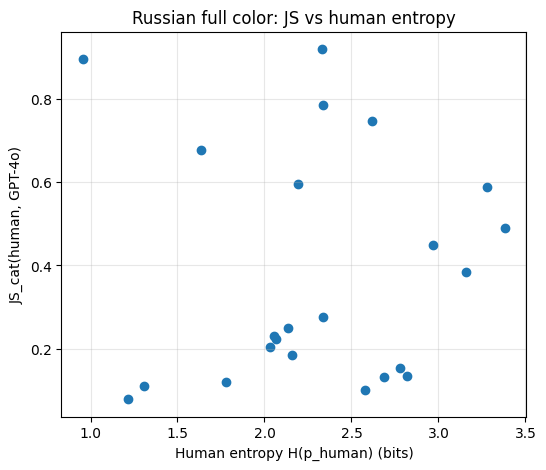

In [ ]:
# ================================================================
# Analysis 1: JS vs human entropy (Russian full color)
# Requires: ru_fullcolor_js_cat, human_ru_dist_raw
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def shannon_entropy(prob_dict, base=2):
    """H(p) for a dict label -> prob."""
    p = np.array(list(prob_dict.values()), dtype=float)
    p = p[p > 0]
    if len(p) == 0:
        return np.nan
    return -np.sum(p * np.log(p)) / np.log(base)

rows_entropy = []
for _, row in ru_fullcolor_js_cat.iterrows():
    b = (row["binL"], row["binA"], row["binB"])
    h_dist = human_ru_dist_raw.get(b, {})
    H = shannon_entropy(h_dist, base=2)
    rows_entropy.append({
        "binL": row["binL"],
        "binA": row["binA"],
        "binB": row["binB"],
        "js_cat": row["js_cat"],
        "human_entropy": H,
        "human_mass": row["human_mass"],
        "llm_samples": row["llm_samples"],
    })

ru_entropy_df = pd.DataFrame(rows_entropy)
display(ru_entropy_df.head())
print(ru_entropy_df[["human_entropy", "js_cat"]].describe())

# Scatter: human entropy vs JS
plt.figure(figsize=(6,5))
plt.scatter(ru_entropy_df["human_entropy"], ru_entropy_df["js_cat"])
plt.xlabel("Human entropy H(p_human) (bits)")
plt.ylabel("JS_cat(human, GPT-4o)")
plt.title("Russian full color: JS vs human entropy")
plt.grid(True, alpha=0.3)
plt.show()


Common bins with full data: 23
Example bins: [(4, 0, 1), (9, -1, 2), (5, 2, -1), (5, 2, 1), (5, -1, 0)]

=== Vocabulary Compression (all common bins) ===


,binL,binA,binB,js_cat,human_vocab,llm_vocab,vocab_ratio
count,23.000000,23.00000,23.000000,23.000000,23.000000,23.000000,23.000000
mean,6.652174,0.26087,-0.086957,0.379125,14.217391,1.869565,0.139269
std,1.873468,1.17618,1.239980,0.276225,3.777403,0.919701,0.075185
min,2.000000,-2.00000,-2.000000,0.078799,5.000000,1.000000,0.050000
25%,5.500000,-1.00000,-1.000000,0.144308,11.500000,1.000000,0.071429
50%,7.000000,0.00000,0.000000,0.249614,14.000000,2.000000,0.133333
75%,8.000000,1.00000,1.000000,0.591510,16.500000,2.500000,0.181818
max,10.000000,2.00000,2.000000,0.919157,21.000000,4.000000,0.363636



Worst compression cases (lowest vocab_ratio):


,binL,binA,binB,js_cat,human_vocab,llm_vocab,vocab_ratio
9,6,1,-1,0.383765,20,1,0.050000
13,7,-1,-1,0.229339,17,1,0.058824
10,8,0,1,0.587605,16,1,0.062500
0,4,0,1,0.222109,14,1,0.071429
11,9,-1,-1,0.249614,14,1,0.071429
7,8,-1,-1,0.203103,14,1,0.071429
22,7,1,2,0.896277,14,1,0.071429
21,8,2,0,0.109105,11,1,0.090909
15,8,-2,0,0.274892,10,1,0.100000
16,7,0,-1,0.447649,20,2,0.100000



=== Top-1 agreement on common bins ===
Agreement rate: 0.0


,binL,binA,binB,top1_human,top1_llm,match,js_cat
18,10,0,0,бежевый,молочно-белый.,0,0.919157
22,7,1,2,оранжевый,бежевый.,0,0.896277
5,7,1,1,оранжевый,бежевый.,0,0.785785
4,5,-1,0,зеленый,бирюзовый.,0,0.745972
3,5,2,1,красный,терракотовый.,0,0.677910
20,8,1,1,оранжевый,бежевый.,0,0.595415
10,8,0,1,желтый,бежевый.,0,0.587605
17,7,0,1,коричневый,бежевый.,0,0.488521
16,7,0,-1,голубой,сиреневый.,0,0.447649
9,6,1,-1,фиолетовый,сиреневый.,0,0.383765



=== Human entropy + JS summary (full color) ===


,binL,binA,binB,js_cat,human_entropy
count,23.000000,23.00000,23.000000,23.000000,23.000000
mean,6.652174,0.26087,-0.086957,0.379125,2.296062
std,1.873468,1.17618,1.239980,0.276225,0.642827
min,2.000000,-2.00000,-2.000000,0.078799,0.954217
25%,5.500000,-1.00000,-1.000000,0.144308,2.044162
50%,7.000000,0.00000,0.000000,0.249614,2.329958
75%,8.000000,1.00000,1.000000,0.591510,2.733391
max,10.000000,2.00000,2.000000,0.919157,3.384330



Correlation (Pearson) JS vs human entropy:
0.022558910151556807


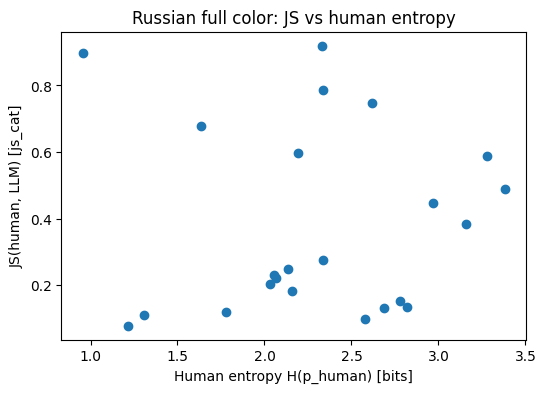


=== JS by Lightness (binL) ===


,js_cat
binL,
2,0.078799
4,0.171293
5,0.519503
6,0.212485
7,0.496605
8,0.354024
9,0.216808
10,0.919157


Merged rows: 23


,binL,binA,binB,js_cat_x,human_vocab,llm_vocab,vocab_ratio,top1_human,top1_llm,match,js_cat_y,js_cat,human_entropy
0,4,0,1,0.222109,14,1,0.071429,коричневый,коричневый.,0,0.222109,0.222109,2.066649
1,9,-1,2,0.184002,13,3,0.230769,желтый,бежевый.,0,0.184002,0.184002,2.156469
2,5,2,-1,0.134627,12,2,0.166667,фиолетовый,фиолетовый.,0,0.134627,0.134627,2.818534
3,5,2,1,0.677910,11,2,0.181818,красный,терракотовый.,0,0.677910,0.677910,1.633270
4,5,-1,0,0.745972,15,2,0.133333,зеленый,бирюзовый.,0,0.745972,0.745972,2.618724



=== Error-type counts ===


...

,binL,binA,binB,js_cat,human_vocab,llm_vocab,vocab_ratio,top1_human,top1_llm,match,human_entropy
20,8,1,1,0.595415,14,3,0.214286,оранжевый,бежевый.,0,2.190693
17,7,0,1,0.488521,21,3,0.142857,коричневый,бежевый.,0,3.384330
16,7,0,-1,0.447649,20,2,0.100000,голубой,сиреневый.,0,2.970413



--- ALIGNED examples ---


,binL,binA,binB,js_cat,human_vocab,llm_vocab,vocab_ratio,top1_human,top1_llm,match,human_entropy
6,2,0,-2,0.078799,5,1,0.200000,темно синий,темно-синий.,0,1.215468
8,6,1,-2,0.099699,11,4,0.363636,фиолетовый,сиреневый.,0,2.579427
21,8,2,0,0.109105,11,1,0.090909,розовый,розовый.,0,1.305012
12,4,1,-2,0.120476,11,2,0.181818,фиолетовый,синий.,0,1.781099
14,7,-1,1,0.132060,18,3,0.166667,зеленый,мятный.,0,2.685165



--- MIXED examples ---


,binL,binA,binB,js_cat,human_vocab,llm_vocab,vocab_ratio,top1_human,top1_llm,match,human_entropy
9,6,1,-1,0.383765,20,1,0.05,фиолетовый,сиреневый.,0,3.158693


In [ ]:
# ============================================================
# EXTENDED ANALYSIS — ROBUST VERSION (NO INDEX ERRORS)
# ============================================================

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Setup: use the ACTUAL JS table and distributions
# ------------------------------------------------------------
js_col = "js_cat"                      # column name in ru_fullcolor_js_cat
ru_ext = ru_fullcolor_js_cat.copy()   # JS + metadata per (binL, binA, binB)

# Use the raw human/LLM distributions we built above
human_ru_dist = human_ru_dist_raw
llm_ru_dist   = llm_ru_dist_raw

# Bins appearing in the JS table
ru_bins = {
    (L, A, B)
    for L, A, B in ru_ext[["binL", "binA", "binB"]].itertuples(index=False, name=None)
}

# intersect with bins where we have human + LLM distributions
common_bins = [
    b for b in ru_bins
    if (b in human_ru_dist) and (b in llm_ru_dist)
]

print(f"Common bins with full data: {len(common_bins)}")
print("Example bins:", common_bins[:5])


# ============================================================
# 1. Vocabulary Compression
# ============================================================
def build_vocab_df(common_bins, ru_ext, human_ru_dist, llm_ru_dist, js_col):
    rows = []
    for (L, A, B) in common_bins:

        # JS extraction — guaranteed to exist for these bins
        mask = (
            (ru_ext["binL"] == L) &
            (ru_ext["binA"] == A) &
            (ru_ext["binB"] == B)
        )
        js_vals = ru_ext.loc[mask, js_col].values
        if len(js_vals) == 0:
            continue
        js_val = js_vals[0]

        # distributions
        h_dist = human_ru_dist[(L, A, B)]
        m_dist = llm_ru_dist[(L, A, B)]

        h_vocab = len(h_dist)
        m_vocab = len(m_dist)
        if h_vocab == 0:
            continue

        rows.append({
            "binL": L,
            "binA": A,
            "binB": B,
            js_col: js_val,
            "human_vocab": h_vocab,
            "llm_vocab": m_vocab,
            "vocab_ratio": m_vocab / h_vocab
        })
    return pd.DataFrame(rows)


vocab_df = build_vocab_df(common_bins, ru_ext, human_ru_dist, llm_ru_dist, js_col)

print("\n=== Vocabulary Compression (all common bins) ===")
display(vocab_df.describe())

print("\nWorst compression cases (lowest vocab_ratio):")
display(vocab_df.sort_values("vocab_ratio").head(10))


# ============================================================
# 2. Top-1 agreement
# ============================================================
def top1(d):
    if not d:
        return None
    return max(d.items(), key=lambda kv: kv[1])[0]


top1_rows = []
for (L, A, B) in common_bins:

    h_dist = human_ru_dist[(L, A, B)]
    m_dist = llm_ru_dist[(L, A, B)]

    h_label = top1(h_dist)
    m_label = top1(m_dist)

    mask = (
        (ru_ext["binL"] == L) &
        (ru_ext["binA"] == A) &
        (ru_ext["binB"] == B)
    )
    js_vals = ru_ext.loc[mask, js_col].values
    if len(js_vals) == 0:
        continue
    js_val = js_vals[0]

    top1_rows.append({
        "binL": L,
        "binA": A,
        "binB": B,
        "top1_human": h_label,
        "top1_llm": m_label,
        "match": int(h_label == m_label),
        js_col: js_val,
    })

top1_df = pd.DataFrame(top1_rows)

print("\n=== Top-1 agreement on common bins ===")
print("Agreement rate:", top1_df["match"].mean())
display(top1_df.sort_values(js_col, ascending=False).head(10))


# ============================================================
# 3. Human entropy vs JS (full color)
# ============================================================
def dist_entropy(d):
    if not d:
        return np.nan
    p = np.array(list(d.values()), dtype=float)
    p = p / (p.sum() + 1e-12)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))


ent_rows = []
for (L, A, B) in common_bins:

    h_dist = human_ru_dist[(L, A, B)]
    H = dist_entropy(h_dist)

    mask = (
        (ru_ext["binL"] == L) &
        (ru_ext["binA"] == A) &
        (ru_ext["binB"] == B)
    )
    js_vals = ru_ext.loc[mask, js_col].values
    if len(js_vals) == 0:
        continue
    js_val = js_vals[0]

    ent_rows.append({
        "binL": L,
        "binA": A,
        "binB": B,
        js_col: js_val,
        "human_entropy": H,
    })

ent_df = pd.DataFrame(ent_rows)

print("\n=== Human entropy + JS summary (full color) ===")
display(ent_df.describe())

print("\nCorrelation (Pearson) JS vs human entropy:")
print(ent_df[js_col].corr(ent_df["human_entropy"]))

# scatter
plt.figure(figsize=(6,4))
plt.scatter(ent_df["human_entropy"], ent_df[js_col])
plt.xlabel("Human entropy H(p_human) [bits]")
plt.ylabel(f"JS(human, LLM) [{js_col}]")
plt.title("Russian full color: JS vs human entropy")
plt.show()


# ============================================================
# 4. JS by lightness + automatic error tagging
# ============================================================

print("\n=== JS by Lightness (binL) ===")
display(ent_df.groupby("binL")[js_col].mean())

# Merge all pieces for error typing
# (merge only on binL, binA, binB)
vocab_df2 = vocab_df.copy()
top1_df2  = top1_df.copy()
ent_df2   = ent_df.copy()

# Just in case, drop any duplicate JS columns
for df in [vocab_df2, top1_df2, ent_df2]:
    for col in ["js_ru_x", "js_ru_y", "js_cat_x", "js_cat_y"]:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

merged = (
    vocab_df2
    .merge(top1_df2, on=["binL","binA","binB"], how="inner")
    .merge(ent_df2,  on=["binL","binA","binB"], how="inner")
)

print("Merged rows:", len(merged))
display(merged.head())


def classify(row):
    js = row[js_col]
    ratio = row["vocab_ratio"]
    match = row["match"]

    if js > 0.9:
        return "extreme_divergence"
    if ratio < 0.20 and js > 0.5:
        return "collapse"
    if match == 0 and js > 0.4:
        return "shift"
    if js < 0.3:
        return "aligned"
    return "mixed"

merged["error_type"] = merged.apply(classify, axis=1)

print("\n=== Error-type counts ===")
display(merged["error_type"].value_counts())

for etype in ["extreme_divergence", "collapse", "shift", "aligned", "mixed"]:
    print(f"\n--- {etype.upper()} examples ---")
    subset = merged[merged["error_type"] == etype]
    if subset.empty:
        continue
    display(
        subset
        .sort_values(js_col, ascending=(etype=="aligned"))
        .head(5)[[
            "binL","binA","binB",
            js_col,
            "human_vocab","llm_vocab","vocab_ratio",
            "top1_human","top1_llm","match",
            "human_entropy"
        ]]
    )


In [ ]:
print("Full RU mean JS_cat:", ru_fullcolor_js_cat["js_cat"].mean())
print("Top-1 agreement:", top1_df["match"].mean())
print("Median vocab_ratio:", vocab_df["vocab_ratio"].median())
print(merged["error_type"].value_counts(normalize=True))


Full RU mean JS_cat: 0.37912487168746983
Top-1 agreement: 0.0
Median vocab_ratio: 0.13333333333333333
error_type
aligned               0.565217
collapse              0.217391
shift                 0.130435
mixed                 0.043478
extreme_divergence    0.043478
Name: proportion, dtype: float64


RU human rows: 1848
RU human bins with data: 145
RU bins with RGB info: 0
Found existing /content/drive/MyDrive/2025_2026/color/color_repo/russian-cielab-llm.csv, skipping GPT queries.
RU LLM bins with data: 832
RU bins after filtering: 23

=== RU full-grid summary ===
Mean JS_cat: 0.37912487168746983
Top-1 agreement: 0.0
Median vocab_ratio: 0.13333333333333333
Error-type proportions:
error_type
aligned               0.565217
collapse              0.217391
shift                 0.130435
extreme_divergence    0.043478
mixed                 0.043478
Name: proportion, dtype: float64


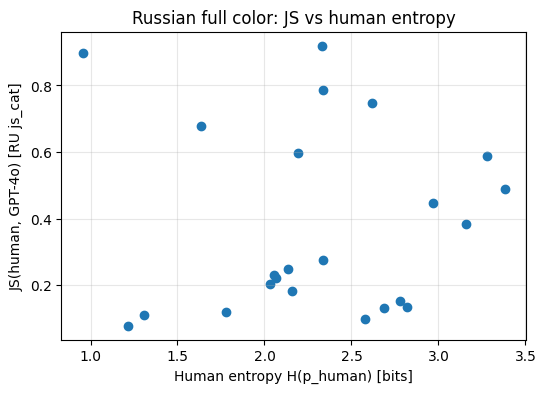

EN human rows: 145709
EN human bins with data: 1267
EN candidate bins: 1267
EN bins selected for GPT queries: 200
EN full-grid LLM queries:


100%|██████████| 200/200 [37:19<00:00, 11.20s/it]


Wrote /content/drive/MyDrive/2025_2026/color/color_repo/english-cielab-llm2.csv rows: 1000
EN LLM bins with data: 200
EN bins after filtering: 200

=== EN full-grid summary ===
Mean JS_cat: 0.22241963007769563
Top-1 agreement: 0.34
Median vocab_ratio: 0.058823529411764705
Error-type proportions:
error_type
aligned     0.680
mixed       0.145
shift       0.095
collapse    0.080
Name: proportion, dtype: float64


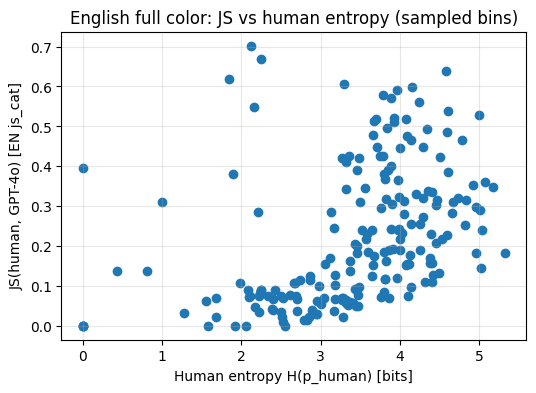

In [ ]:
# ================================================================
# EXPERIMENT D — Full CIELAB grid vs GPT-4o (Russian + English)
# ================================================================
#
# Goal:
#   Compare GPT-4o vs human color naming on a dense CIELAB grid,
#   in Russian and English, using:
#     - category-level JS divergence,
#     - vocabulary compression (vocab_ratio),
#     - top-1 agreement,
#     - error typing (aligned / collapse / shift / extreme / mixed).
#
# Design:
#   1. Build human naming distributions per (binL, binA, binB).
#   2. Convert LAB -> RGB if needed, so we can show GPT-4o color patches.
#   3. Query GPT-4o on each bin (or a subsample for English).
#   4. Build model distributions per bin.
#   5. Collapse labels into coarse color categories.
#   6. Compute JS, vocab_ratio, top-1 match, entropy, error types.
#
# Notes:
#   - Russian: evaluate the full blurred/binned grid.
#   - English: subsample a fixed number of bins (cost control),
#              but use the same pipeline.
#   - JS is computed over category-collapsed distributions.
#   - Human-mass and LLM-sample thresholds filter out unstable bins.
# ================================================================

import os, io, base64, math
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from openai import OpenAI
from skimage.color import lab2rgb   # LAB -> RGB

# ---------- Paths and config ----------
ROOT = "/content/drive/MyDrive/2025_2026/color"

# Russian human full-grid (binned + blurred in UW pipeline)
HUMAN_RU_FULL = f"{ROOT}/color_repo/russian_full_color_names_binned_blur_0.1.csv"
LLM_RU_FULL   = f"{ROOT}/color_repo/russian-cielab-llm.csv"    # will be (re)written


# English human full dataset (raw UW format; we bin ourselves)
HUMAN_EN_FULL = f"{ROOT}/uw-data/extracted_langs/english/cleaned_full_data.csv"
LLM_EN_FULL   = f"{ROOT}/color_repo/english-cielab-llm2.csv"    # will be (re)written



MODEL = "gpt-4o"
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

# Sampling parameters
RU_SAMPLES_PER_BIN = 5     # GPT samples per Russian bin
EN_SAMPLES_PER_BIN = 5     # GPT samples per English bin
EN_MAX_BINS        = 200   # max English bins to query (subsample)

# Filtering thresholds for analysis
MIN_HUMAN_MASS   = 0.5     # min human mass per bin
MIN_LLM_SAMPLES  = 3       # default min GPT samples per bin (used for RU)


# ================================================================
# Shared helpers
# ================================================================

def rgb_to_data_url(r, g, b, size=96):
    """
    Render a solid RGB square and encode it as a data URL (PNG).
    This is what we give to GPT-4o as the input_image.
    """
    img = Image.new("RGB", (size, size), (int(r), int(g), int(b)))
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    buf.seek(0)
    b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
    return f"data:image/png;base64,{b64}"


def build_prompt(lang: str) -> str:
    """Simple free-form naming prompt in a given language."""
    if lang == "ru":
        return (
            "Вы видите квадрат, залитый одним цветом.\n"
            "Дайте естественное русское название этого цвета.\n"
            "Ответьте одним словом или очень короткой фразой."
        )
    elif lang == "en":
        return (
            "You see a square filled with a single color.\n"
            "Give a natural English name for this color.\n"
            "Answer with one word or a very short phrase."
        )
    else:
        raise ValueError(f"Unsupported language: {lang}")


def normalize_ru_name(s: str) -> str:
    """Whitespace + case normalization for Russian outputs."""
    s = str(s).strip().lower()
    s = " ".join(s.split())
    return s.replace("ё", "е")


def normalize_en_name(s: str) -> str:
    """Whitespace + case normalization for English outputs."""
    s = str(s).strip().lower()
    return " ".join(s.split())


def jensen_shannon_dict(p_dict, q_dict, base=2):
    """
    Jensen–Shannon divergence between two dict distributions p_dict, q_dict.
    Keys are unioned; missing keys treated as zero.
    """
    keys = set(p_dict.keys()) | set(q_dict.keys())
    if not keys:
        return np.nan
    p = np.array([p_dict.get(k, 0.0) for k in keys], dtype=float)
    q = np.array([q_dict.get(k, 0.0) for k in keys], dtype=float)
    p_sum, q_sum = p.sum(), q.sum()
    if p_sum <= 0 or q_sum <= 0:
        return np.nan
    p /= p_sum
    q /= q_sum
    m = 0.5 * (p + q)

    def _kl(a, b):
        mask = (a > 0) & (b > 0)
        if not np.any(mask):
            return 0.0
        a = a[mask]
        b = b[mask]
        return np.sum(a * (np.log(a / b) / np.log(base)))

    return 0.5 * _kl(p, m) + 0.5 * _kl(q, m)


def dist_entropy(d):
    """Shannon entropy (bits) of a dict distribution."""
    if not d:
        return np.nan
    p = np.array(list(d.values()), dtype=float)
    p = p / (p.sum() + 1e-12)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))


def top1(d):
    """Return most probable label in a dict distribution, or None."""
    if not d:
        return None
    return max(d.items(), key=lambda kv: kv[1])[0]


# ================================================================
# Category mappers (English + Russian)
# ================================================================

RU_CATEGORY_PATTERNS = [
    ("красный",   ["красн"]),
    ("оранжевый", ["оранж"]),
    ("жёлтый",    ["жёлт", "желт"]),
    ("зелёный",   ["зелён", "зелен"]),
    ("синий",     ["син"]),
    ("голубой",   ["голуб"]),
    ("фиолетовый",["фиолет", "лаванд", "лилов"]),
    ("розовый",   ["розов"]),
    ("коричневый",["коричнев"]),
    ("серый",     ["сер"]),
    ("чёрный",    ["чёрн", "черн"]),
    ("белый",     ["бел"]),
]

EN_CATEGORY_PATTERNS = [
    ("red",   ["red"]),
    ("orange",["orange"]),
    ("yellow",["yellow"]),
    ("green", ["green"]),
    ("blue",  ["blue"]),
    ("purple",["purple", "violet"]),
    ("pink",  ["pink"]),
    ("brown", ["brown"]),
    ("gray",  ["gray", "grey"]),
    ("black", ["black"]),
    ("white", ["white"]),
]

def ru_label_to_category(label: str) -> str:
    """Map a Russian surface label to a coarse color category."""
    s = str(label).lower().strip()
    s = " ".join(s.split())
    s = s.replace("ё", "е")
    for cat, pats in RU_CATEGORY_PATTERNS:
        for p in pats:
            if p in s:
                return cat
    return "other"


def en_label_to_category(label: str) -> str:
    """Map an English surface label to a coarse color category."""
    s = str(label).lower().strip()
    s = " ".join(s.split())
    for cat, pats in EN_CATEGORY_PATTERNS:
        for p in pats:
            if p in s:
                return cat
    return "other"


def collapse_to_categories(prob_dict, mapper):
    """
    Map fine-grained labels to coarse categories and renormalize.
    Input:  prob_dict[label] = p
    Output: cat_dict[category] = p (sums to 1).
    """
    acc = Counter()
    for lab, p in prob_dict.items():
        cat = mapper(lab)
        acc[cat] += float(p)
    tot = sum(acc.values())
    if tot <= 0:
        return {}
    return {k: v / tot for k, v in acc.items()}


# ================================================================
# LAB -> RGB helper
# ================================================================

def ensure_rgb_from_lab(df: pd.DataFrame,
                        l_col="lab_l",
                        a_col="lab_a",
                        b_col="lab_b") -> pd.DataFrame:
    """
    Ensure that the dataframe has integer r,g,b columns if possible.

    Cases:
      - If r,g,b already exist: return df unchanged.
      - Else if LAB columns exist: derive r,g,b via lab2rgb.
      - Else: print a warning and return df unchanged (no RGB available).
    """
    # Already have RGB
    if {"r", "g", "b"}.issubset(df.columns):
        return df

    # Can derive RGB from LAB
    if {l_col, a_col, b_col}.issubset(df.columns):
        lab = df[[l_col, a_col, b_col]].to_numpy()
        lab_img = lab.reshape(-1, 1, 3)
        rgb_01 = lab2rgb(lab_img).reshape(-1, 3)  # [0,1]
        df = df.copy()
        df["r"] = (rgb_01[:, 0] * 255).round().astype(int)
        df["g"] = (rgb_01[:, 1] * 255).round().astype(int)
        df["b"] = (rgb_01[:, 2] * 255).round().astype(int)
        return df

    # No RGB and no LAB → cannot reconstruct color, but we don't crash.
    print("Warning: no RGB or LAB columns found; continuing without RGB.")
    return df


# ================================================================#
# Human distributions
# ================================================================

def build_human_bins_ru(path: str):
    """
    Russian full-grid human distributions.

    Expected at minimum:
      - binL, binA, binB
      - pTC
      - commonTerm

    If LAB or RGB columns exist, we also compute a representative (r,g,b)
    per bin for potential LLM queries. If not, bin_rgb will be empty.
    """
    df = pd.read_csv(path)
    print("RU human rows:", len(df))

    # Try to add RGB if possible (but tolerate failure)
    df = ensure_rgb_from_lab(df, l_col="lab_l", a_col="lab_a", b_col="lab_b")

    # Normalize Russian labels
    df["commonTerm"] = (
        df["commonTerm"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace("ё", "е")
    )

    bin_groups = df.groupby(["binL", "binA", "binB"])
    bin_pTC_sum = bin_groups["pTC"].sum()

    human_dist = {}
    bin_rgb    = {}  # may stay empty if we have no RGB columns

    for (L, A, B), sub in bin_groups:
        probs = sub.groupby("commonTerm")["pTC"].sum()
        total = probs.sum()
        if total <= 0:
            continue
        human_dist[(L, A, B)] = (probs / total).to_dict()

        # Only compute representative RGB if r,g,b exist
        if {"r", "g", "b"}.issubset(sub.columns):
            r = int(round(sub["r"].mean()))
            g = int(round(sub["g"].mean()))
            b = int(round(sub["b"].mean()))
            bin_rgb[(L, A, B)] = (r, g, b)

    print("RU human bins with data:", len(human_dist))
    print("RU bins with RGB info:", len(bin_rgb))
    return human_dist, bin_pTC_sum, bin_rgb


def build_human_bins_en(path: str):
    """
    English full dataset -> binned human distributions.
    - If binL/binA/binB are missing, compute them from lab_l/lab_a/lab_b.
    - If r,g,b are missing, derive them from LAB.
    Weighting:
      - if pTC present: use pTC as weight;
      - else: use simple counts.
    Returns:
      human_dist[(binL,binA,binB)] = dict(label -> p),
      bin_mass (Series of total mass per bin),
      bin_rgb[(binL,binA,binB)] = (r,g,b).
    """
    df = pd.read_csv(path)
    print("EN human rows:", len(df))

    # Ensure bins exist
    if not {"binL", "binA", "binB"}.issubset(df.columns):
        if not {"lab_l", "lab_a", "lab_b"}.issubset(df.columns):
            raise ValueError("Need binL/binA/binB or lab_l/lab_a/lab_b in EN file.")
        df["binL"] = (df["lab_l"] / 10).round().astype(int)
        df["binA"] = (df["lab_a"] / 10).round().astype(int)
        df["binB"] = (df["lab_b"] / 10).round().astype(int)

    # Ensure we have RGB (for the bins → GPT step)
    if {"lab_l", "lab_a", "lab_b"}.issubset(df.columns):
        df = ensure_rgb_from_lab(df, l_col="lab_l", a_col="lab_a", b_col="lab_b")

    # Label column name: commonTerm if present, else standardized_entered_name
    term_col = "commonTerm" if "commonTerm" in df.columns else "standardized_entered_name"
    df[term_col] = df[term_col].astype(str).str.strip().str.lower()

    has_pTC = "pTC" in df.columns

    bin_groups = df.groupby(["binL", "binA", "binB"])
    if has_pTC:
        bin_mass = bin_groups["pTC"].sum()
    else:
        bin_mass = bin_groups[term_col].size()

    human_dist = {}
    bin_rgb    = {}

    for (L, A, B), sub in bin_groups:
        if has_pTC:
            probs = sub.groupby(term_col)["pTC"].sum()
        else:
            probs = sub.groupby(term_col)[term_col].size()
        total = probs.sum()
        if total <= 0:
            continue
        human_dist[(L, A, B)] = (probs / total).to_dict()

        # Representative RGB per bin, now guaranteed to exist
        r = int(round(sub["r"].mean()))
        g = int(round(sub["g"].mean()))
        b = int(round(sub["b"].mean()))
        bin_rgb[(L, A, B)] = (r, g, b)

    print("EN human bins with data:", len(human_dist))
    return human_dist, bin_mass, bin_rgb


# ================================================================
# GPT-4o queries for full grid
# ================================================================

def query_llm_fullgrid(lang: str,
                       bin_rgb: dict,
                       bins_to_query,
                       samples_per_bin: int,
                       out_path: str):
    """
    Query GPT-4o on each (binL,binA,binB) in bins_to_query.
    For each bin:
      - look up its representative (r,g,b),
      - build an image data URL,
      - show it to GPT-4o with a language-specific prompt,
      - collect 'samples_per_bin' names.
    Writes a CSV: one row per GPT sample.
    """
    if os.path.exists(out_path):
        print(f"Found existing {out_path}, skipping GPT queries.")
        return pd.read_csv(out_path)

    rows = []
    prompt = build_prompt(lang)

    print(f"{lang.upper()} full-grid LLM queries:")
    for (L, A, B) in tqdm(bins_to_query, total=len(bins_to_query)):
        if (L, A, B) not in bin_rgb:
            # Should not happen if we built bin_rgb correctly,
            # but we skip just in case.
            continue
        r, g, b = bin_rgb[(L, A, B)]
        img_url = rgb_to_data_url(r, g, b)

        for _ in range(samples_per_bin):
            resp = client.responses.create(
                model=MODEL,
                input=[{
                    "role": "user",
                    "content": [
                        {"type": "input_image", "image_url": img_url},
                        {"type": "input_text",  "text": prompt},
                    ],
                }],
                max_output_tokens=32,
                temperature=0.7,
            )

            out = resp.output[0].content
            text_pieces = [c.text for c in out if getattr(c, "type", None) == "output_text"]
            raw = text_pieces[0] if text_pieces else ""

            if lang == "ru":
                name = normalize_ru_name(raw)
            else:
                name = normalize_en_name(raw)

            rows.append({
                "binL": L,
                "binA": A,
                "binB": B,
                "r": r,
                "g": g,
                "b": b,
                "name": name,
            })

    df_llm = pd.DataFrame(rows)
    df_llm.to_csv(out_path, index=False)
    print("Wrote", out_path, "rows:", len(df_llm))
    return df_llm


def build_llm_dist(df_llm: pd.DataFrame, lang: str):
    """
    Convert flat LLM sample table into distributions per bin:
      llm_dist[(binL,binA,binB)] = dict(name -> p).
    Also return llm_counts (Series of #samples per bin).
    """
    df = df_llm.copy()
    if lang == "ru":
        df["name"] = (
            df["name"].astype(str).str.strip().str.lower().str.replace("ё", "е")
        )
    else:
        df["name"] = df["name"].astype(str).str.strip().str.lower()

    groups = df.groupby(["binL", "binA", "binB"])
    dist   = {}
    counts = groups["name"].size()

    for (L, A, B), sub in groups:
        c = sub["name"].value_counts()
        total = c.sum()
        if total <= 0:
            continue
        dist[(L, A, B)] = (c / total).to_dict()

    print(f"{lang.upper()} LLM bins with data:", len(dist))
    return dist, counts


# ================================================================
# Main analysis: JS, vocab_ratio, top-1, entropy, error typing
# ================================================================

def compute_fullgrid_metrics(
    lang: str,
    human_dist: dict,
    human_mass,
    llm_dist: dict,
    llm_counts,
    label_to_category_fn,
    min_human_mass: float,
    min_llm_samples: int,
):
    """
    Combine human + model full-grid distributions and compute:
      - js_cat per bin (category JS),
      - vocab_ratio per bin,
      - top-1 match,
      - human_entropy,
      - error_type labels.

    Inputs:
      human_dist[(L,A,B)] = dict(human label -> p)
      human_mass[(L,A,B)] = total human mass in that bin
      llm_dist[(L,A,B)]   = dict(LLM label -> p)
      llm_counts[(L,A,B)] = # LLM samples for that bin
    """
    human_bins = set(human_dist.keys())
    llm_bins   = set(llm_dist.keys())
    shared     = human_bins & llm_bins

    # Filter by human mass and GPT sample count
    filtered_bins = []
    for b in shared:
        if human_mass.loc[b] >= min_human_mass and llm_counts.loc[b] >= min_llm_samples:
            filtered_bins.append(b)
    print(f"{lang.upper()} bins after filtering:", len(filtered_bins))

    rows = []
    for (L, A, B) in filtered_bins:
        hp_raw = human_dist[(L, A, B)]
        lp_raw = llm_dist[(L, A, B)]

        hp_cat = collapse_to_categories(hp_raw, label_to_category_fn)
        lp_cat = collapse_to_categories(lp_raw, label_to_category_fn)

        js_cat = jensen_shannon_dict(hp_cat, lp_cat)

        rows.append({
            "binL": L,
            "binA": A,
            "binB": B,
            "human_probs": hp_raw,
            "model_probs": lp_raw,
            "human_cat": hp_cat,
            "model_cat": lp_cat,
            "js_cat": js_cat,
            "human_mass": float(human_mass.loc[(L, A, B)]),
            "llm_samples": int(llm_counts.loc[(L, A, B)]),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        print(f"No bins survived filtering for {lang}.")
        return None, None   # EDIT: return None instead of empty df

    # vocab_ratio: |model types| / |human types|
    vocab_rows = []
    for _, row in df.iterrows():
        hp = row["human_probs"]
        mp = row["model_probs"]
        h_vocab = len(hp)
        m_vocab = len(mp)
        vocab_rows.append({
            "binL": row["binL"],
            "binA": row["binA"],
            "binB": row["binB"],
            "vocab_ratio": m_vocab / max(1, h_vocab),
        })
    vocab_df = pd.DataFrame(vocab_rows)

    # top-1 match
    top1_rows = []
    for _, row in df.iterrows():
        hp = row["human_probs"]
        mp = row["model_probs"]
        h_top = top1(hp)
        m_top = top1(mp)
        top1_rows.append({
            "binL": row["binL"],
            "binA": row["binA"],
            "binB": row["binB"],
            "top1_human": h_top,
            "top1_llm": m_top,
            "match": int(h_top == m_top),
        })
    top1_df = pd.DataFrame(top1_rows)

    # human entropy
    ent_rows = []
    for _, row in df.iterrows():
        hp = row["human_probs"]
        ent_rows.append({
            "binL": row["binL"],
            "binA": row["binA"],
            "binB": row["binB"],
            "human_entropy": dist_entropy(hp),
        })
    ent_df = pd.DataFrame(ent_rows)

    # merge everything
    merged = (
        df.merge(vocab_df, on=["binL", "binA", "binB"])
          .merge(top1_df, on=["binL", "binA", "binB"])
          .merge(ent_df,  on=["binL", "binA", "binB"])
    )

    # error typing heuristic
    def classify(row):
        js = row["js_cat"]
        ratio = row["vocab_ratio"]
        match = row["match"]

        if js > 0.9:
            return "extreme_divergence"
        if ratio < 0.20 and js > 0.5:
            return "collapse"
        if match == 0 and js > 0.4:
            return "shift"
        if js < 0.3:
            return "aligned"
        return "mixed"

    merged["error_type"] = merged.apply(classify, axis=1)

    print(f"\n=== {lang.upper()} full-grid summary ===")
    print("Mean JS_cat:", merged["js_cat"].mean())
    print("Top-1 agreement:", merged["match"].mean())
    print("Median vocab_ratio:", merged["vocab_ratio"].median())
    print("Error-type proportions:")
    print(merged["error_type"].value_counts(normalize=True))

    return merged, df


# ================================================================
# RUN: Russian full CIELAB grid
# ================================================================

# 1) Human RU distributions + RGB per bin
human_ru_dist_raw, human_ru_mass, ru_bin_rgb = build_human_bins_ru(HUMAN_RU_FULL)

# 2) Bins to query (based on human mass)
ru_bins_to_query = [b for b in human_ru_dist_raw.keys()
                    if human_ru_mass.loc[b] >= MIN_HUMAN_MASS]

# 3) Query GPT-4o for Russian
df_ru_llm = query_llm_fullgrid(
    lang="ru",
    bin_rgb=ru_bin_rgb,
    bins_to_query=ru_bins_to_query,
    samples_per_bin=RU_SAMPLES_PER_BIN,
    out_path=LLM_RU_FULL,
)

# 4) Build RU LLM distributions
llm_ru_dist_raw, llm_ru_counts = build_llm_dist(df_ru_llm, lang="ru")

# 5) Compute RU metrics
ru_merged, ru_core = compute_fullgrid_metrics(
    lang="ru",
    human_dist=human_ru_dist_raw,
    human_mass=human_ru_mass,
    llm_dist=llm_ru_dist_raw,
    llm_counts=llm_ru_counts,
    label_to_category_fn=ru_label_to_category,
    min_human_mass=MIN_HUMAN_MASS,
    min_llm_samples=MIN_LLM_SAMPLES,   # keep 3 for RU
)

# Optional: RU JS vs human entropy plot
if ru_merged is not None and not ru_merged.empty:
    plt.figure(figsize=(6,4))
    plt.scatter(ru_merged["human_entropy"], ru_merged["js_cat"])
    plt.xlabel("Human entropy H(p_human) [bits]")
    plt.ylabel("JS(human, GPT-4o) [RU js_cat]")
    plt.title("Russian full color: JS vs human entropy")
    plt.grid(True, alpha=0.3)
    plt.show()


# ================================================================
# RUN: English full CIELAB grid (subsampled)
# ================================================================

# 1) Human EN distributions + RGB per bin
human_en_dist_raw, human_en_mass, en_bin_rgb = build_human_bins_en(HUMAN_EN_FULL)

# 2) Candidate English bins: enough human mass
candidate_en_bins = [b for b in human_en_dist_raw.keys()
                     if human_en_mass.loc[b] >= MIN_HUMAN_MASS]

print("EN candidate bins:", len(candidate_en_bins))

# Subsample up to EN_MAX_BINS
rng = np.random.RandomState(42)
if len(candidate_en_bins) <= EN_MAX_BINS:
    en_bins_to_query = list(candidate_en_bins)
else:
    idxs = rng.choice(len(candidate_en_bins), size=EN_MAX_BINS, replace=False)
    en_bins_to_query = [candidate_en_bins[i] for i in idxs]

print("EN bins selected for GPT queries:", len(en_bins_to_query))

# 3) Query GPT-4o for English
df_en_llm = query_llm_fullgrid(
    lang="en",
    bin_rgb=en_bin_rgb,
    bins_to_query=en_bins_to_query,
    samples_per_bin=EN_SAMPLES_PER_BIN,
    out_path=LLM_EN_FULL,
)

# 4) Build EN LLM distributions
llm_en_dist_raw, llm_en_counts = build_llm_dist(df_en_llm, lang="en")

# 5) Compute EN metrics
#    Use a relaxed min_llm_samples=1 so older 1-sample-per-bin files are usable.
en_merged, en_core = compute_fullgrid_metrics(
    lang="en",
    human_dist=human_en_dist_raw,
    human_mass=human_en_mass,
    llm_dist=llm_en_dist_raw,
    llm_counts=llm_en_counts,
    label_to_category_fn=en_label_to_category,
    min_human_mass=MIN_HUMAN_MASS,
    min_llm_samples=MIN_LLM_SAMPLES,   # use 3 for EN as well
)





# Optional: EN JS vs human entropy plot
if en_merged is not None and not en_merged.empty:
    plt.figure(figsize=(6,4))
    plt.scatter(en_merged["human_entropy"], en_merged["js_cat"])
    plt.xlabel("Human entropy H(p_human) [bits]")
    plt.ylabel("JS(human, GPT-4o) [EN js_cat]")
    plt.title("English full color: JS vs human entropy (sampled bins)")
    plt.grid(True, alpha=0.3)
    plt.show()


In [ ]:
import os
import re
import unicodedata
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
from pandas.errors import EmptyDataError
from openai import OpenAI
from io import BytesIO
from PIL import Image
import base64

# ---------------------------------------------------------------------
# Paths & client
# ---------------------------------------------------------------------

BASE = Path("/content/drive/MyDrive/2025_2026/color/uw-data/extracted_langs")
client = OpenAI()

# ---------------------------------------------------------------------
# Global defaults for filtering (per-language overrides below)
# ---------------------------------------------------------------------

GLOBAL_MIN_COUNT = 8      # default minimum # human annotations in a bin
GLOBAL_MIN_PROP  = 0.20   # default minimum dominant head-label proportion
MAX_BINS_DEFAULT = 200    # cap per language

# ---------------------------------------------------------------------
# Seed language-specific generic modifiers (very light / dark / etc.)
#   These get AUGMENTED by auto-derived modifiers from human vocab.
# ---------------------------------------------------------------------

LANG_GENERIC_MODIFIERS_SEED = {
    "english":    ["light", "dark", "pale", "bright", "deep", "medium", "very", "neon"],
    "spanish":    ["claro", "oscuro", "muy", "pálido", "palido"],
    "portuguese": ["claro", "escuro", "muito", "pálido", "palido"],
    "french":     ["clair", "foncé", "fonce", "très", "tres", "pâle", "pale"],
    "german":     ["hell", "dunkel", "sehr"],
    "italian":    ["chiaro", "scuro", "molto"],
    # defensive variants in case folder names are weird
    "portugese":  ["claro", "escuro", "muito"],
    "spanisch":   ["claro", "oscuro", "muy"],
    # CJK: we keep modifiers empty; head norm will handle 色/색 and base chars
    "chinese":    [],
    "korean":     [],
}

# will be filled per-language at runtime
LANG_GENERIC_MODIFIERS = {}

# core Chinese color characters for head-level collapsing
CH_BASE_CHARS = list("红綠绿蓝藍黄黑白灰紫粉橙青棕褐")

# rough Russian color stems → canonical heads
RU_BASES = {
    "син": "синий",
    "голуб": "голубой",
    "бирюз": "бирюзовый",
    "зел": "зелёный",
    "зелен": "зелёный",
    "красн": "красный",
    "оранж": "оранжевый",
    "желт": "жёлтый",
    "жёлт": "жёлтый",
    "роз": "розовый",
    "фиол": "фиолетовый",
    "лилов": "фиолетовый",
    "сер": "серый",
    "коричнев": "коричневый",
    "черн": "чёрный",
    "бел": "белый",
}

# ---------------------------------------------------------------------
# Per-language filtering thresholds
# ---------------------------------------------------------------------

def language_specific_thresholds(lang: str):
    """Return (min_count, min_prop, max_bins) for this language."""
    key = lang.lower()

    # Russian and Polish: lexically very diffuse, so relax a lot
    if key in {"russian", "ru", "русский", "polish", "pl", "polski"}:
        return 5, 0.10, MAX_BINS_DEFAULT

    # CJK: a bit more forgiving than defaults
    if key in {"chinese", "zh", "zhongwen", "korean", "ko", "hangul"}:
        return 6, 0.15, MAX_BINS_DEFAULT

    # others: defaults
    return GLOBAL_MIN_COUNT, GLOBAL_MIN_PROP, MAX_BINS_DEFAULT

# ---------------------------------------------------------------------
# Helpers: loading and schema detection
# ---------------------------------------------------------------------

def load_cleaned_full(lang_path: Path) -> pd.DataFrame | None:
    """
    Return a non-empty cleaned_full_data*.csv DataFrame or None.
    Handles empty files, header-only files, and read errors.
    """
    for fname in os.listdir(lang_path):
        if "cleaned_full_data" in fname and fname.endswith(".csv"):
            fpath = lang_path / fname
            try:
                df = pd.read_csv(fpath)
            except EmptyDataError:
                print(f"  [skip] {fpath.name}: empty file.")
                return None
            except Exception as e:
                print(f"  [skip] {fpath.name}: read error ({e}).")
                return None

            if df.empty:
                print(f"  [skip] {fpath.name}: no data rows.")
                return None

            return df

    # No full-grid file found
    return None


def detect_color_col(df: pd.DataFrame) -> str:
    """
    Column holding the human color term.
    UW full-grid files usually have:
      standardized_entered_name → standardized_entered → entered_name → name
    """
    for c in [
        "standardized_entered_name",
        "standardized_entered",
        "entered_name",
        "name",
    ]:
        if c in df.columns:
            return c

    obj_cols = [c for c in df.columns if df[c].dtype == "object"]
    if obj_cols:
        print("  [warn] Falling back to first object column as color col:", obj_cols[0])
        return obj_cols[0]

    raise ValueError(f"No color-name column in df.columns={list(df.columns)}")


def detect_lab_cols(df: pd.DataFrame) -> tuple[str, str, str]:
    """Return (L, A, B) column names for LAB coordinates."""
    for Lc, Ac, Bc in [
        ("lab_l", "lab_a", "lab_b"),
        ("L", "A", "B"),
        ("l", "a", "b"),
    ]:
        if {Lc, Ac, Bc}.issubset(df.columns):
            return Lc, Ac, Bc
    raise ValueError(f"No LAB columns found in df.columns={list(df.columns)}")


def detect_rgb_cols(df: pd.DataFrame) -> tuple[str | None, str | None, str | None]:
    """Return (r, g, b) column names if present, else (None, None, None)."""
    for Rc, Gc, Bc in [
        ("r", "g", "b"),
        ("R", "G", "B"),
        ("red", "green", "blue"),
    ]:
        if {Rc, Gc, Bc}.issubset(df.columns):
            return Rc, Gc, Bc
    return None, None, None

# ---------------------------------------------------------------------
# Normalization helpers
# ---------------------------------------------------------------------
def strip_accents(s: str) -> str:
    """
    Remove diacritics; marrón → marron.
    Explicit folds:
      - Russian й → и (both cases)
      - German ß → ss
    """
    if not isinstance(s, str):
        s = str(s)

    # NFD decomposition + remove combining marks
    s = unicodedata.normalize("NFD", s)
    s = "".join(ch for ch in s if unicodedata.category(ch) != "Mn")

    # Cyrillic fold: й / Й → и / И
    s = s.replace("й", "и").replace("Й", "И")

    # German ß → ss
    s = s.replace("ß", "ss")

    return s




def normalize_basic(s: str) -> str:
    """Lowercase, strip whitespace/punctuation, remove accents."""
    s = str(s).strip().lower()
    s = strip_accents(s)
    s = re.sub(r'^[\s\.\,\!\?\:\;\-]+', '', s)
    s = re.sub(r'[\s\.\,\!\?\:\;\-]+$', '', s)
    return s

# ---------------------------------------------------------------------
# Auto-derive modifiers from human surface vocab
# ---------------------------------------------------------------------

def derive_modifiers_from_vocab(
    lang: str,
    surface_vocab: set[str],
    forbidden_heads: set[str] | None = None,
    max_modifiers: int = 10,
) -> list[str]:
    """
    From human surface vocab, find tokens that behave like generic modifiers:
      - appear as first or last token in multi-word labels
      - are not in the forbidden_heads set (base color heads)
      - occur in >= freq_min labels
      - co-occur with >= min_heads distinct other tokens (potential heads)

    This is designed to pick up things like 'dark', 'light', 'oscuro', 'claro',
    'ярко', 'темно', '진한', etc., while avoiding 'blue', 'verde', 'зелёный', etc.
    """
    lang_key = lang.lower()

    # Chinese: we do NOT auto-derive modifiers (character-level handled elsewhere).
    if lang_key in {"chinese", "zh", "zhongwen"}:
        return []

    # If there is almost no vocab, skip auto-lexicon entirely.
    if len(surface_vocab) < 30:
        return []

    if forbidden_heads is None:
        forbidden_heads = set()

    freq_min = 5
    min_heads = 3

    token_stats: dict[str, dict[str, object]] = {}  # token -> {count, heads(set)}

    for label in surface_vocab:
        toks = label.split()
        if not toks:
            continue

        # we only consider multi-word labels for modifier candidates
        if len(toks) == 1:
            continue

        heads = set(toks)
        candidates = {toks[0], toks[-1]}  # typical modifier positions

        for t in candidates:
            if t in forbidden_heads:
                continue
            if t not in token_stats:
                token_stats[t] = {"count": 0, "heads": set()}
            token_stats[t]["count"] += 1
            token_stats[t]["heads"].update(h for h in heads if h != t)

    cand_mods: list[tuple[str, int, int]] = []

    for t, stat in token_stats.items():
        count = stat["count"]
        distinct_heads = len(stat["heads"])

        if count < freq_min or distinct_heads < min_heads:
            continue

        # Very short high-frequency junk like 'de', 'd', 'un' is risky;
        # keep only if we truly have almost no seed modifiers.
        if len(t) <= 2 and lang_key in {"french", "spanish", "portuguese"}:
            continue

        cand_mods.append((t, count, distinct_heads))

    cand_mods.sort(key=lambda x: (-x[1], -x[2]))
    return [t for (t, _, _) in cand_mods[:max_modifiers]]


# ---------------------------------------------------------------------
# Surface vs head labels
# ---------------------------------------------------------------------

def surface_label(lang: str, label: str) -> str:
    """
    Surface-level normalization: keep modifiers like 'dark', 'clair', etc.
    Only lowercase + trim punctuation + accent stripping.
    """
    return normalize_basic(label)


def collapse_russian_head(head: str) -> str:
    """Collapse Russian compound heads to a small set of canonical basic colors."""
    for stem, canon in RU_BASES.items():
        if stem in head:
            return canon
    return head


def head_label(lang: str, label: str) -> str:
    """
    Head normalization:
      - lowercase & accent stripping
      - CJK: strip 色/색 and collapse to core color character when possible
      - languages with spaces: strip generic modifiers, keep core head
      - RU: further collapse to canonical color heads via stems
    """
    lang_key = lang.lower()
    base = normalize_basic(label)

    if not base:
        return base

    # CJK: do character-level handling first
    if lang_key in {"chinese", "zh", "zhongwen"}:
        if base.endswith("色"):
            base = base[:-1]
        # if label contains a base color char, use that as head
        for ch in CH_BASE_CHARS:
            if ch in base:
                return ch
        # fall back to full base
        return base

    if lang_key in {"korean", "ko", "hangul"}:
        if base.endswith("색"):
            base = base[:-1]
        # leave as is; modifiers handled via token stripping below

    # Remove internal punctuation to get token sequence
    stripped = re.sub(r"[^\w\s]", " ", base).strip()
    tokens = stripped.split()

    # German: glued prefixes like hellblau / dunkelblau
    if lang_key in {"german", "de", "deutsch"} and len(tokens) == 1:
        t = tokens[0]
        for pref in ["hell", "dunkel", "sehr"]:
            if t.startswith(pref) and len(t) > len(pref) + 1:
                return t[len(pref):]

    # Apply known + auto-derived modifiers for this language
    modifiers = LANG_GENERIC_MODIFIERS.get(lang_key, [])

    if len(tokens) > 1 and modifiers:
        # strip leading modifiers
        while tokens and tokens[0] in modifiers:
            tokens = tokens[1:]
        # strip trailing modifiers
        while tokens and tokens[-1] in modifiers:
            tokens = tokens[:-1]

    if not tokens:
        return stripped

    # Prefer single core token where possible
    if len(tokens) == 1:
        head = tokens[0]
    else:
        # keep full phrase as head; mapping may still fall back to tokens
        head = " ".join(tokens)

    # Russian: collapse to canonical basic colors
    if lang_key in {"russian", "ru", "русский"}:
        head = collapse_russian_head(head)

    return head

# ---------------------------------------------------------------------
# Build bins from a human dataframe
# ---------------------------------------------------------------------

def build_bins_from_df(df: pd.DataFrame, lang: str):
    """
    From cleaned full-data table, produce:
      bins_surface: { bin -> {surface_label: count} }
      bins_head:    { bin -> {head_label: count} }
      rgbs:         { bin -> (R,G,B) }
    """
    df = df.copy()

    Lc, Ac, Bc = detect_lab_cols(df)
    color_col = detect_color_col(df)
    Rc, Gc, Bc_rgb = detect_rgb_cols(df)

    df["binL"] = (df[Lc] / 10).round().astype(int)
    df["binA"] = (df[Ac] / 10).round().astype(int)
    df["binB"] = (df[Bc] / 10).round().astype(int)

    bins_surface: dict[tuple[int, int, int], dict[str, int]] = {}
    bins_head:    dict[tuple[int, int, int], dict[str, int]] = {}
    rgbs:         dict[tuple[int, int, int], tuple[int, int, int]] = {}

    for _, row in df.iterrows():
        key = (row.binL, row.binA, row.binB)
        raw_label = str(row[color_col])

        surf = surface_label(lang, raw_label)
        head = head_label(lang, raw_label)  # will use LANG_GENERIC_MODIFIERS, so set later

        if key not in bins_surface:
            bins_surface[key] = {}
            bins_head[key] = {}

        bins_surface[key][surf] = bins_surface[key].get(surf, 0) + 1
        bins_head[key][head] = bins_head[key].get(head, 0) + 1

        if key not in rgbs and Rc is not None:
            rgbs[key] = (int(row[Rc]), int(row[Gc]), int(row[Bc_rgb]))

    return bins_surface, bins_head, rgbs

# ---------------------------------------------------------------------
# Map LLM outputs into human vocab
# ---------------------------------------------------------------------

def map_to_surface_vocab(lang: str, raw_label: str, vocab: set[str]) -> str:
    """Conservative surface mapping: only surface normalization + grey/gray alias."""
    surf = surface_label(lang, raw_label)
    if surf in vocab:
        return surf
    if "gray" in vocab and surf == "grey":
        return "gray"
    return "<OTHER_SURF>"


def map_to_head_vocab(lang: str, raw_label: str, vocab: set[str]) -> str:
    """
    Map a raw LLM label into head-level human vocab.
    Uses head_label and a couple of simple fallbacks.
    """
    head = head_label(lang, raw_label)

    if head in vocab:
        return head

    if "gray" in vocab and head == "grey":
        return "gray"

    tokens = head.split()
    if len(tokens) > 1:
        for cand in (tokens[-1], tokens[0]):
            if cand in vocab:
                return cand

    return "<OTHER_HEAD>"

# ---------------------------------------------------------------------
# LLM query: render RGB patch -> data URL
# ---------------------------------------------------------------------

def rgb_to_data_url(rgb, size: int = 64) -> str:
    """Make a solid RGB swatch PNG and return as data: URL."""
    r, g, b = rgb
    img = Image.new("RGB", (size, size), (int(r), int(g), int(b)))
    buf = BytesIO()
    img.save(buf, format="PNG")
    b64 = base64.b64encode(buf.getvalue()).decode("ascii")
    return f"data:image/png;base64,{b64}"


def query_llm_color_name(rgb, lang_code: str, temperature: float = 0.7) -> str:
    img_url = rgb_to_data_url(rgb)
    prompt = (
        f"Name this color in {lang_code}. "
        f"Answer with exactly one natural color word or very short phrase in {lang_code}, "
        f"no English, no translation, no explanation."
    )

    resp = client.responses.create(
        model="gpt-4o",
        input=[{
            "role": "user",
            "content": [
                {"type": "input_text", "text": prompt},
                {
                    "type": "input_image",
                    "image_url": img_url,
                },
            ],
        }],
        max_output_tokens=30,
        temperature=temperature,
    )

    try:
        text = resp.output_text
    except AttributeError:
        text_parts = []
        for item in getattr(resp, "output", []):
            for c in getattr(item, "content", []):
                if getattr(c, "type", None) == "output_text":
                    text_parts.append(c.text)
        text = " ".join(text_parts) if text_parts else ""

    return text  # raw; normalization happens later

# ---------------------------------------------------------------------
# JS divergence
# ---------------------------------------------------------------------

def jensen_shannon(p: dict[str, float], q: dict[str, float]) -> float:
    keys = set(p.keys()) | set(q.keys())
    pvec = np.array([p.get(k, 0.0) for k in keys], dtype=float)
    qvec = np.array([q.get(k, 0.0) for k in keys], dtype=float)
    m = 0.5 * (pvec + qvec)

    def kl(a, b):
        mask = a > 0
        return np.sum(a[mask] * np.log2(a[mask] / b[mask]))

    return 0.5 * kl(pvec, m) + 0.5 * kl(qvec, m)

# ---------------------------------------------------------------------
# Run Experiment D for one language (filtering on HEAD distributions)
# ---------------------------------------------------------------------

def run_fullgrid_for_language(
    lang: str,
    df: pd.DataFrame,
    max_bins: int | None = None,
    samples_per_bin: int = 5,
) -> pd.DataFrame:
    """
    For a given language and UW full-grid table, sample GPT color names and
    compare to human distributions at both surface and head levels.
    Filtering is done on head-level human distributions.
    Also record top human/LLM head labels for confusion matrices.
    """
    lang_key = lang.lower()

    # First pass: build bins with seed modifiers only (LANG_GENERIC_MODIFIERS is empty
    # or has seeds at this point).
    bins_surface, bins_head, rgbs = build_bins_from_df(df, lang)

    # Global surface vocab for this language
    surface_vocab_all: set[str] = set()
    for _, lbls in bins_surface.items():
        surface_vocab_all.update(lbls.keys())

    # ---- Build a "forbidden head" set from human labels ----
    forbidden_heads: set[str] = set()
    for label in surface_vocab_all:
        toks = label.split()
        if len(toks) == 1:
            forbidden_heads.add(toks[0])

    EXTRA_BASE_HEADS: dict[str, list[str]] = {
        "english": ["red", "blue", "green", "yellow", "orange", "purple",
                    "pink", "brown", "gray", "grey", "black", "white",
                    "cyan", "teal", "turquoise", "magenta"],
        "spanish": ["rojo", "azul", "verde", "amarillo", "morado", "lila",
                    "rosa", "gris", "negro", "blanco", "cian", "magenta"],
        "french":  ["rouge", "bleu", "vert", "jaune", "violet", "rose",
                    "gris", "noir", "blanc"],
        "german":  ["rot", "blau", "grun", "gruen", "gelb", "lila", "violett",
                    "rosa", "braun", "grau", "schwarz", "weiss", "weiß"],
        "portuguese": ["vermelho", "azul", "verde", "amarelo", "roxo",
                       "rosa", "cinza", "preto", "branco"],
        "polish": ["czerwony", "niebieski", "zielony", "zolty", "fioletowy",
                   "rozowy", "brazowy", "szary", "czarny", "bialy"],
        "russian": ["синий", "голубой", "бирюзовый", "зелёный", "зеленый",
                    "красный", "оранжевый", "жёлтый", "желтый", "розовый",
                    "фиолетовый", "серый", "коричневый", "чёрный", "черный",
                    "белый"],
        "korean":  [],
        "chinese": [],
    }
    forbidden_heads.update(EXTRA_BASE_HEADS.get(lang_key, []))

    # ---- Initialize and augment modifiers for this language ----
    seed_mods = LANG_GENERIC_MODIFIERS_SEED.get(lang_key, [])
    auto_mods = derive_modifiers_from_vocab(
        lang,
        surface_vocab_all,
        forbidden_heads=forbidden_heads,
    )
    full_mods = sorted(set(seed_mods) | set(auto_mods))
    LANG_GENERIC_MODIFIERS[lang_key] = full_mods

    if auto_mods:
        print(f"  [lexicon] Auto-derived modifiers for {lang}: {auto_mods[:10]} ...")

    # Second pass: rebuild bins with updated modifiers so head_label uses them.
    bins_surface, bins_head, rgbs = build_bins_from_df(df, lang)

    # human mass (same total for surface/head)
    human_mass = {b: sum(lbls.values()) for b, lbls in bins_surface.items()}

    # surface and head distributions
    human_surface_dist = {
        b: {k: v / human_mass[b] for k, v in lbls.items()}
        for b, lbls in bins_surface.items()
    }
    human_head_dist = {
        b: {k: v / human_mass[b] for k, v in lbls.items()}
        for b, lbls in bins_head.items()
    }

    # per-language thresholds
    min_count_lang, min_prop_lang, max_bins_lang = language_specific_thresholds(lang)
    if max_bins is None:
        max_bins = max_bins_lang
    else:
        max_bins = min(max_bins, max_bins_lang)

    # ------------------------------
    # FILTERING: on HEAD distributions
    # ------------------------------
    good_bins = []
    for b, dist in human_head_dist.items():
        total = human_mass[b]
        if total < min_count_lang:
            continue
        top_prop = max(dist.values())
        if top_prop < min_prop_lang:
            continue
        good_bins.append(b)

    if len(good_bins) > max_bins:
        good_bins = good_bins[:max_bins]

    print(f"  Total bins: {len(bins_surface)}, "
          f"retained after head-level filters: {len(good_bins)}")

    results = []

    for b in tqdm(good_bins, desc=f"{lang} bins"):
        if b not in rgbs:
            continue

        rgb = rgbs[b]

        # LLM samples (raw strings)
        raw_llm_labels = [
            query_llm_color_name(rgb, lang) for _ in range(samples_per_bin)
        ]

        # -----------------------------
        # Surface-level mapping
        # -----------------------------
        surface_vocab = set(human_surface_dist[b].keys())
        llm_surface_bucketed = []
        n_surface_in_vocab = 0

        for lbl in raw_llm_labels:
            mapped = map_to_surface_vocab(lang, lbl, surface_vocab)
            llm_surface_bucketed.append(mapped)
            if mapped != "<OTHER_SURF>":
                n_surface_in_vocab += 1

        llm_surface_dist: dict[str, float] = {}
        for lbl in llm_surface_bucketed:
            llm_surface_dist[lbl] = llm_surface_dist.get(lbl, 0) + 1
        total_s = sum(llm_surface_dist.values())
        llm_surface_dist = {k: v / total_s for k, v in llm_surface_dist.items()}

        human_surface_ext = dict(human_surface_dist[b])
        if "<OTHER_SURF>" not in human_surface_ext:
            human_surface_ext["<OTHER_SURF>"] = 0.0

        js_surface = jensen_shannon(human_surface_ext, llm_surface_dist)
        surface_in_vocab_frac = n_surface_in_vocab / samples_per_bin

        human_surface_top = max(human_surface_dist[b].items(), key=lambda kv: kv[1])[0]
        llm_surface_top = max(llm_surface_dist.items(), key=lambda kv: kv[1])[0]

        # -----------------------------
        # Head-level mapping
        # -----------------------------
        head_vocab = set(human_head_dist[b].keys())
        llm_head_bucketed = []
        n_head_in_vocab = 0

        for lbl in raw_llm_labels:
            mapped = map_to_head_vocab(lang, lbl, head_vocab)
            llm_head_bucketed.append(mapped)
            if mapped != "<OTHER_HEAD>":
                n_head_in_vocab += 1

        llm_head_dist: dict[str, float] = {}
        for lbl in llm_head_bucketed:
            llm_head_dist[lbl] = llm_head_dist.get(lbl, 0) + 1
        total_h = sum(llm_head_dist.values())
        llm_head_dist = {k: v / total_h for k, v in llm_head_dist.items()}

        human_head_ext = dict(human_head_dist[b])
        if "<OTHER_HEAD>" not in human_head_ext:
            human_head_ext["<OTHER_HEAD>"] = 0.0

        js_head = jensen_shannon(human_head_ext, llm_head_dist)
        head_in_vocab_frac = n_head_in_vocab / samples_per_bin

        human_head_top = max(human_head_dist[b].items(), key=lambda kv: kv[1])[0]
        llm_head_top = max(llm_head_dist.items(), key=lambda kv: kv[1])[0]

        results.append({
            "lang": lang,
            "bin": b,
            "js": js_surface,
            "llm_in_vocab_frac": surface_in_vocab_frac,
            "js_surface": js_surface,
            "llm_surface_in_vocab_frac": surface_in_vocab_frac,
            "js_head": js_head,
            "llm_head_in_vocab_frac": head_in_vocab_frac,
            "human_surface_top": human_surface_top,
            "llm_surface_top": llm_surface_top,
            "human_head_top": human_head_top,
            "llm_head_top": llm_head_top,
            "human_labels_surface": len(human_surface_dist[b]),
            "human_labels_head": len(human_head_dist[b]),
            "samples": samples_per_bin,
            "human_mass": human_mass[b],
            "top_prop_head": max(human_head_dist[b].values()),
        })

    return pd.DataFrame(results)

# ---------------------------------------------------------------------
# MASTER LOOP: run all languages + confusion matrices
# ---------------------------------------------------------------------

all_results = []

for lang in sorted(os.listdir(BASE)):
    lang_path = BASE / lang
    if not lang_path.is_dir():
        continue

    print(f"\n=== Processing language: {lang} ===")

    df = load_cleaned_full(lang_path)
    if df is None:
        print("  No usable full-grid file; skipping.")
        continue

    res = run_fullgrid_for_language(lang, df, max_bins=MAX_BINS_DEFAULT, samples_per_bin=3)
    if not res.empty:
        all_results.append(res)
    else:
        print("  No bins survived filtering for this language.")

all_results_df = pd.concat(all_results, ignore_index=True)
all_results_df.to_csv("all_languages_fullgrid_results.csv", index=False)

print("\nDONE. Summary by language (mean JS, surface-level):")
print(all_results_df.groupby("lang")["js"].mean())

print("\nHead-level summary (mean JS_head, in-vocab frac):")
print(
    all_results_df.groupby("lang")[["js_head",
                                    "llm_in_vocab_frac",
                                    "llm_head_in_vocab_frac"]].mean()
)

# ---------------------------------------------------------------------
# CONFUSION MATRICES (HEAD-LEVEL, WEIGHTED BY HUMAN MASS)
# ---------------------------------------------------------------------

head_confusions = {}

for lang, df_lang in all_results_df.groupby("lang"):
    mat = pd.crosstab(
        df_lang["human_head_top"],
        df_lang["llm_head_top"],
        values=df_lang["human_mass"],
        aggfunc="sum",
    ).fillna(0).astype(int)

    head_confusions[lang] = mat
    mat.to_csv(f"confusion_head_{lang}.csv")

    print(f"\nHead-level confusion matrix for {lang}:")
    print(mat)



=== Processing language: arabic ===
  [skip] cleaned_full_data.csv: empty file.
  No usable full-grid file; skipping.

=== Processing language: chinese ===
  Total bins: 1109, retained after head-level filters: 200


chinese bins: 100%|██████████| 200/200 [25:03<00:00,  7.52s/it]



=== Processing language: english ===
  [lexicon] Auto-derived modifiers for english: ['muted', 'medium', 'very', 'slightly', 'faded', 'darker', 'soft', 'hot', 'dirty', 'baby'] ...
  Total bins: 1267, retained after head-level filters: 200


english bins: 100%|██████████| 200/200 [35:07<00:00, 10.54s/it]



=== Processing language: french ===
  [lexicon] Auto-derived modifiers for french: ['fonce', 'clair', 'fluo', 'vif', 'green', 'moyen', 'sale', 'sombre'] ...
  Total bins: 1001, retained after head-level filters: 27


...


=== Processing language: russian ===
  [lexicon] Auto-derived modifiers for russian: ['темно', 'светло', 'бледно', 'ярко', 'темныи', 'серо', 'грязно', 'приглушенныи', 'сине', 'цвет'] ...
  Total bins: 832, retained after head-level filters: 34


russian bins: 100%|██████████| 34/34 [04:14<00:00,  7.50s/it]



=== Processing language: spanish ===
  [lexicon] Auto-derived modifiers for spanish: ['oscuro', 'claro', 'green', 'brillante', 'pastel', 'palido', 'blue', 'dark', 'opaco', 'color'] ...
  Total bins: 1049, retained after head-level filters: 92


spanish bins: 100%|██████████| 92/92 [11:28<00:00,  7.49s/it]


=== Processing language: ukrainian ===
  [skip] cleaned_full_data.csv: empty file.
  No usable full-grid file; skipping.

DONE. Summary by language (mean JS, surface-level):
lang
chinese       0.624378
english       0.538383
french        0.576513
german        0.458662
korean        0.626561
polish        0.448844
portuguese    0.296869
russian       0.567191
spanish       0.544502
Name: js, dtype: float64

Head-level summary (mean JS_head, in-vocab frac):
             js_head  llm_in_vocab_frac  llm_head_in_vocab_frac
lang                                                           
chinese     0.268253           0.705000                0.955000
english     0.474679           0.958333                0.963333
french      0.435651           0.728395                0.864198
german      0.382918           0.812500                0.833333
korean      0.605868           0.651667                0.668333
polish      0.448844           0.714286                0.714286
portuguese  0.190120     

Index(['lang', 'bin', 'js', 'llm_in_vocab_frac', 'js_surface',
       'llm_surface_in_vocab_frac', 'js_head', 'llm_head_in_vocab_frac',
       'human_surface_top', 'llm_surface_top', 'human_head_top',
       'llm_head_top', 'human_labels_surface', 'human_labels_head', 'samples',
       'human_mass', 'top_prop_head'],
      dtype='object')

Number of bins per language:
lang
chinese       200
english       200
french         27
german         48
korean        200
polish          7
portuguese      3
russian        34
spanish        92
Name: n_bins, dtype: int64

Full summary (all languages):
         lang  n_bins   js_mean  js_head_mean  llm_surface_in_vocab_mean  \
0     chinese     200  0.624378      0.268253                   0.705000   
1     english     200  0.538383      0.474679                   0.958333   
2      french      27  0.576513      0.435651                   0.728395   
3      german      48  0.458662      0.382918                   0.812500   
4      korean     200  0

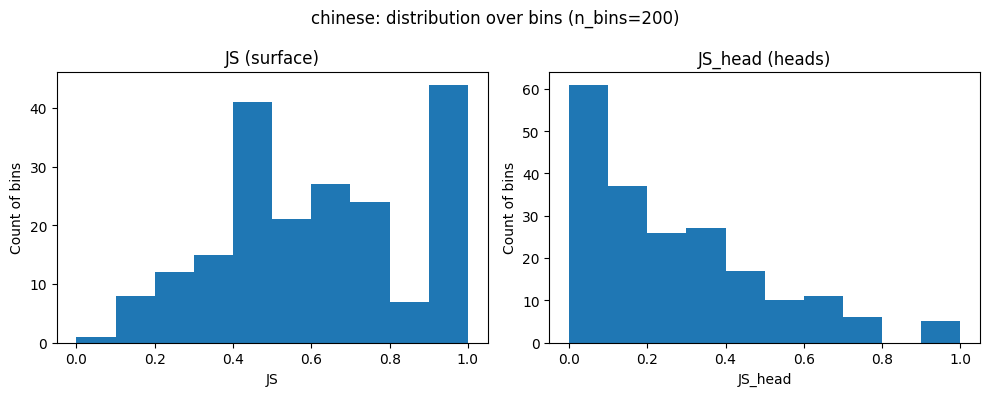

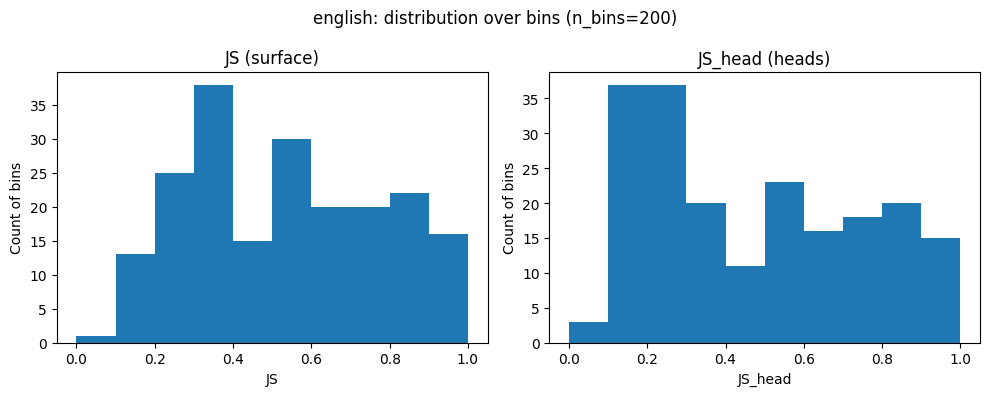

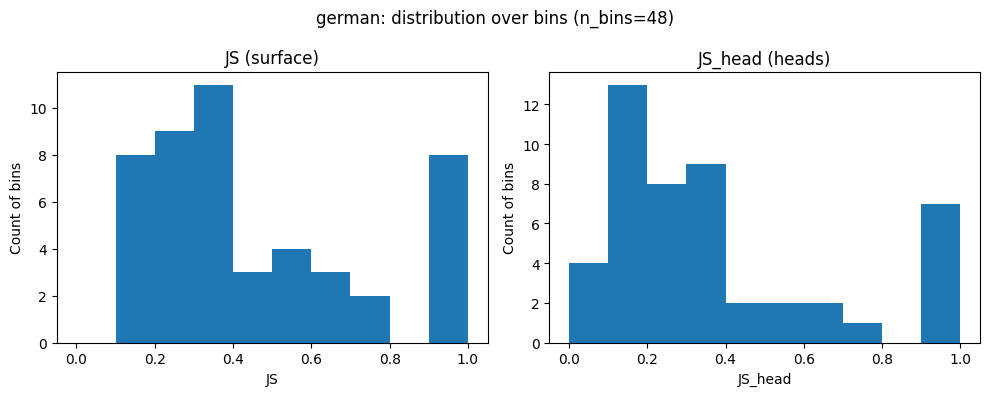

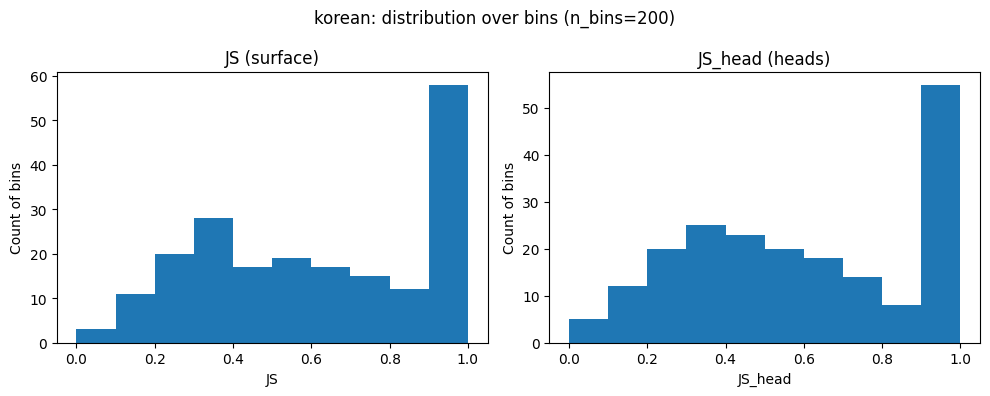

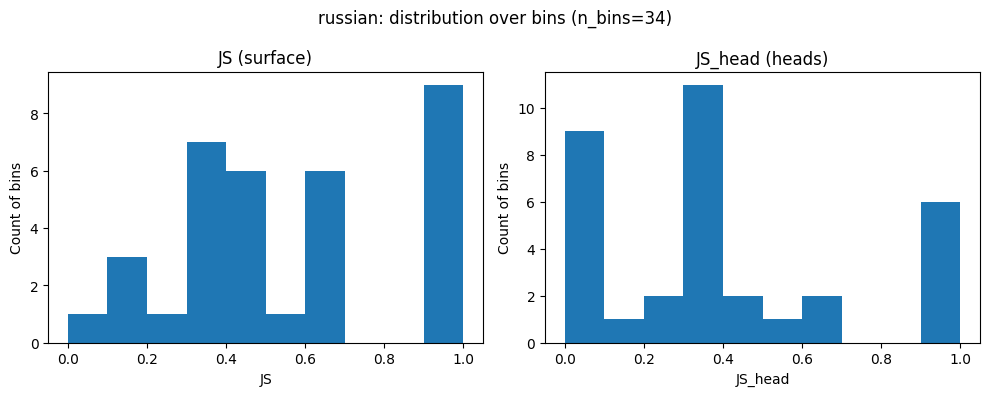

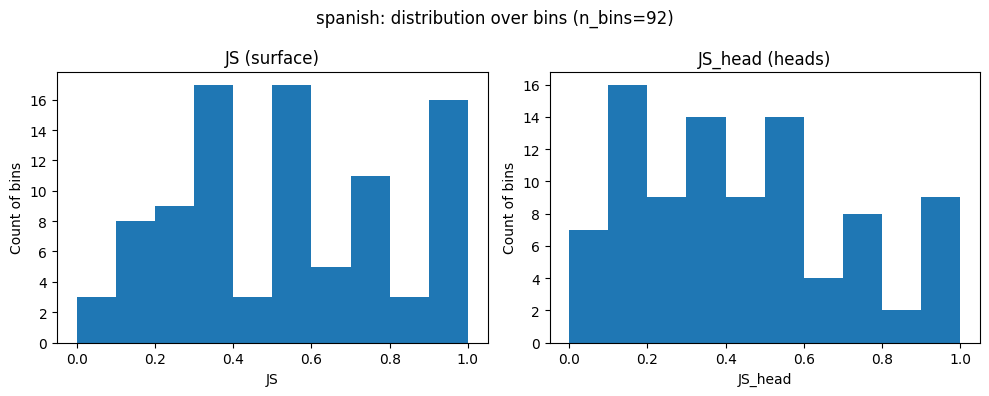


Per-language counts of bins by quality (based on JS_head):
bin_quality        lang  bad  good  mid
0               chinese   11   124   65
1               english   53    77   70
2                french    5    10   12
3                german    8    25   15
4                korean   77    37   86
5                polish    2     4    1
6            portuguese    0     2    1
7               russian    6    12   16
8               spanish   19    32   41

Per-language bin-quality counts (>=30 bins only):
      lang  bad  good  mid  n_bins
0  chinese   11   124   65     200
1  english   53    77   70     200
2   german    8    25   15      48
3   korean   77    37   86     200
4  russian    6    12   16      34
5  spanish   19    32   41      92


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Load results
# ---------------------------------------------------------------------

df = pd.read_csv("all_languages_fullgrid_results.csv")

# Sanity check on columns
print(df.columns)

# Expected key columns (from your script):
# ['lang', 'bin', 'js', 'llm_in_vocab_frac', 'js_surface',
#  'llm_surface_in_vocab_frac', 'js_head', 'llm_head_in_vocab_frac',
#  'human_surface_top', 'llm_surface_top',
#  'human_head_top', 'llm_head_top',
#  'human_labels_surface', 'human_labels_head',
#  'samples', 'human_mass', 'top_prop_head']

# ---------------------------------------------------------------------
# 1. Filter out languages with < 30 bins
# ---------------------------------------------------------------------

# Count distinct bins per language
bin_counts = df.groupby("lang")["bin"].nunique().rename("n_bins")
print("\nNumber of bins per language:")
print(bin_counts)

# Merge counts into a summary table
summary = (
    df.groupby("lang")
      .agg(
          n_bins=("bin", "nunique"),
          js_mean=("js", "mean"),
          js_head_mean=("js_head", "mean"),
          llm_surface_in_vocab_mean=("llm_surface_in_vocab_frac", "mean"),
          llm_head_in_vocab_mean=("llm_head_in_vocab_frac", "mean"),
          human_mass_total=("human_mass", "sum"),
      )
      .reset_index()
)

print("\nFull summary (all languages):")
print(summary)

# Keep only languages with at least 30 bins
summary_30 = summary[summary["n_bins"] >= 30].copy()

print("\nSummary for languages with >= 30 bins:")
print(summary_30)

# If you want a quick ranking by head-level JS (only reasonably sampled langs):
summary_30_sorted = summary_30.sort_values("js_head_mean")
print("\nLanguages (>=30 bins) sorted by mean JS_head (lower is better alignment):")
print(summary_30_sorted[["lang", "n_bins", "js_head_mean",
                         "llm_surface_in_vocab_mean", "llm_head_in_vocab_mean"]])

# ---------------------------------------------------------------------
# 2. Per-language histograms (JS, JS_head), only for langs with >= 30 bins
# ---------------------------------------------------------------------

# You can adjust bins / ranges as needed
for lang, df_lang in df.groupby("lang"):
    n_bins = df_lang["bin"].nunique()
    if n_bins < 30:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f"{lang}: distribution over bins (n_bins={n_bins})")

    # JS_surface (fine-grained labels)
    axes[0].hist(df_lang["js"], bins=10, range=(0, 1))
    axes[0].set_title("JS (surface)")
    axes[0].set_xlabel("JS")
    axes[0].set_ylabel("Count of bins")

    # JS_head (coarse heads)
    axes[1].hist(df_lang["js_head"], bins=10, range=(0, 1))
    axes[1].set_title("JS_head (heads)")
    axes[1].set_xlabel("JS_head")
    axes[1].set_ylabel("Count of bins")

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# 3. Label "good" vs "bad" bins by JS_head and inspect them
# ---------------------------------------------------------------------

GOOD_THR = 0.3   # low divergence, good alignment
BAD_THR  = 0.7   # high divergence, strong mismatch

def label_quality(js_head_value: float) -> str:
    if js_head_value <= GOOD_THR:
        return "good"
    elif js_head_value >= BAD_THR:
        return "bad"
    else:
        return "mid"

df["bin_quality"] = df["js_head"].apply(label_quality)

# Per-language counts of good/mid/bad bins
quality_counts = (
    df.groupby(["lang", "bin_quality"])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

print("\nPer-language counts of bins by quality (based on JS_head):")
print(quality_counts)

# If you want this restricted to well-sampled languages:
quality_counts_30 = quality_counts.merge(
    summary_30[["lang", "n_bins"]],
    on="lang",
    how="inner",
)
print("\nPer-language bin-quality counts (>=30 bins only):")
print(quality_counts_30)

# ---------------------------------------------------------------------
# 4. Helper: inspect concrete good/bad bins for a given language
# ---------------------------------------------------------------------

def inspect_examples(lang: str, quality: str = "good", k: int = 5) -> pd.DataFrame:
    """
    Return k example bins for a given language and 'good' / 'bad' / 'mid' quality.
    Shows JS_head and top human/LLM labels for quick qualitative inspection.
    """
    sub = df[(df["lang"] == lang) & (df["bin_quality"] == quality)].copy()

    if sub.empty:
        print(f"No bins of quality='{quality}' for language {lang}")
        return sub

    # For "good", sort from lowest JS_head; for "bad", from highest
    ascending = (quality != "bad")
    sub = sub.sort_values("js_head", ascending=ascending)

    cols = [
        "lang",
        "bin",
        "js_head",
        "human_head_top",
        "llm_head_top",
        "human_surface_top",
        "llm_surface_top",
        "human_mass",
        "top_prop_head",
    ]
    return sub[cols].head(k)

# Example usage:
# inspect_examples("english", "good", k=10)
# inspect_examples("english", "bad", k=10)
# inspect_examples("russian", "good", k=10)
# inspect_examples("russian", "bad", k=10)

# ---------------------------------------------------------------------
# 5. Very lightweight "discussion-style" summary per language (optional)
# ---------------------------------------------------------------------

def summarize_language_for_text(lang: str) -> None:
    """
    Print a short text-y summary for one language, based on the filtered stats.
    Use this to draft the Discussion section.
    """
    row = summary_30[summary_30["lang"] == lang]
    if row.empty:
        print(f"{lang}: fewer than 30 bins or not found in summary_30.")
        return

    row = row.iloc[0]
    good_mid_bad = quality_counts_30[quality_counts_30["lang"] == lang]
    if not good_mid_bad.empty:
        good = int(good_mid_bad.get("good", 0))
        mid  = int(good_mid_bad.get("mid", 0))
        bad  = int(good_mid_bad.get("bad", 0))
    else:
        good = mid = bad = 0

    print(f"\n=== {lang} ===")
    print(f"Bins: {row.n_bins}")
    print(f"Mean JS (surface): {row.js_mean:.3f}")
    print(f"Mean JS_head: {row.js_head_mean:.3f}")
    print(f"LLM in-vocab (surface, mean): {row.llm_surface_in_vocab_mean:.2f}")
    print(f"LLM in-vocab (head, mean): {row.llm_head_in_vocab_mean:.2f}")
    print(f"Approx. bin quality counts (good/mid/bad): {good}/{mid}/{bad}")

# Example:
# summarize_language_for_text("english")
# summarize_language_for_text("russian")
# summarize_language_for_text("spanish")


In [ ]:
inspect_examples("english", "good", k=10)
inspect_examples("english", "bad", k=10)
inspect_examples("russian", "good", k=10)
inspect_examples("russian", "bad", k=10)

,lang,bin,js_head,human_head_top,llm_head_top,human_surface_top,llm_surface_top,human_mass,top_prop_head
686,russian,"(8, -4, -2)",1.0,голубой,<OTHER_HEAD>,голубои,<OTHER_SURF>,7,0.714286
691,russian,"(3, -2, 0)",1.0,зелёный,<OTHER_HEAD>,сине зеленыи,<OTHER_SURF>,5,0.600000
696,russian,"(8, 2, 3)",1.0,бежевыи,<OTHER_HEAD>,бежевыи,<OTHER_SURF>,5,0.400000
698,russian,"(4, 6, -4)",1.0,фуксия,<OTHER_HEAD>,фуксия,<OTHER_SURF>,6,0.333333
713,russian,"(5, 7, -2)",1.0,фуксия,<OTHER_HEAD>,фуксия,<OTHER_SURF>,6,0.666667
716,russian,"(7, -2, 7)",1.0,зелёный,<OTHER_HEAD>,зеленыи,<OTHER_SURF>,5,0.600000


In [ ]:
summarize_language_for_text("english")
summarize_language_for_text("russian")
summarize_language_for_text("spanish")


=== english ===
Bins: 200
Mean JS (surface): 0.538
Mean JS_head: 0.475
LLM in-vocab (surface, mean): 0.96
LLM in-vocab (head, mean): 0.96
Approx. bin quality counts (good/mid/bad): 77/70/53

=== russian ===
Bins: 34
Mean JS (surface): 0.567
Mean JS_head: 0.401
LLM in-vocab (surface, mean): 0.67
LLM in-vocab (head, mean): 0.75
Approx. bin quality counts (good/mid/bad): 12/16/6

=== spanish ===
Bins: 92
Mean JS (surface): 0.545
Mean JS_head: 0.439
LLM in-vocab (surface, mean): 0.74
LLM in-vocab (head, mean): 0.86
Approx. bin quality counts (good/mid/bad): 32/41/19


/tmp/ipython-input-1496247142.py:180: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  good = int(good_mid_bad.get("good", 0))
/tmp/ipython-input-1496247142.py:181: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  mid  = int(good_mid_bad.get("mid", 0))
/tmp/ipython-input-1496247142.py:182: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  bad  = int(good_mid_bad.get("bad", 0))


In [ ]:
data = [
    ("chinese", 200, 0.624378, 0.268253),
    ("english", 200, 0.538383, 0.474679),
    ("french", 27, 0.576513, 0.435651),
    ("german", 48, 0.458662, 0.382918),
    ("korean", 200, 0.626561, 0.605868),
    ("polish", 7, 0.448844, 0.448844),
    ("portuguese", 3, 0.296869, 0.190120),
    ("russian", 34, 0.567191, 0.400829),
    ("spanish", 92, 0.544502, 0.439191),
]

df_all = pd.DataFrame(data, columns=["lang","n_bins","js_mean","js_head_mean"])
df_all


,lang,n_bins,js_mean,js_head_mean
0,chinese,200,0.624378,0.268253
1,english,200,0.538383,0.474679
2,french,27,0.576513,0.435651
3,german,48,0.458662,0.382918
4,korean,200,0.626561,0.605868
5,polish,7,0.448844,0.448844
6,portuguese,3,0.296869,0.190120
7,russian,34,0.567191,0.400829
8,spanish,92,0.544502,0.439191


In [ ]:
# -------------------------------------------------------
# Head-level mapping for confusion matrices
# -------------------------------------------------------

EN_HEAD_PATTERNS = [
    ("red",     ["red", "crimson", "scarlet", "maroon"]),
    ("orange",  ["orange", "amber", "apricot"]),
    ("yellow",  ["yellow", "gold", "mustard"]),
    ("green",   ["green", "lime", "olive", "mint", "chartreuse", "grass"]),
    ("blue",    ["blue", "navy", "teal", "turquoise", "cyan", "aqua", "azure"]),
    ("purple",  ["purple", "violet", "lavender", "indigo", "plum"]),
    ("pink",    ["pink", "magenta", "fuchsia", "salmon", "peach", "coral", "rose", "raspberry"]),
    ("brown",   ["brown", "chocolate", "tan", "beige", "coffee", "camel", "bronze"]),
    ("gray",    ["gray", "grey", "slate", "charcoal", "silver"]),
    ("black",   ["black"]),
    ("white",   ["white", "ivory", "cream"]),
]

RU_HEAD_PATTERNS = [
    ("красный",      ["красн"]),
    ("оранжевый",    ["оранж"]),
    ("желтый",       ["желт", "жолт"]),      # жёлтый already folded to желтый
    ("зеленый",      ["зелен", "зелён", "зел", "олив", "хаки"]),
    ("синий",        ["син"]),
    ("голубой",      ["голуб"]),
    ("бирюзовый",    ["бирюз"]),
    ("фиолетовый",   ["фиолет", "лилов"]),
    ("розовый",      ["розов", "фукс"]),
    ("коричневый",   ["коричнев"]),
    ("серый",        ["сер"]),
    ("черный",       ["черн"]),
    ("белый",        ["бел"]),
]


def surface_to_head(lang: str, label: str) -> str:
    """
    Map a surface label to a coarse head category.
    Used only for confusion matrices.
    """
    s = norm_label(label)
    lang_key = lang.lower()

    if lang_key in {"english", "en"}:
        for cat, pats in EN_HEAD_PATTERNS:
            for p in pats:
                if p in s:
                    return cat
        toks = s.split()
        return toks[-1] if toks else "<other>"

    if lang_key in {"russian", "ru", "русский"}:
        for cat, pats in RU_HEAD_PATTERNS:
            for p in pats:
                if p in s:
                    return cat
        toks = s.split()
        return toks[-1] if toks else "<other>"

    # other languages: just use normalized last token as "head"
    toks = s.split()
    return toks[-1] if toks else "<other>"


def collapse_to_heads(lang: str, dist: dict) -> dict:
    """
    Collapse a surface-level distribution {label -> p}
    into head categories {head -> p}, then renormalize.
    """
    head_acc = {}
    for lab, p in dist.items():
        h = surface_to_head(lang, lab)
        head_acc[h] = head_acc.get(h, 0.0) + float(p)
    tot = sum(head_acc.values())
    if tot <= 0:
        return {}
    return {h: v / tot for h, v in head_acc.items()}


# -------------------------------------------------------
# Build head-level confusion matrix
# -------------------------------------------------------

def build_confusion_from_human_and_llm(
    lang: str,
    human_dists: dict,
    human_mass: dict,
    llm_dists: dict,
    min_mass: float = 1.0,
    min_llm_samples: int = 1,
    min_row_frac: float = 0.02,
    min_col_frac: float = 0.02,
):
    """
    Returns a pandas DataFrame *head-level* confusion matrix:

      rows = human top head label
      cols = GPT-4o top head label
      values = sum of human_mass over bins (heavily-sampled bins weigh more).

    human_dists and llm_dists are surface-level distributions;
    they are collapsed to heads inside this function.

    Very rare heads (rows/cols whose total mass is below
    min_row_frac / min_col_frac of total mass) are dropped to
    reduce clutter in the plot.
    """

    lang_key = lang.lower()

    # Russian uses pTC mass in [0, 1]; do not throw everything away.
    if lang_key in {"russian", "ru", "русский"}:
        eff_min_mass = 0.0
    else:
        eff_min_mass = min_mass

    human_bins = set(human_dists.keys())
    llm_bins   = set(llm_dists.keys())
    shared     = human_bins & llm_bins
    print(f"[{lang}] shared bins (human & LLM):", len(shared))

    rows = []
    for b in shared:
        mass = human_mass.get(b, 0.0)
        if mass < eff_min_mass:
            continue

        hp_surf = human_dists.get(b, {})
        mp_surf = llm_dists.get(b, {})
        if not hp_surf or not mp_surf:
            continue

        # collapse to head categories
        hp = collapse_to_heads(lang, hp_surf)
        mp = collapse_to_heads(lang, mp_surf)
        if not hp or not mp:
            continue

        human_top = max(hp.items(), key=lambda kv: kv[1])[0]
        llm_top   = max(mp.items(), key=lambda kv: kv[1])[0]

        rows.append((human_top, llm_top, mass))

    if not rows:
        print(f"[{lang}] no bins survived mass/coverage filters")
        return None

    df_rows = pd.DataFrame(rows, columns=["human_top", "llm_top", "mass"])

    # Initial weighted crosstab
    mat = pd.crosstab(
        df_rows["human_top"],
        df_rows["llm_top"],
        values=df_rows["mass"],
        aggfunc="sum",
    ).fillna(0.0)

    # Prune very rare heads (by total mass) to reduce clutter,
    # then sort rows/cols by remaining total mass.
    total_mass = mat.values.sum()

    row_totals = mat.sum(axis=1)
    col_totals = mat.sum(axis=0)

    row_keep = row_totals[row_totals >= total_mass * min_row_frac].index
    col_keep = col_totals[col_totals >= total_mass * min_col_frac].index

    mat = mat.loc[row_keep, col_keep]

    # Recompute totals and sort
    row_totals = mat.sum(axis=1).sort_values(ascending=False)
    col_totals = mat.sum(axis=0).sort_values(ascending=False)

    mat = mat.loc[row_totals.index, col_totals.index]

    return mat


# -------------------------------------------------------
# Run for all languages where BOTH human + LLM files exist
# -------------------------------------------------------

for lang, human_csv in HUMAN_FILES.items():
    llm_csv = LLM_FILES.get(lang)
    if llm_csv is None or not llm_csv.exists():
        print(f"\n[{lang}] No LLM CSV found at {llm_csv}, skipping.")
        continue
    if not human_csv.exists():
        print(f"\n[{lang}] Human CSV missing at {human_csv}, skipping.")
        continue

    print(f"\n=== {lang.upper()} ===")
    human_dists, human_mass = build_human_bin_distributions(human_csv, lang)
    llm_dists, llm_counts   = build_llm_bin_distributions(llm_csv, lang)

    mat = build_confusion_from_human_and_llm(
        lang,
        human_dists,
        human_mass,
        llm_dists,
        min_mass=5.0,      # overridden to 0.0 inside for Russian
        min_llm_samples=1,
        min_row_frac=0.02, # tweak these if English is still too busy
        min_col_frac=0.02,
    )

    if mat is not None and not mat.empty:
        mat.to_csv(OUT_DIR / f"confusion_head_{lang}.csv")
        plot_and_save_confusion(mat, lang, f"confusion_head_{lang}.png")
    else:
        print(f"[{lang}] confusion matrix is empty; nothing saved.")



=== ENGLISH ===
[english] human rows: 145709
[english] human bins with data: 1267
[english] LLM rows: 1000
[english] LLM bins with data: 200
[english] shared bins (human & LLM): 200
[english] saved /content/drive/MyDrive/2025_2026/color/figures/confusion_head_english.png

=== RUSSIAN ===
[russian] human rows: 1848
[russian] human bins with data: 145
[russian] LLM rows: 1682
[russian] LLM bins with data: 832
[russian] shared bins (human & LLM): 97
[russian] saved /content/drive/MyDrive/2025_2026/color/figures/confusion_head_russian.png


**# MAKING THE PAPER STRONGER**




In [ ]:
# ================================================================
# CONTROL EXPERIMENTS ON UW FULL-GRID DATA (EN + RU)
#   - Uses per-language cleaned_full_data.csv (full grid)
#   - No reliance on earlier notebook variables
# ================================================================

import os, io, re, base64
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from openai import OpenAI

# ----------------------------
# CONFIG: paths + model
# ----------------------------

UW_ROOT = "/content/drive/MyDrive/2025_2026/color/uw-data/extracted_langs"
EN_FULL = f"{UW_ROOT}/english/cleaned_full_data.csv"
RU_FULL = f"{UW_ROOT}/russian/cleaned_full_data.csv"

MODEL = "gpt-4o-mini"   # or your main model
client = OpenAI()       # assumes OPENAI_API_KEY is set

# ----------------------------
# JS divergence helper
# ----------------------------

def jensen_shannon(p_dict, q_dict, base=2):
    keys = sorted(set(p_dict.keys()) | set(q_dict.keys()))
    p = np.array([p_dict.get(k, 0.0) for k in keys], dtype=float)
    q = np.array([q_dict.get(k, 0.0) for k in keys], dtype=float)
    p /= p.sum() + 1e-12
    q /= q.sum() + 1e-12
    m = 0.5 * (p + q)

    def kl(a, b):
        mask = (a > 0) & (b > 0)
        if not np.any(mask):
            return 0.0
        a = a[mask]
        b = b[mask]
        return np.sum(a * (np.log(a) - np.log(b)))

    js = 0.5 * kl(p, m) + 0.5 * kl(q, m)
    return float(js / np.log(base))

# ----------------------------
# Prompts
# ----------------------------

def build_free_prompt(lang_code: str) -> str:
    if lang_code == "en":
        return (
            "You see a solid-colored square.\n"
            "Give a natural, descriptive English color name.\n"
            "Avoid using only basic color words like red, orange, yellow, "
            "green, blue, or purple.\n"
            "Use a more specific or nuanced color term.\n"
            "Answer with one word or a very short phrase."
        )
    if lang_code == "ru":
        return (
            "Вы видите квадрат, залитый одним цветом.\n"
            "Дайте естественное русское название этого цвета.\n"
            "Не ограничивайтесь только базовыми цветами (красный, оранжевый, "
            "жёлтый, зелёный, синий, голубой, фиолетовый).\n"
            "Используйте более точное или оттеночное название.\n"
            "Ответьте одним словом или очень короткой фразой."
        )
    return (
        "You see a solid-colored square.\n"
        "Give a natural color name in this language.\n"
        "Answer with one word or a very short phrase."
    )

def build_basic_prompt(lang_code: str) -> str:
    # If you had a basic-term experiment; for our controls we can reuse the free prompt,
    # but it's here if you want to parallel Exp D exactly.
    return build_free_prompt(lang_code)

# ----------------------------
# Text normalization
# ----------------------------

def normalize_label(text: str, lang: str) -> str:
    """Light free-form normalization; no mapping to fixed list."""
    s = str(text).strip().lower()
    if not s:
        return ""
    s = re.sub(r"[^\w\s\-ё]", " ", s, flags=re.UNICODE)
    s = re.sub(r"\s+", " ", s).strip()
    if not s:
        return ""
    tokens = s.split()
    return " ".join(tokens[:3])

def make_llm_normalizer(lang_code: str, human_vocab: set):
    """Map LLM output onto human vocab where possible."""
    if lang_code == "ru":
        def normalize_ru(text: str) -> str:
            s = str(text).strip().lower()
            if not s:
                return ""
            if s in human_vocab:
                return s
            alt = s.replace("й", "и")
            if alt in human_vocab:
                return alt
            s2 = " ".join(s.split())
            if s2 in human_vocab:
                return s2
            return s2
        return normalize_ru

    if lang_code == "en":
        def normalize_en(text: str) -> str:
            s = str(text).strip().lower()
            if not s:
                return ""
            if s in human_vocab:
                return s
            if s == "grey" and "gray" in human_vocab:
                return "gray"
            s2 = " ".join(s.split())
            if s2 in human_vocab:
                return s2
            return s2
        return normalize_en

    def normalize_default(text: str) -> str:
        s = str(text).strip().lower()
        if not s:
            return ""
        return " ".join(s.split())
    return normalize_default

# ----------------------------
# RGB → data URL
# ----------------------------

def rgb_to_data_url(r: int, g: int, b: int, size: int = 128) -> str:
    img = Image.new("RGB", (size, size), (int(r), int(g), int(b)))
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    b64 = base64.b64encode(buf.getvalue()).decode("ascii")
    return f"data:image/png;base64,{b64}"

# ----------------------------
# Load per-language FULL-GRID data
# ----------------------------

def load_full_grid(path: str):
    """
    Load a per-language cleaned_full_data.csv and build:
      - human_tiles: tileNum -> {label: prob}
      - tile_rgb:    tileNum -> (r,g,b)
      - tile_chroma: tileNum -> mean LAB chroma (sqrt(a^2 + b^2))
      - human_vocab: set of labels
      - df_lang:     original dataframe
    """
    df = pd.read_csv(path)
    print("Loaded", path)
    print("Columns:", list(df.columns))

    # Response column
    if "standardized_entered_name" in df.columns:
        resp = df["standardized_entered_name"]
        if resp.isna().all() and "entered_name" in df.columns:
            resp = df["entered_name"]
    elif "entered_name" in df.columns:
        resp = df["entered_name"]
    else:
        resp = df["name"]
    df["resp"] = resp

    if "tileNum" not in df.columns:
        raise ValueError("Expected 'tileNum' in cleaned_full_data.csv")

    for col in ["r", "g", "b", "lab_a", "lab_b"]:
        if col not in df.columns:
            raise ValueError(f"Missing column '{col}' in {path}")

    human_tiles = {}
    tile_rgb = {}
    tile_chroma = {}
    for tile, group in df.groupby("tileNum"):
        counts = Counter(
            str(x).strip().lower()
            for x in group["resp"].tolist()
            if str(x).strip()
        )
        total = sum(counts.values())
        if total <= 0:
            continue
        probs = {k: v / total for k, v in counts.items()}
        human_tiles[int(tile)] = probs

        r = int(round(group["r"].mean()))
        g = int(round(group["g"].mean()))
        b = int(round(group["b"].mean()))
        tile_rgb[int(tile)] = (r, g, b)

        a_vals = group["lab_a"].to_numpy(float)
        b_vals = group["lab_b"].to_numpy(float)
        chroma = float(np.mean(np.sqrt(a_vals**2 + b_vals**2)))
        tile_chroma[int(tile)] = chroma

    human_vocab = set()
    for probs in human_tiles.values():
        human_vocab.update(probs.keys())

    print(f"Tiles: {len(human_tiles)} | vocab size: {len(human_vocab)}")
    return human_tiles, tile_rgb, tile_chroma, human_vocab, df

# ================================================================
# 1. LOAD EN + RU FULL-GRID HUMAN DATA
# ================================================================

human_en_tiles, en_rgb, en_chroma, human_vocab_en, df_en = load_full_grid(EN_FULL)
human_ru_tiles, ru_rgb, ru_chroma, human_vocab_ru, df_ru = load_full_grid(RU_FULL)

normalize_en_head = make_llm_normalizer("en", human_vocab_en)
normalize_ru_head = make_llm_normalizer("ru", human_vocab_ru)

# ================================================================
# 2. TEXT-ONLY BASELINE (NO IMAGE) VS HUMAN FULL-GRID
# ================================================================

def estimate_text_prior(lang_code: str, normalize_head_fn, n_samples=200, temperature=0.7):
    prompt = build_free_prompt(lang_code)
    labels = []

    for _ in tqdm(range(n_samples), desc=f"text-only prior ({lang_code})"):
        resp = client.responses.create(
            model=MODEL,
            input=[{
                "role": "user",
                "content": [
                    {"type": "input_text", "text": prompt},
                ],
            }],
            max_output_tokens=32,
            temperature=temperature,
        )
        out = resp.output[0].content
        text_blocks = [c for c in out if getattr(c, "type", None) == "output_text"]
        raw = text_blocks[0].text if text_blocks else (out[0].text if out else "")

        base = normalize_label(raw, lang_code)
        head = normalize_head_fn(base)
        if head:
            labels.append(head)

    counts = Counter(labels)
    total = sum(counts.values())
    prior = {k: v / total for k, v in counts.items()} if total > 0 else {}
    return prior, counts

def js_vs_text_prior_by_tile(human_tiles: dict, prior_probs: dict):
    rows = []
    for tile, human_probs in human_tiles.items():
        keys = set(human_probs.keys()) | set(prior_probs.keys())
        h_vec = np.array([human_probs.get(k, 0.0) for k in keys])
        p_vec = np.array([prior_probs.get(k, 0.0) for k in keys])
        if h_vec.sum() > 0:
            h_vec = h_vec / h_vec.sum()
        if p_vec.sum() > 0:
            p_vec = p_vec / p_vec.sum()
        js = jensen_shannon(
            dict(zip(keys, h_vec)),
            dict(zip(keys, p_vec)),
        )
        rows.append({"tileNum": tile, "js_text_prior": js})
    return pd.DataFrame(rows).sort_values("tileNum")

# ---- EN text-only baseline ----
prior_en, counts_en = estimate_text_prior(
    lang_code="en",
    normalize_head_fn=normalize_en_head,
    n_samples=200,
    temperature=0.7,
)
df_en_text_prior = js_vs_text_prior_by_tile(human_en_tiles, prior_en)
print("\n=== EN: JS(human vs text-only prior) per tile ===")
print(df_en_text_prior["js_text_prior"].describe())

# ---- RU text-only baseline ----
prior_ru, counts_ru = estimate_text_prior(
    lang_code="ru",
    normalize_head_fn=normalize_ru_head,
    n_samples=200,
    temperature=0.7,
)
df_ru_text_prior = js_vs_text_prior_by_tile(human_ru_tiles, prior_ru)
print("\n=== RU: JS(human vs text-only prior) per tile ===")
print(df_ru_text_prior["js_text_prior"].describe())

# ================================================================
# 3. SATURATION RATING SANITY CHECK (LOW vs HIGH CHROMA)
# ================================================================

def query_saturation_rating(rgb_tuple, n_reps: int = 5):
    r, g, b = rgb_tuple
    img_url = rgb_to_data_url(r, g, b)
    prompt = (
        "You see a single solid-colored square.\n"
        "On a scale from 1 to 5, where 1 means 'very gray / desaturated' "
        "and 5 means 'very vivid / saturated', how saturated does this "
        "color look? Answer with a single integer from 1 to 5."
    )
    ratings = []
    for _ in range(n_reps):
        resp = client.responses.create(
            model=MODEL,
            input=[{
                "role": "user",
                "content": [
                    {"type": "input_image", "image_url": img_url},
                    {"type": "input_text", "text": prompt},
                ],
            }],
            max_output_tokens=32,
            temperature=0.3,
        )
        out = resp.output[0].content
        text_blocks = [c for c in out if getattr(c, "type", None) == "output_text"]
        raw = text_blocks[0].text if text_blocks else (out[0].text if out else "")
        m = re.search(r"[1-5]", raw)
        if m:
            ratings.append(int(m.group(0)))
    return ratings

def pick_low_high_chroma_tiles(tile_chroma: dict, n_low=8, n_high=8):
    items = sorted(tile_chroma.items(), key=lambda kv: kv[1])
    if len(items) < (n_low + n_high):
        n_low = max(1, len(items) // 4)
        n_high = n_low
    low_tiles = [t for t, c in items[:n_low]]
    high_tiles = [t for t, c in items[-n_high:]]
    return low_tiles, high_tiles

def saturation_block(lang_label, tile_chroma, tile_rgb):
    low_tiles, high_tiles = pick_low_high_chroma_tiles(tile_chroma, n_low=8, n_high=8)
    records = []
    for t in tqdm(low_tiles + high_tiles, desc=f"{lang_label} saturation probes"):
        group = "low" if t in low_tiles else "high"
        ratings = query_saturation_rating(tile_rgb[t], n_reps=5)
        if not ratings:
            continue
        records.append({
            "lang": lang_label,
            "tileNum": t,
            "group": group,
            "mean_rating": float(np.mean(ratings)),
            "std_rating": float(np.std(ratings)),
            "n_ratings": len(ratings),
        })
    return pd.DataFrame(records)

df_en_saturation = saturation_block("en", en_chroma, en_rgb)
df_ru_saturation = saturation_block("ru", ru_chroma, ru_rgb)

print("\n=== EN saturation ratings (1–5) ===")
if not df_en_saturation.empty:
    print(df_en_saturation.groupby("group")["mean_rating"].describe())

print("\n=== RU saturation ratings (1–5) ===")
if not df_ru_saturation.empty:
    print(df_ru_saturation.groupby("group")["mean_rating"].describe())

# ================================================================
# 4. TEMPERATURE SWEEP ON LOW-CHROMA TILES (IMAGE-BASED)
# ================================================================

def query_color_name_image(
    lang_code: str,
    rgb_tuple,
    normalize_head_fn,
    n_samples: int = 20,
    temperature: float = 0.7,
):
    r, g, b = rgb_tuple
    img_url = rgb_to_data_url(r, g, b)
    prompt = build_free_prompt(lang_code)
    labels = []

    for _ in range(n_samples):
        resp = client.responses.create(
            model=MODEL,
            input=[{
                "role": "user",
                "content": [
                    {"type": "input_image", "image_url": img_url},
                    {"type": "input_text", "text": prompt},
                ],
            }],
            max_output_tokens=32,
            temperature=temperature,
        )
        out = resp.output[0].content
        text_blocks = [c for c in out if getattr(c, "type", None) == "output_text"]
        raw = text_blocks[0].text if text_blocks else (out[0].text if out else "")
        base = normalize_label(raw, lang_code)
        head = normalize_head_fn(base)
        if head:
            labels.append(head)

    counts = Counter(labels)
    total = sum(counts.values())
    probs = {k: v / total for k, v in counts.items()} if total > 0 else {}
    return probs, total

def temperature_sweep_on_low_chroma(
    lang_code: str,
    human_tiles: dict,
    tile_chroma: dict,
    tile_rgb: dict,
    normalize_head_fn,
    temps = (0.1, 0.3, 0.7, 1.0),
    n_tiles: int = 10,
    n_samples: int = 20,
):
    items = sorted(tile_chroma.items(), key=lambda kv: kv[1])
    low_tiles = [t for t, c in items[:n_tiles]]
    rows = []

    for tile in tqdm(low_tiles, desc=f"{lang_code} temp sweep (low chroma)"):
        human_probs = human_tiles.get(tile, None)
        if not human_probs:
            continue
        rgb = tile_rgb[tile]
        for T in temps:
            llm_probs, total = query_color_name_image(
                lang_code=lang_code,
                rgb_tuple=rgb,
                normalize_head_fn=normalize_head_fn,
                n_samples=n_samples,
                temperature=T,
            )
            js = jensen_shannon(human_probs, llm_probs) if llm_probs else np.nan
            rows.append({
                "lang": lang_code,
                "tileNum": tile,
                "temperature": T,
                "js_head": js,
                "n_samples": total,
            })
    return pd.DataFrame(rows)

df_en_temp = temperature_sweep_on_low_chroma(
    "en", human_en_tiles, en_chroma, en_rgb, normalize_en_head,
    temps=(0.1, 0.3, 0.7, 1.0), n_tiles=10, n_samples=20
)

df_ru_temp = temperature_sweep_on_low_chroma(
    "ru", human_ru_tiles, ru_chroma, ru_rgb, normalize_ru_head,
    temps=(0.1, 0.3, 0.7, 1.0), n_tiles=10, n_samples=20
)

print("\n=== EN low-chroma: JS vs temperature ===")
if not df_en_temp.empty:
    print(df_en_temp.groupby("temperature")["js_head"].describe())

print("\n=== RU low-chroma: JS vs temperature ===")
if not df_ru_temp.empty:
    print(df_ru_temp.groupby("temperature")["js_head"].describe())


Loaded /content/drive/MyDrive/2025_2026/color/uw-data/extracted_langs/english/cleaned_full_data.csv
Columns: ['colorNameId', 'participantId', 'lang0', 'phaseNum', 'trialNum', 'tileNum', 'name', 'r', 'g', 'b', 'studyVersion', 'rgbSet', 'lab_l', 'lab_a', 'lab_b', 'locale', 'standardized_entered_name', 'entered_name']
Tiles: 12 | vocab size: 8199
Loaded /content/drive/MyDrive/2025_2026/color/uw-data/extracted_langs/russian/cleaned_full_data.csv
Columns: ['colorNameId', 'participantId', 'lang0', 'phaseNum', 'trialNum', 'tileNum', 'name', 'r', 'g', 'b', 'studyVersion', 'rgbSet', 'lab_l', 'lab_a', 'lab_b', 'locale', 'standardized_entered_name', 'entered_name']
Tiles: 12 | vocab size: 419


text-only prior (en): 100%|██████████| 200/200 [07:33<00:00,  2.27s/it]



=== EN: JS(human vs text-only prior) per tile ===
count    12.000000
mean      0.976735
std       0.002545
min       0.971410
25%       0.975392
50%       0.977012
75%       0.977855
max       0.981777
Name: js_text_prior, dtype: float64


text-only prior (ru): 100%|██████████| 200/200 [07:30<00:00,  2.25s/it]



=== RU: JS(human vs text-only prior) per tile ===
count    12.000000
mean      0.901968
std       0.029814
min       0.833033
25%       0.891049
50%       0.913860
75%       0.917131
max       0.948814
Name: js_text_prior, dtype: float64


ru saturation probes: 100%|██████████| 6/6 [01:07<00:00, 11.18s/it]



=== EN saturation ratings (1–5) ===
       count      mean      std  min  25%  50%  75%  max
group                                                   
high     3.0  2.000000  0.00000  2.0  2.0  2.0  2.0  2.0
low      3.0  2.066667  0.11547  2.0  2.0  2.0  2.1  2.2

=== RU saturation ratings (1–5) ===
       count      mean      std  min  25%  50%  75%  max
group                                                   
high     3.0  2.000000  1.00000  1.0  1.5  2.0  2.5  3.0
low      3.0  1.666667  0.57735  1.0  1.5  2.0  2.0  2.0


ru temp sweep (low chroma): 100%|██████████| 10/10 [33:44<00:00, 202.45s/it]


=== EN low-chroma: JS vs temperature ===
             count      mean       std       min       25%       50%  \
temperature                                                            
0.1           10.0  0.984876  0.012689  0.971379  0.973894  0.979699   
0.3           10.0  0.978551  0.008699  0.965829  0.975156  0.977471   
0.7           10.0  0.976793  0.008961  0.966557  0.972837  0.975488   
1.0           10.0  0.978311  0.009265  0.967655  0.974043  0.975827   

                  75%       max  
temperature                      
0.1          0.998642  1.000000  
0.3          0.980022  0.998851  
0.7          0.978980  0.998870  
1.0          0.978542  0.994709  

=== RU low-chroma: JS vs temperature ===
             count      mean       std       min       25%       50%  \
temperature                                                            
0.1           10.0  0.956239  0.037506  0.883548  0.945122  0.946151   
0.3           10.0  0.951675  0.036610  0.873863  0.945524  0.9

# **# Regenerating some figures and tables for the paper (Experiment A)**

In [ ]:
# ============================================================
# Free-form hue-wheel analysis (EN + RU):
# entropy, vocab size, top labels + figures
# ============================================================

import os
import math
import re
import colorsys
from io import BytesIO
from collections import Counter

import matplotlib.pyplot as plt
from PIL import Image
from openai import OpenAI
import base64

# ----------------- Config --------------------
client = OpenAI()  # assumes OPENAI_API_KEY is set
languages = ["en", "ru"]
lang_names = {"en": "English", "ru": "Russian"}

n_bins = 36                  # hue bins
samples_per_hue = 20         # matches paper
temperature = 0.9            # free-form exploration
img_size = 128               # px

os.makedirs("figures", exist_ok=True)

# ----------------- Helpers -------------------

def make_color_patch(h_idx, n_bins=36, s=1.0, v=1.0, size=128):
    """
    Generate a solid HSV patch for hue index h_idx.
    h_idx in [0, n_bins-1], s,v in [0,1].
    """
    h = h_idx / n_bins
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    rgb = (int(r * 255), int(g * 255), int(b * 255))
    img = Image.new("RGB", (size, size), rgb)
    return img

def encode_image(img: Image.Image) -> str:
    buf = BytesIO()
    img.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode("utf-8")

def normalize_label(text: str) -> str:
    """Simple normalization: lowercase + strip quotes/punctuation."""
    text = text.strip().lower()
    text = re.sub(r'[\"\'“”„«».,!?;:]', '', text)
    return text

def get_prompt(lang: str) -> str:
    if lang == "en":
        return (
            "You see a solid-colored square.\n"
            "Give a natural, descriptive English color name.\n"
            "Avoid using only basic color words like red, orange, yellow, "
            "green, blue, or purple.\n"
            "Use a more specific or nuanced color term.\n"
            "Answer with one word or a very short phrase."
        )
    elif lang == "ru":
        return (
            "Вы видите квадрат, залитый одним цветом.\n"
            "Дайте естественное русское название этого цвета.\n"
            "Не ограничивайтесь только базовыми цветами "
            "(красный, оранжевый, жёлтый, зелёный, синий, голубой, фиолетовый).\n"
            "Используйте более точное или оттеночное название.\n"
            "Ответьте одним словом или очень короткой фразой."
        )
    else:
        raise ValueError(f"Unsupported language: {lang}")

def query_gpt4o_freeform(img: Image.Image, lang: str) -> str:
    """Single GPT-4o call: image + language-specific prompt."""
    encoded = encode_image(img)
    prompt = get_prompt(lang)
    resp = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{encoded}"}},
                ],
            }
        ],
        max_tokens=16,
        temperature=temperature,
    )
    return resp.choices[0].message.content.strip()

def entropy_from_counts(counter: Counter) -> float:
    """Shannon entropy (base 2) from a Counter of labels."""
    total = sum(counter.values())
    if total == 0:
        return 0.0
    H = 0.0
    for c in counter.values():
        p = c / total
        H -= p * math.log2(p)
    return H

# ----------------- Main loop -----------------

# For each language, store per-hue stats
entropy_by_hue = {lang: [] for lang in languages}
vocabsize_by_hue = {lang: [] for lang in languages}
toplabel_by_hue = {lang: [] for lang in languages}

for lang in languages:
    print(f"\n=== Running free-form naming for {lang_names[lang]} ({lang}) ===")
    for h_idx in range(n_bins):
        img = make_color_patch(h_idx, n_bins=n_bins, s=1.0, v=1.0, size=img_size)
        labels = []

        for _ in range(samples_per_hue):
            raw = query_gpt4o_freeform(img, lang)
            norm = normalize_label(raw)
            labels.append(norm)

        cnt = Counter(labels)
        ent = entropy_from_counts(cnt)
        vocab_size = len(cnt)
        top_label, _ = cnt.most_common(1)[0]

        entropy_by_hue[lang].append(ent)
        vocabsize_by_hue[lang].append(vocab_size)
        toplabel_by_hue[lang].append(top_label)

        print(
            f"{lang.upper()} | hue {h_idx:02d}: "
            f"H={ent:.3f}, vocab={vocab_size}, top='{top_label}'"
        )

# ----------------- Figures -------------------

# 1) Entropy by hue (free_entropy.png)
plt.figure(figsize=(8, 4))
for lang in languages:
    plt.plot(
        range(n_bins),
        entropy_by_hue[lang],
        marker="o",
        label=lang_names[lang],
    )
plt.xlabel("Hue index (0–35)")
plt.ylabel("Entropy of label distribution (bits)")
plt.title("GPT-4o free-form naming entropy by hue")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/free_entropy.png", dpi=300)
plt.close()

# 2) Vocabulary size by hue (free_vocabsize_eng_rus.png)
plt.figure(figsize=(8, 4))
for lang in languages:
    plt.plot(
        range(n_bins),
        vocabsize_by_hue[lang],
        marker="o",
        label=lang_names[lang],
    )
plt.xlabel("Hue index (0–35)")
plt.ylabel("Vocabulary size (distinct normalized labels)")
plt.title("GPT-4o free-form vocabulary size by hue")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/free_vocabsize_eng_rus.png", dpi=300)
plt.close()

# 3) Top label per hue, English + Russian (top_free_eng_rus.png)
fig, axes = plt.subplots(
    nrows=2, ncols=1, figsize=(12, 2.8), sharex=True
)
for ax, lang in zip(axes, languages):
    ax.set_xlim(0, n_bins)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks(range(n_bins))
    ax.set_xticklabels(range(n_bins), fontsize=7)
    ax.set_title(lang_names[lang])

    for h_idx in range(n_bins):
        ax.text(
            h_idx + 0.5,
            0.5,
            toplabel_by_hue[lang][h_idx],
            ha="center",
            va="center",
            fontsize=7,
        )

    ax.set_xlim(-0.5, n_bins + 0.5)
    ax.grid(axis="x", linestyle=":", alpha=0.2)

plt.suptitle("Top free-form color name per hue (GPT-4o, EN & RU)", y=1.02)
plt.tight_layout()
plt.savefig("figures/top_free_eng_rus.png", dpi=300, bbox_inches="tight")
plt.close()

print("\nSaved figures:")
print("  figures/free_entropy.png")
print("  figures/free_vocabsize_eng_rus.png")
print("  figures/top_free_eng_rus.png")



=== Running free-form naming for English (en) ===
EN | hue 00: H=1.234, vocab=3, top='crimson'
EN | hue 01: H=0.286, vocab=2, top='vermilion'
EN | hue 02: H=0.569, vocab=3, top='tangerine'
EN | hue 03: H=0.748, vocab=3, top='tangerine'
EN | hue 04: H=0.934, vocab=2, top='amber'
EN | hue 05: H=1.461, vocab=4, top='sunflower'
EN | hue 06: H=1.980, vocab=6, top='lemon'
EN | hue 07: H=0.811, vocab=2, top='chartreuse'
EN | hue 08: H=1.353, vocab=3, top='lime'
EN | hue 09: H=1.000, vocab=2, top='lime green'
EN | hue 10: H=0.722, vocab=2, top='lime'
EN | hue 11: H=1.680, vocab=4, top='lime'
EN | hue 12: H=1.141, vocab=3, top='neon green'
EN | hue 13: H=0.934, vocab=2, top='neon green'
EN | hue 14: H=1.157, vocab=3, top='neon green'
EN | hue 15: H=1.234, vocab=3, top='mint'
EN | hue 16: H=1.544, vocab=4, top='mint green'
EN | hue 17: H=1.353, vocab=3, top='turquoise'
EN | hue 18: H=0.922, vocab=3, top='turquoise'
EN | hue 19: H=0.286, vocab=2, top='cyan'
EN | hue 20: H=0.934, vocab=2, top='sk

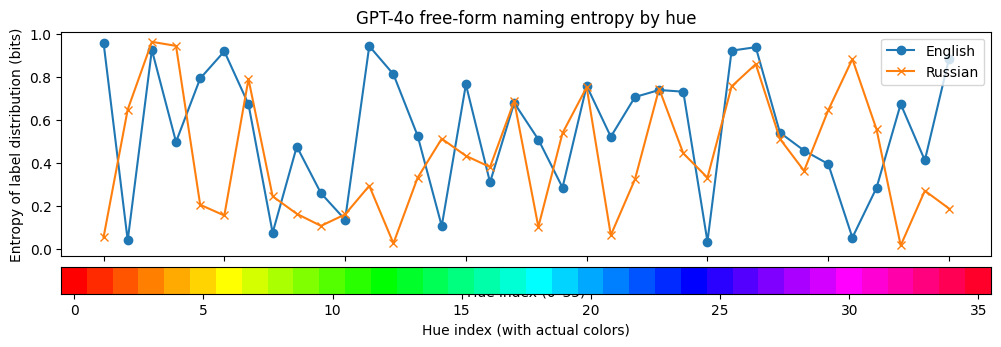

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb

# ============================================================
# 1. INSERT YOUR DATA HERE
# Replace these with real lists from your results.
# ============================================================

# Example placeholders — replace with actual values
hue_idx_en = list(range(36))
entropy_en = np.random.rand(36)  # <-- replace with df_en entropy values

hue_idx_ru = list(range(36))
entropy_ru = np.random.rand(36)  # <-- replace with df_ru entropy values

# Number of bins assumed
n_bins = len(hue_idx_en)

# ============================================================
# 2. Plotting
# ============================================================

fig, ax = plt.subplots(figsize=(12, 4))

# --- main entropy plot ---
ax.plot(hue_idx_en, entropy_en, marker="o", label="English")
ax.plot(hue_idx_ru, entropy_ru, marker="x", label="Russian")

ax.set_xlabel("Hue index (0–35)")
ax.set_ylabel("Entropy of label distribution (bits)")
ax.set_title("GPT-4o free-form naming entropy by hue")
ax.legend(loc="upper right")

# ============================================================
# 3. Add the color strip (actual hue wheel)
# ============================================================

# Create 1xN RGB strip from HSV colors
color_strip = np.zeros((1, n_bins, 3))

for i in range(n_bins):
    h = i / n_bins      # evenly spaced hue
    s = 1.0             # saturation (match your input)
    v = 1.0             # value/brightness
    color_strip[0, i, :] = hsv_to_rgb((h, s, v))

# Inset axis for the color strip
strip_h = 0.12   # height of strip
axs = ax.inset_axes([0.0, -strip_h - 0.05, 1.0, strip_h])

axs.imshow(color_strip, aspect="auto", extent=[-0.5, n_bins - 0.5, 0, 1])
axs.set_xticks(range(0, n_bins, 5))
axs.set_xticklabels(range(0, n_bins, 5))
axs.set_yticks([])
axs.set_xlabel("Hue index (with actual colors)")

fig.subplots_adjust(bottom=0.32)
plt.show()


In [ ]:
import pandas as pd

# ===== Rebuild ENGLISH free-form data (36 hues) =====
en_rows = [
    (0,  1.234, 3, "crimson"),
    (1,  0.286, 2, "vermilion"),
    (2,  0.569, 3, "tangerine"),
    (3,  0.748, 3, "tangerine"),
    (4,  0.934, 2, "amber"),
    (5,  1.461, 4, "sunflower"),
    (6,  1.980, 6, "lemon"),
    (7,  0.811, 2, "chartreuse"),
    (8,  1.353, 3, "lime"),
    (9,  1.000, 2, "lime green"),
    (10, 0.722, 2, "lime"),
    (11, 1.680, 4, "lime"),
    (12, 1.141, 3, "neon green"),
    (13, 0.934, 2, "neon green"),
    (14, 1.157, 3, "neon green"),
    (15, 1.234, 3, "mint"),
    (16, 1.544, 4, "mint green"),
    (17, 1.353, 3, "turquoise"),
    (18, 0.922, 3, "turquoise"),
    (19, 0.286, 2, "cyan"),
    (20, 0.934, 2, "sky blue"),
    (21, 0.934, 2, "cerulean"),
    (22, 0.286, 2, "cobalt"),
    (23, 0.000, 1, "cobalt"),
    (24, 0.000, 1, "cobalt"),
    (25, 2.061, 6, "indigo"),
    (26, 0.992, 3, "violet"),
    (27, 0.881, 2, "amethyst"),
    (28, 0.884, 3, "amethyst"),
    (29, 0.469, 2, "fuchsia"),
    (30, 0.934, 2, "fuchsia"),
    (31, 0.811, 2, "fuchsia"),
    (32, 0.000, 1, "fuchsia"),
    (33, 0.286, 2, "fuchsia"),
    (34, 0.722, 2, "fuchsia"),
    (35, 0.469, 2, "crimson"),
]

df_en_free_36 = pd.DataFrame(
    en_rows, columns=["hue_idx", "entropy", "vocab_size", "top_label"]
)

# ===== Rebuild RUSSIAN free-form data (36 hues) =====
ru_rows = [
    (0,  1.776, 4, "алая"),
    (1,  1.944, 6, "алый"),
    (2,  1.353, 3, "мандариновый"),
    (3,  1.141, 3, "мандариновый"),
    (4,  1.319, 4, "охра"),
    (5,  2.661, 8, "жёлток"),
    (6,  0.000, 1, "лимонный"),
    (7,  0.610, 2, "лаймовый"),
    (8,  0.469, 2, "лаймовый"),
    (9,  1.279, 3, "лаймовый"),
    (10, 1.181, 3, "лаймовый"),
    (11, 1.579, 5, "лаймовый"),
    (12, 1.717, 6, "лаймовый"),
    (13, 2.119, 7, "лаймовый"),
    (14, 1.336, 4, "салатовый"),
    (15, 1.695, 5, "мятный"),
    (16, 1.076, 3, "мятный"),
    (17, 0.000, 1, "бирюзовый"),
    (18, 0.000, 1, "бирюзовый"),
    (19, 0.000, 1, "бирюзовый"),
    (20, 2.384, 7, "бирюзовый"),
    (21, 1.601, 4, "лазурный"),
    (22, 2.433, 6, "ярко-синий"),
    (23, 1.871, 6, "кобальтовый"),
    (24, 0.848, 4, "кобальтовый"),
    (25, 1.188, 3, "индиго"),
    (26, 1.319, 4, "фиолетовый"),
    (27, 1.188, 3, "фиолетовый"),
    (28, 1.257, 4, "фуксия"),
    (29, 0.000, 1, "фуксия"),
    (30, 0.000, 1, "фуксия"),
    (31, 0.000, 1, "фуксия"),
    (32, 0.000, 1, "фуксия"),
    (33, 0.000, 1, "фуксия"),
    (34, 0.469, 2, "малиновый"),
    (35, 1.815, 4, "алый"),
]

df_ru_free_36 = pd.DataFrame(
    ru_rows, columns=["hue_idx", "entropy", "vocab_size", "top_label"]
)

print(df_en_free_36.head())
print(df_ru_free_36.head())


   hue_idx  entropy  vocab_size  top_label
0        0    1.234           3    crimson
1        1    0.286           2  vermilion
2        2    0.569           3  tangerine
3        3    0.748           3  tangerine
4        4    0.934           2      amber
   hue_idx  entropy  vocab_size     top_label
0        0    1.776           4          алая
1        1    1.944           6          алый
2        2    1.353           3  мандариновый
3        3    1.141           3  мандариновый
4        4    1.319           4          охра


/tmp/ipython-input-2367274921.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


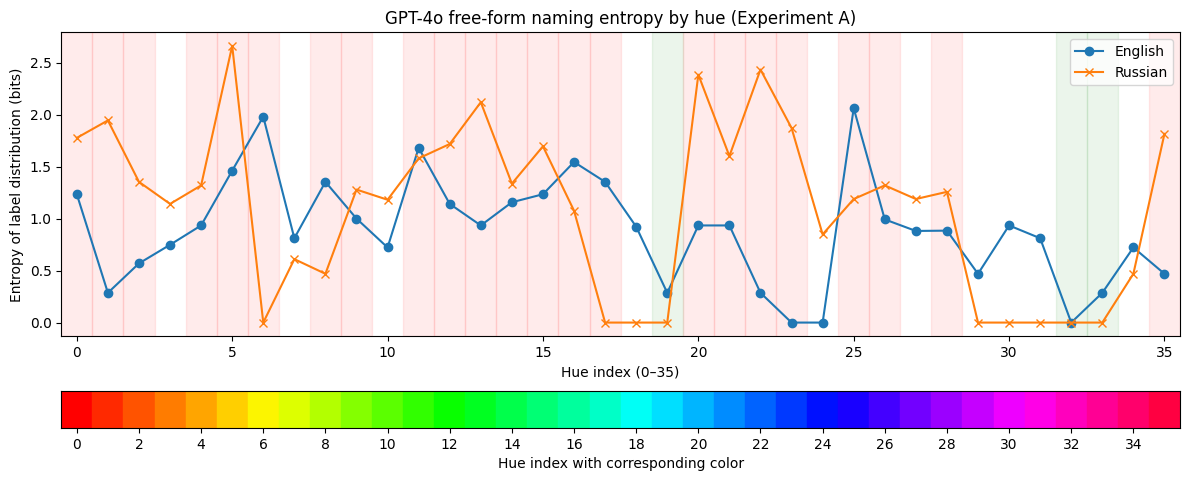

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --- data (must already exist from your free-form run) ---
df_en = df_en_free_36.copy()
df_ru = df_ru_free_36.copy()

x       = df_en["hue_idx"].values
ent_en  = df_en["entropy"].values
ent_ru  = df_ru["entropy"].values

# thresholds for "easy" vs "hard"
easy_thr = 0.35   # low entropy = very stable naming
hard_thr = 1.20   # high entropy = unstable naming

# colors for hue strip
hues = np.linspace(0, 1, 36, endpoint=False)
rgb_colors = [plt.cm.hsv(h) for h in hues]

fig, ax = plt.subplots(figsize=(12,4))

# -----------------------------
# 1) highlight entropy regions
# -----------------------------
for i in range(len(x)):
    # easy for *both* languages
    if ent_en[i] < easy_thr and ent_ru[i] < easy_thr:
        ax.axvspan(i-0.5, i+0.5, color="green", alpha=0.08, zorder=0)
    # hard if either language is high-entropy
    if ent_en[i] > hard_thr or ent_ru[i] > hard_thr:
        ax.axvspan(i-0.5, i+0.5, color="red", alpha=0.08, zorder=0)

# -----------------------------
# 2) entropy curves
# -----------------------------
ax.plot(x, ent_en, marker="o", label="English", zorder=2)
ax.plot(x, ent_ru, marker="x", label="Russian", zorder=2)

ax.set_title("GPT-4o free-form naming entropy by hue (Experiment A)")
ax.set_xlabel("Hue index (0–35)")
ax.set_ylabel("Entropy of label distribution (bits)")
ax.set_xlim(-0.5, 35.5)
ax.legend()

# -----------------------------
# 3) inset hue strip aligned to x-axis
# -----------------------------
hax = inset_axes(ax, width="100%", height="12%", loc="lower center",
                 bbox_to_anchor=(0, -0.30, 1, 1),
                 bbox_transform=ax.transAxes, borderpad=0)

for i, c in enumerate(rgb_colors):
    hax.axvspan(i-0.5, i+0.5, color=c)

hax.set_xlim(-0.5, 35.5)
hax.set_xticks(range(0, 36, 2))
hax.set_yticks([])
hax.set_xlabel("Hue index with corresponding color")
hax.set_facecolor("white")
hax.patch.set_alpha(1.0)

plt.tight_layout()
plt.show()


EXPERIMENT A AGAIN (12/7)

In [ ]:
# ============================================================
# EXPERIMENT A: FREE-FORM HUE-WHEEL (EN + RU)
#   - Compare T = 0.3 vs T = 0.9
#   - 36 hue bins, 100 samples per bin
#   - Saves intermediate + final CSVs and figures with timestamp
# ============================================================

import os
import math
import re
import base64
import colorsys
from io import BytesIO
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ----------------- Paths + basic config --------------------

COLOR_ROOT = "/content/drive/MyDrive/2025_2026/color"
FIG_ROOT   = os.path.join(COLOR_ROOT, "figures")
os.makedirs(FIG_ROOT, exist_ok=True)

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

languages      = ["en", "ru"]
lang_names     = {"en": "English", "ru": "Russian"}
temperatures   = [0.3, 0.9]
n_bins         = 36          # hue bins
samples_per_hue = 100        # larger sample size
img_size       = 128         # px

print(f"Experiment A: {n_bins} bins, {samples_per_hue} samples/hue, "
      f"temps = {temperatures}, timestamp = {TIMESTAMP}")

# ----------------- Helpers -------------------

def make_color_patch(h_idx, n_bins=36, s=1.0, v=1.0, size=128):
    """
    Generate a solid HSV patch for hue index h_idx.
    h_idx in [0, n_bins-1], s,v in [0,1].
    """
    h = h_idx / n_bins
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    rgb = (int(r * 255), int(g * 255), int(b * 255))
    img = Image.new("RGB", (size, size), rgb)
    return img

def img_to_data_url(img: Image.Image) -> str:
    """Encode a PIL image as a data URL (PNG)."""
    buf = BytesIO()
    img.save(buf, format="PNG")
    b64 = base64.b64encode(buf.getvalue()).decode("ascii")
    return f"data:image/png;base64,{b64}"

def normalize_free_label(text: str, lang: str) -> str:
    """
    Simple normalization for free-form labels.
    If you already have a more language-aware normalize_label(text, lang),
    you can swap that in here.
    """
    s = str(text).strip().lower()
    s = re.sub(r'[\"\'“”„«».,!?;:]', ' ', s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


# ----------------- Helpers -------------------

def build_free_prompt(lang_code: str) -> str:
    """Language-specific free-form color naming prompt (EN/RU)."""
    if lang_code == "en":
        return (
            "You see a solid-colored square.\n"
            "Give a natural, descriptive English color name.\n"
            "Avoid using only basic color words like red, orange, yellow, "
            "green, blue, or purple.\n"
            "Use a more specific or nuanced color term.\n"
            "Answer with one word or a very short phrase."
        )
    if lang_code == "ru":
        return (
            "Вы видите квадрат, залитый одним цветом.\n"
            "Дайте естественное русское название этого цвета.\n"
            "Не ограничивайтесь только базовыми цветами (красный, оранжевый, "
            "жёлтый, зелёный, синий, голубой, фиолетовый).\n"
            "Используйте более точное или оттеночное название.\n"
            "Ответьте одним словом или очень короткой фразой."
        )
    # fallback (shouldn’t be used here, but harmless)
    return (
        "You see a solid-colored square.\n"
        "Give a natural color name in this language.\n"
        "Answer with one word or a very short phrase."
    )

def make_color_patch(h_idx, n_bins=36, s=1.0, v=1.0, size=128):
    """
    Generate a solid HSV patch for hue index h_idx.
    h_idx in [0, n_bins-1], s,v in [0,1].
    """
    h = h_idx / n_bins
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    rgb = (int(r * 255), int(g * 255), int(b * 255))
    img = Image.new("RGB", (size, size), rgb)
    return img

def img_to_data_url(img: Image.Image) -> str:
    """Encode a PIL image as a data URL (PNG)."""
    buf = BytesIO()
    img.save(buf, format="PNG")
    b64 = base64.b64encode(buf.getvalue()).decode("ascii")
    return f"data:image/png;base64,{b64}"

def normalize_free_label(text: str, lang: str) -> str:
    """
    Simple normalization for free-form labels.
    If you already have a more language-aware normalize_label(text, lang),
    you can swap that in here.
    """
    s = str(text).strip().lower()
    s = re.sub(r'[\"\'“”„«».,!?;:]', ' ', s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def query_freeform_color(
    lang: str,
    img_url: str,
    temperature: float,
    max_output_tokens: int = 16,
) -> str:
    """
    One call to the multimodal model: image + language-specific prompt.
    Uses the responses API, consistent with the rest of your notebook.
    """
    prompt = build_free_prompt(lang)

    resp = client.responses.create(
        model=MODEL,
        input=[{
            "role": "user",
            "content": [
                {"type": "input_image", "image_url": img_url},
                {"type": "input_text", "text": prompt},
            ],
        }],
        max_output_tokens=max_output_tokens,
        temperature=temperature,
    )

    out = resp.output[0].content
    text_blocks = [c for c in out if getattr(c, "type", None) == "output_text"]
    raw = text_blocks[0].text if text_blocks else (out[0].text if out else "")
    return raw.strip()

def entropy_from_counts(counter: Counter) -> float:
    """Shannon entropy (base 2) from a Counter of labels."""
    total = sum(counter.values())
    if total == 0:
        return 0.0
    H = 0.0
    for c in counter.values():
        p = c / total
        H -= p * math.log2(p)
    return H


def query_freeform_color(
    lang: str,
    img_url: str,
    temperature: float,
    max_output_tokens: int = 16,
) -> str:
    """
    One call to the multimodal model: image + language-specific prompt.
    Uses the responses API, consistent with the rest of your notebook.
    """
    prompt = build_free_prompt(lang)  # already defined earlier

    resp = client.responses.create(
        model=MODEL,
        input=[{
            "role": "user",
            "content": [
                {"type": "input_image", "image_url": img_url},
                {"type": "input_text", "text": prompt},
            ],
        }],
        max_output_tokens=max_output_tokens,
        temperature=temperature,
    )

    out = resp.output[0].content
    text_blocks = [c for c in out if getattr(c, "type", None) == "output_text"]
    raw = text_blocks[0].text if text_blocks else (out[0].text if out else "")
    return raw.strip()

def entropy_from_counts(counter: Counter) -> float:
    """Shannon entropy (base 2) from a Counter of labels."""
    total = sum(counter.values())
    if total == 0:
        return 0.0
    H = 0.0
    for c in counter.values():
        p = c / total
        H -= p * math.log2(p)
    return H

# ----------------- Main sampling loop -------------------

# Store per-hue statistics
stats_records = []   # rows: lang, temperature, hue_idx, entropy, vocab_size, top_label, total_samples
count_records = []   # rows: lang, temperature, hue_idx, label, count

# For checkpointing
stats_checkpoint_path  = os.path.join(FIG_ROOT, f"expA_free_stats_checkpoint_{TIMESTAMP}.csv")
counts_checkpoint_path = os.path.join(FIG_ROOT, f"expA_free_counts_checkpoint_{TIMESTAMP}.csv")

for lang in languages:
    for T in temperatures:
        print(f"\n=== {lang_names[lang]} ({lang}), T = {T} ===")

        for h_idx in range(n_bins):
            img     = make_color_patch(h_idx, n_bins=n_bins, s=1.0, v=1.0, size=img_size)
            img_url = img_to_data_url(img)

            labels = []
            for _ in range(samples_per_hue):
                raw  = query_freeform_color(lang=lang, img_url=img_url, temperature=T)
                norm = normalize_free_label(raw, lang)
                if norm:
                    labels.append(norm)

            cnt = Counter(labels)
            ent = entropy_from_counts(cnt)
            vocab_size = len(cnt)
            top_label  = cnt.most_common(1)[0][0] if cnt else ""
            total      = sum(cnt.values())

            stats_records.append({
                "lang": lang,
                "lang_name": lang_names[lang],
                "temperature": T,
                "hue_idx": h_idx,
                "entropy": ent,
                "vocab_size": vocab_size,
                "top_label": top_label,
                "n_samples": total,
            })

            for label, c in cnt.items():
                count_records.append({
                    "lang": lang,
                    "lang_name": lang_names[lang],
                    "temperature": T,
                    "hue_idx": h_idx,
                    "label": label,
                    "count": c,
                })

            print(
                f"{lang.upper()} | T={T:.1f} | hue {h_idx:02d}: "
                f"H={ent:.3f}, vocab={vocab_size}, top='{top_label}', n={total}"
            )

            # ------------- intermediate checkpoints -------------
            # Overwrite checkpoint CSVs after each hue, so you can recover if interrupted.
            df_stats_ckpt  = pd.DataFrame(stats_records)
            df_counts_ckpt = pd.DataFrame(count_records)
            df_stats_ckpt.to_csv(stats_checkpoint_path, index=False)
            df_counts_ckpt.to_csv(counts_checkpoint_path, index=False)

# ----------------- Final save (CSV) -------------------

df_stats  = pd.DataFrame(stats_records)
df_counts = pd.DataFrame(count_records)

stats_path  = os.path.join(FIG_ROOT, f"expA_free_stats_{TIMESTAMP}.csv")
counts_path = os.path.join(FIG_ROOT, f"expA_free_counts_{TIMESTAMP}.csv")

df_stats.to_csv(stats_path, index=False)
df_counts.to_csv(counts_path, index=False)

print("\nSaved Experiment A CSVs:")
print("  Stats :", stats_path)
print("  Counts:", counts_path)

# ============================================================
# Figures: entropy + vocab size (T = 0.3 vs 0.9)
# ============================================================

# 1) Entropy by hue
plt.figure(figsize=(8, 4))
for lang in languages:
    for T in temperatures:
        subset = df_stats[(df_stats["lang"] == lang) & (df_stats["temperature"] == T)]
        subset = subset.sort_values("hue_idx")
        label = f"{lang_names[lang]} (T={T})"
        plt.plot(
            subset["hue_idx"].values,
            subset["entropy"].values,
            marker="o",
            label=label,
        )

plt.xlabel("Hue index (0–35)")
plt.ylabel("Entropy of label distribution (bits)")
plt.title("GPT-4o free-form naming entropy by hue (Experiment A)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

entropy_fig_path = os.path.join(FIG_ROOT, f"expA_free_entropy_{TIMESTAMP}.png")
plt.savefig(entropy_fig_path, dpi=300)
plt.close()

# 2) Vocabulary size by hue
plt.figure(figsize=(8, 4))
for lang in languages:
    for T in temperatures:
        subset = df_stats[(df_stats["lang"] == lang) & (df_stats["temperature"] == T)]
        subset = subset.sort_values("hue_idx")
        label = f"{lang_names[lang]} (T={T})"
        plt.plot(
            subset["hue_idx"].values,
            subset["vocab_size"].values,
            marker="o",
            label=label,
        )

plt.xlabel("Hue index (0–35)")
plt.ylabel("Vocabulary size (distinct labels)")
plt.title("GPT-4o free-form vocabulary size by hue (Experiment A)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

vocab_fig_path = os.path.join(FIG_ROOT, f"expA_free_vocab_{TIMESTAMP}.png")
plt.savefig(vocab_fig_path, dpi=300)
plt.close()

# 3) Top label per hue at T = 0.9 (like your original figure)
T_ref = 0.9
df_ref = df_stats[df_stats["temperature"] == T_ref]

fig, axes = plt.subplots(
    nrows=2, ncols=1, figsize=(12, 2.8), sharex=True
)
for ax, lang in zip(axes, languages):
    sub = df_ref[df_ref["lang"] == lang].sort_values("hue_idx")
    ax.set_xlim(-0.5, n_bins - 0.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks(range(n_bins))
    ax.set_xticklabels(range(n_bins), fontsize=7)
    ax.set_title(f"{lang_names[lang]} (T={T_ref})")

    for _, row in sub.iterrows():
        h_idx = int(row["hue_idx"])
        label = str(row["top_label"])
        ax.text(
            h_idx,
            0.5,
            label,
            ha="center",
            va="center",
            fontsize=7,
        )

    ax.grid(axis="x", linestyle=":", alpha=0.2)

plt.suptitle("Top free-form color name per hue (GPT-4o, EN & RU)", y=1.02)
plt.tight_layout()
toplabels_fig_path = os.path.join(FIG_ROOT, f"expA_free_toplabels_T{T_ref}_{TIMESTAMP}.png")
plt.savefig(toplabels_fig_path, dpi=300, bbox_inches="tight")
plt.close()

print("\nSaved Experiment A figures:")
print("  Entropy     :", entropy_fig_path)
print("  Vocab size  :", vocab_fig_path)
print("  Top labels  :", toplabels_fig_path)


Experiment A: 36 bins, 100 samples/hue, temps = [0.3, 0.9], timestamp = 20251207_172127

=== English (en), T = 0.3 ===
EN | T=0.3 | hue 00: H=0.436, vocab=2, top='scarlet', n=100
EN | T=0.3 | hue 01: H=0.161, vocab=3, top='vermilion', n=100
EN | T=0.3 | hue 02: H=0.000, vocab=1, top='tangerine', n=100
EN | T=0.3 | hue 03: H=0.000, vocab=1, top='tangerine', n=100
EN | T=0.3 | hue 04: H=0.141, vocab=2, top='amber', n=100
EN | T=0.3 | hue 05: H=0.993, vocab=3, top='sunflower yellow', n=100
EN | T=0.3 | hue 06: H=1.767, vocab=4, top='lemon', n=100
EN | T=0.3 | hue 07: H=1.837, vocab=4, top='neon yellow', n=100
EN | T=0.3 | hue 08: H=0.402, vocab=2, top='lime green', n=100
EN | T=0.3 | hue 09: H=0.161, vocab=3, top='lime green', n=100
EN | T=0.3 | hue 10: H=0.934, vocab=2, top='lime green', n=100
EN | T=0.3 | hue 11: H=0.529, vocab=2, top='neon green', n=100
EN | T=0.3 | hue 12: H=0.081, vocab=2, top='neon green', n=100
EN | T=0.3 | hue 13: H=0.000, vocab=1, top='neon green', n=100
EN | T=0

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb

# ----------------------- config -----------------------
COLOR_ROOT = "/content/drive/MyDrive/2025_2026/color"
FIG_ROOT   = os.path.join(COLOR_ROOT, "figures")
TIMESTAMP  = "20251207_172127"

STATS_CSV = os.path.join(FIG_ROOT, f"expA_free_stats_{TIMESTAMP}.csv")
df_stats = pd.read_csv(STATS_CSV)

languages = ["en", "ru"]
lang_names = {"en": "English", "ru": "Russian"}
temperatures = [0.3, 0.9]

n_bins = int(df_stats["hue_idx"].max()) + 1  # expect 36


# ------------------- final hue bar function -------------------
def add_precise_hue_bar(ax_main, n_bins, trim=0.025):
    """
    Add a hue color bar below ax_main, trimmed slightly on left and right
    so it aligns visually with the plotted data, not the axes margins.
    """
    fig = ax_main.figure
    bbox = ax_main.get_position()

    # shrink width by trim%, recenter
    new_width = bbox.width * (1 - trim)
    x0 = bbox.x0 + (bbox.width - new_width) / 2

    bar_height = 0.06
    ax_bar = fig.add_axes([
        x0,
        bbox.y0 - bar_height - 0.01,
        new_width,
        bar_height
    ])

    # Draw bins
    for i in range(n_bins):
        rgb = hsv_to_rgb((i / n_bins, 1, 1))
        ax_bar.axvspan(i - 0.5, i + 0.5, color=rgb)

    ax_bar.set_xlim(-0.5, n_bins - 0.5)

    # ticks
    ax_bar.set_xticks(range(0, n_bins, 5))
    ax_bar.set_xticklabels(range(0, n_bins, 5), fontsize=8)

    ax_bar.set_yticks([])
    ax_bar.set_xlabel("Hue index with corresponding color", fontsize=10)

    # remove box lines
    for sp in ax_bar.spines.values():
        sp.set_visible(False)

    return ax_bar

    # --- Draw hue rectangles aligned to integers
    for i in range(n_bins):
        rgb = hsv_to_rgb((i / n_bins, 1, 1))
        ax_bar.axvspan(i - 0.5, i + 0.5, color=rgb, ec=None)

    ax_bar.set_xlim(-0.5, n_bins - 0.5)

    # ticks every 5 bins
    ax_bar.set_xticks(range(0, n_bins, 5))
    ax_bar.set_xticklabels(range(0, n_bins, 5), fontsize=8)

    ax_bar.set_yticks([])
    ax_bar.set_xlabel("Hue index with corresponding color", fontsize=10)

    # remove frame
    for sp in ax_bar.spines.values():
        sp.set_visible(False)

    return ax_bar


# -------------------- generic plot function --------------------
def plot_metric(metric_col, ylabel, title, outfile):
    fig, ax = plt.subplots(figsize=(11, 6))

    for lang in languages:
        for T in temperatures:
            sub = df_stats[(df_stats["lang"] == lang) &
                           (df_stats["temperature"] == T)].sort_values("hue_idx")
            label = f"{lang_names[lang]} (T={T})"
            ax.plot(sub["hue_idx"], sub[metric_col], marker="o", label=label)

    ax.set_xlim(-0.5, n_bins - 0.5)
    ax.margins(x=0.02)

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

    # Make room below for hue bar
    ax.set_xlabel("Hue index (0–35)")

    # Add the precisely aligned hue strip
    add_precise_hue_bar(ax, n_bins)

    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved:", outfile)


# --------------------- generate plots --------------------------
plot_metric(
    metric_col="entropy",
    ylabel="Entropy of label distribution (bits)",
    title="GPT-4o free-form naming entropy by hue (Experiment A)",
    outfile=os.path.join(FIG_ROOT, f"expA_entropy_cleanaligned_{TIMESTAMP}.png")
)

plot_metric(
    metric_col="vocab_size",
    ylabel="Vocabulary size (distinct labels)",
    title="GPT-4o free-form vocabulary size by hue (Experiment A)",
    outfile=os.path.join(FIG_ROOT, f"expA_vocab_cleanaligned_{TIMESTAMP}.png")
)


Saved: /content/drive/MyDrive/2025_2026/color/figures/expA_entropy_cleanaligned_20251207_172127.png
Saved: /content/drive/MyDrive/2025_2026/color/figures/expA_vocab_cleanaligned_20251207_172127.png


RU LLM columns: ['binL', 'binA', 'binB', 'r', 'g', 'b', 'name']
RU bins with GPT patches: 1682


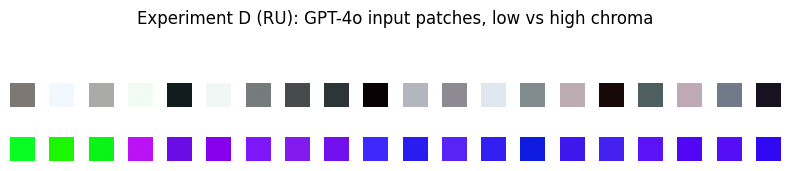

EN LLM columns: ['binL', 'binA', 'binB', 'r', 'g', 'b', 'name']
EN bins with GPT patches: 200


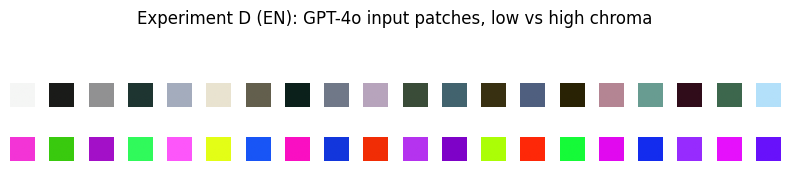

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths: same as in your D code
# ------------------------------------------------------------
ROOT = "/content/drive/MyDrive/2025_2026/color"

LLM_RU_FULL = f"{ROOT}/color_repo/russian-cielab-llm.csv"
LLM_EN_FULL = f"{ROOT}/color_repo/english-cielab-llm2.csv"

# ------------------------------------------------------------
# Helper: build per-bin table with chroma and GPT RGB
# ------------------------------------------------------------
def build_llm_bin_table(csv_path, lang_label):
    """
    Read LLM full-grid CSV for one language and return a DataFrame
    with one row per bin, containing:
      binL, binA, binB, r, g, b, C (approx LAB chroma)
    C is computed from bin indices: L=10*binL, A=10*binA, B=10*binB.
    """
    df = pd.read_csv(csv_path)
    print(f"{lang_label} LLM columns:", list(df.columns))

    # keep one RGB triple per bin (all samples use same r,g,b)
    bins = (
        df[["binL", "binA", "binB", "r", "g", "b"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    # approximate LAB center per bin
    bins["L"] = bins["binL"] * 10.0
    bins["A"] = bins["binA"] * 10.0
    bins["B"] = bins["binB"] * 10.0

    # LAB chroma for ordering
    bins["C"] = np.sqrt(bins["A"]**2 + bins["B"]**2)
    print(f"{lang_label} bins with GPT patches:", len(bins))
    return bins

# ------------------------------------------------------------
# Helper: show a row of patches
# ------------------------------------------------------------
def show_row(df_subset, axes_row, row_label):
    for j, (_, row) in enumerate(df_subset.iterrows()):
        rgb = np.array([[row["r"] / 255.0, row["g"] / 255.0, row["b"] / 255.0]])
        patch = np.tile(rgb, (24, 24, 1))
        axes_row[j].imshow(patch)
        axes_row[j].axis("off")
    axes_row[0].set_ylabel(row_label, rotation=0, ha="right", va="center")

# ------------------------------------------------------------
# 1. Russian: patches GPT saw in Experiment D
# ------------------------------------------------------------
ru_bins = build_llm_bin_table(LLM_RU_FULL, "RU")

N_ru = min(20, len(ru_bins))
ru_low  = ru_bins.sort_values("C").head(N_ru)
ru_high = ru_bins.sort_values("C").tail(N_ru)

fig, axes = plt.subplots(2, N_ru, figsize=(N_ru * 0.4, 2.0))
show_row(ru_low.reset_index(drop=True),  axes[0], "low C")
show_row(ru_high.reset_index(drop=True), axes[1], "high C")
plt.suptitle("Experiment D (RU): GPT-4o input patches, low vs high chroma")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. English: patches GPT saw in Experiment D
# ------------------------------------------------------------
en_bins = build_llm_bin_table(LLM_EN_FULL, "EN")

N_en = min(20, len(en_bins))
en_low  = en_bins.sort_values("C").head(N_en)
en_high = en_bins.sort_values("C").tail(N_en)

fig, axes = plt.subplots(2, N_en, figsize=(N_en * 0.4, 2.0))
show_row(en_low.reset_index(drop=True),  axes[0], "low C")
show_row(en_high.reset_index(drop=True), axes[1], "high C")
plt.suptitle("Experiment D (EN): GPT-4o input patches, low vs high chroma")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/2025_2026/color/metrics_all_languages.csv")

In [ ]:
ru = df[df["lang"] == "russian"]
en = df[df["lang"] == "english"]

ru_js = ru["js_surface"]
en_js = en["js_surface"]

ru_entropy = ru["entropy"]
en_entropy = en["entropy"]

KeyError: 'entropy'

NameError: name 'ru_entropy' is not defined

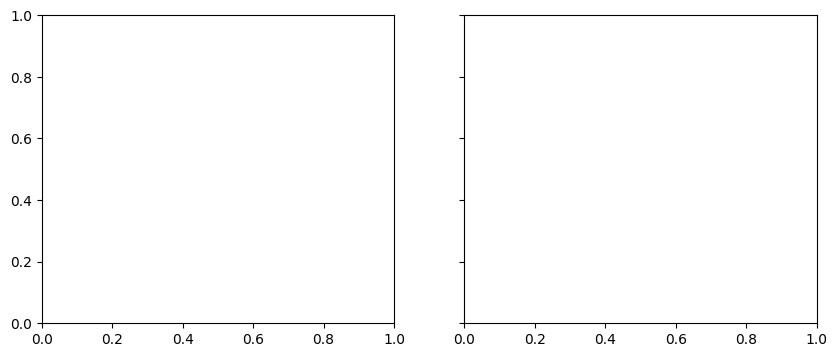

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10,4), sharex=True, sharey=True)

axes[0].scatter(ru_entropy, ru_js, s=35, alpha=0.7)
axes[0].set_title("Russian full color")
axes[0].set_xlabel("Human entropy H(p_human) [bits]")
axes[0].set_ylabel("JS(p_human, GPT-4o)")

axes[1].scatter(en_entropy, en_js, s=35, alpha=0.7)
axes[1].set_title("English full color")
axes[1].set_xlabel("Human entropy H(p_human) [bits]")

for ax in axes:
    ax.set_xlim(0,5.5)
    ax.set_ylim(0,1.0)

plt.tight_layout()
plt.show()